# Notebook 06 — Neural Network from Scratch (NumPy only)

## Project Context

This notebook is part of the **Rosa damascena Disease Detection** project. The goal is
to classify images of oil-bearing rose leaves into 7 categories: 6 disease/condition
classes (black spot, downy mildew, powdery mildew, rose mosaic, rose rust, insect damage)
plus the healthy_leaf class. This work extends the baselines established in notebook 05
(Logistic Regression and Linear SVM, both from scratch) by introducing a fully connected
deep neural network — still implemented from scratch using NumPy only, without any deep
learning framework.

## Goals of This Notebook

1. Implement a multi-layer fully connected neural network from scratch using NumPy
2. Derive and implement the backpropagation algorithm (chain rule, layer by layer)
3. Verify the analytical gradients with a numerical gradient check (finite differences)
4. Implement and compare two optimization algorithms:
   - Stochastic Gradient Descent with Momentum (SGD + momentum)
   - Adam (Adaptive Moment Estimation) with bias correction
5. Establish whether non-linear feature interactions improve classification accuracy
   compared to the linear models from notebook 05

## Architecture

A deep fully connected feedforward network with the following layer sizes:

```
Input (1024) → Hidden 1 (256) → Hidden 2 (128) → Hidden 3 (64) → Output (7)
```

- **Input size 1024:** images are loaded as 32x32 grayscale and flattened (32 * 32 = 1024).
  This matches the feature representation used in notebook 05, allowing a direct and fair
  comparison between linear models and the non-linear neural network on the same data.
- **Three hidden layers:** the depth provides enough capacity for the network to learn
  hierarchical non-linear feature combinations. A gradual reduction in width
  (256 → 128 → 64) acts as a learned dimensionality reduction toward the output.
- **Output size 7:** one logit per disease class, transformed into class probabilities
  through the softmax function.

## Activation Functions

- **Hidden layers: ReLU** — chosen because it is the modern standard for deep networks.
  ReLU does not suffer from vanishing gradients on the positive side and is
  computationally cheap (a simple max operation).
- **Output layer: Softmax** — converts logits into a valid probability distribution
  over the 7 classes, suitable for multi-class classification.

## Loss Function

Categorical **cross-entropy** is used as the loss function. Cross-entropy is the natural
loss for classification tasks where the model outputs a probability distribution, as it
directly measures the divergence between the predicted distribution and the true
one-hot encoded labels.

## Optimization Comparison

Two optimizers will be implemented from scratch and compared on the exact same network
architecture, initialization, and training data:

1. **SGD with Momentum** — extends standard SGD by accumulating an exponentially weighted
   moving average of past gradients. This dampens oscillations and accelerates convergence
   along consistent gradient directions.
2. **Adam** — combines momentum (first moment of the gradient) with an adaptive learning
   rate per parameter (second moment of the gradient), with bias correction to compensate
   for the zero-initialized moment estimates.

The comparison will be made on:
- Convergence speed (loss curves over epochs)
- Final test accuracy
- Per-class performance (especially for the minority class rose_mosaic)

## Expected Outcome

The traditional models from notebook 05 reached the following baselines on the same
1024-feature representation:

| Model               | Test Accuracy | Macro F1 |
|---------------------|---------------|----------|
| Logistic Regression | 55.6%         | 0.47     |
| Linear SVM          | 51.1%         | 0.44     |
| Random chance       | 14.3%         | —        |

Because a deep neural network can learn **non-linear** combinations of pixel features
(impossible for linear models), an improvement over the Logistic Regression baseline
is expected. However, since the input is still a flattened pixel vector, spatial
information is lost and the network cannot exploit the structure of an image. The
expected accuracy ceiling on this representation is well below what a Convolutional
Neural Network (notebook 07) could achieve. This notebook therefore serves as the
**intermediate baseline** between linear models (notebook 05) and CNNs (notebook 07).

## Math Highlighted in This Notebook

To make the mathematical foundations explicit and reproducible, the following derivations
are shown in dedicated markdown cells before their corresponding code:

- Forward pass: matrix form of the linear and non-linear transformations
- He weight initialization: derivation of the variance scaling for ReLU networks
- Backpropagation: chain rule expansion for every layer, including the combined
  softmax + cross-entropy gradient
- Gradient check: numerical verification of the analytical gradients
- SGD with momentum: update equations and physical interpretation
- Adam: first/second moment estimation and the bias correction formula


## Setup: Environment, Dependencies and Configuration

This section prepares the working environment for the notebook. The following actions
are performed:

1. **Mount Google Drive** — the processed image dataset is stored on Google Drive
   under `Machine_Learning_Project/data/processed/images/`. Mounting Drive at
   `/content/drive` makes those files accessible through standard filesystem operations.
2. **Import libraries** — only NumPy is used for the neural network itself (forward pass,
   backpropagation, optimizers). Matplotlib and Seaborn are used exclusively for
   visualization, and scikit-learn is used only to compute evaluation metrics on the
   final predictions (classification report, confusion matrix). No part of the model
   training relies on a deep learning framework or on scikit-learn's optimizers.
3. **Set the random seed** — fixing `np.random.seed` makes the experiment reproducible.
   Weight initialization, mini-batch shuffling, and any other source of randomness will
   produce the same results across runs, which is essential when comparing two
   optimizers fairly.
4. **Declare paths and constants** — all paths to the dataset directories and all
   project-wide constants (image size, number of classes, class names, baseline results
   from notebook 05) are defined here in one place. This keeps the rest of the notebook
   free from magic numbers and hard-coded paths.
5. **Verify dataset structure** — the dataset directories are explicitly checked at
   startup. Failing fast with a clear error message is preferable to discovering a
   missing folder midway through training.

The constant `BASELINE_RESULTS` stores the test accuracy and macro F1 score obtained
in notebook 05 (Logistic Regression: 55.6%, Linear SVM: 51.1%). These values are kept
in the configuration so that the comparison visualization in the final section can be
generated automatically without having to re-run notebook 05.


In [2]:
# ============================================================
# Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# Imports
# ============================================================
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# scikit-learn is used ONLY for final evaluation metrics — never for training.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Reproducibility
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ============================================================
# Paths (Google Drive)
# ============================================================
DRIVE_BASE = Path("/content/drive/MyDrive/Machine_Learning_Project")
DATA_DIR = DRIVE_BASE / "data" / "processed" / "images"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

# ============================================================
# Feature representation
# Same as notebook 05: 32x32 grayscale images flattened to 1024-dim vectors.
# This identical representation is what makes the comparison fair: linear models
# (notebook 05) and the neural network (this notebook) see exactly the same inputs.
# ============================================================
IMAGE_SIZE = 32
N_FEATURES = IMAGE_SIZE * IMAGE_SIZE   # 1024

# ============================================================
# Classes
# Alphabetical order is fixed so that class indices are consistent with notebook 05
# and any future notebook (07, 09). The mapping name -> index is also stored.
# ============================================================
CLASS_NAMES = [
    "black_spot",
    "downy_mildew",
    "healthy_leaf",
    "insect_damage",
    "powdery_mildew",
    "rose_mosaic",
    "rose_rust",
]
N_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# ============================================================
# Baselines from notebook 05 (kept here so the final comparison plot is self-contained)
# ============================================================
BASELINE_RESULTS = {
    "Logistic Regression": {"test_accuracy": 0.556, "macro_f1": 0.47},
    "Linear SVM":          {"test_accuracy": 0.511, "macro_f1": 0.44},
}

# ============================================================
# Plotting defaults
# ============================================================
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

# ============================================================
# Verify dataset structure (fail fast if Drive is not mounted or data is missing)
# ============================================================
for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    assert split_dir.exists(), f"Missing {split_name} directory: {split_dir}"
    for cls in CLASS_NAMES:
        class_dir = split_dir / cls
        assert class_dir.exists(), f"Missing class directory: {class_dir}"

print("Environment ready")
print(f"  Data root      : {DATA_DIR}")
print(f"  Image size     : {IMAGE_SIZE}x{IMAGE_SIZE} grayscale ({N_FEATURES} features)")
print(f"  Classes ({N_CLASSES})    : {CLASS_NAMES}")
print(f"  Random seed    : {RANDOM_SEED}")
print(f"  NumPy version  : {np.__version__}")

Mounted at /content/drive
Environment ready
  Data root      : /content/drive/MyDrive/Machine_Learning_Project/data/processed/images
  Image size     : 32x32 grayscale (1024 features)
  Classes (7)    : ['black_spot', 'downy_mildew', 'healthy_leaf', 'insect_damage', 'powdery_mildew', 'rose_mosaic', 'rose_rust']
  Random seed    : 42
  NumPy version  : 2.0.2


## Theoretical Foundation

Before implementing any code, the mathematical building blocks of the network are
defined and justified. The next cells (helper functions, forward pass, backpropagation,
optimizers) will reference the formulas and the reasoning introduced here.

### 1. Why a Deep Network?

A single-layer linear model (Logistic Regression, notebook 05) computes
$y = \text{softmax}(Wx + b)$. No matter how many additional **linear** layers are
stacked, the composition stays linear: two stacked linear layers $W_2(W_1 x + b_1) + b_2$
collapse into a single equivalent linear transformation $W' x + b'$. Depth without
non-linearity adds no representational power.

A **non-linear activation** between layers breaks this collapse and lets the network
approximate functions whose decision boundaries are not hyperplanes in the input space.
The Universal Approximation Theorem states that a sufficiently wide feedforward network
with a non-polynomial activation can approximate any continuous function on a compact
domain to arbitrary precision. In practice, **depth** (more layers, narrower each) often
generalizes better than **width** (one very wide layer) for the same parameter budget.
The chosen architecture (1024 → 256 → 128 → 64 → 7) follows this principle: three
hidden layers of decreasing width, each followed by a non-linear activation.

### 2. Activation Functions

Three classical activation functions are considered for the hidden layers:

| Activation | Formula                  | Output range | Derivative                          |
|------------|--------------------------|--------------|-------------------------------------|
| Sigmoid    | $\sigma(x) = 1/(1+e^{-x})$ | (0, 1)       | $\sigma(x)(1 - \sigma(x))$          |
| Tanh       | $\tanh(x)$               | (-1, 1)      | $1 - \tanh^2(x)$                    |
| ReLU       | $\max(0, x)$             | $[0, \infty)$ | $1$ if $x > 0$ else $0$            |

**Sigmoid** and **Tanh** are smooth and bounded but suffer from *vanishing gradients*:
for large $|x|$ their derivatives approach zero, so the gradient signal that travels
backward through many layers is multiplied by tiny numbers and effectively disappears.
This makes deep networks built on these activations very slow to train.

**ReLU** ($\max(0, x)$) does not saturate on the positive side: its derivative is
exactly $1$ wherever $x > 0$, so the backpropagated gradient passes through unchanged.
This is the main reason ReLU enabled the practical training of deep networks since
2012. The known drawback is the *dying ReLU* problem — if a neuron's pre-activation is
persistently negative, its gradient is $0$ and the neuron stops learning. With careful
weight initialization (see below) this is rarely an issue in practice.

For these reasons **ReLU is used in all hidden layers** of this network.

### 3. He Weight Initialization

Initializing weights matters because both the forward pass (signal propagation) and the
backward pass (gradient propagation) involve repeated multiplications by the weight
matrices. If the per-layer variance of activations explodes or shrinks, training
becomes unstable or freezes.

For a layer with $n_{\text{in}}$ input units, assume:
- Inputs $x_i$ have zero mean and variance $\sigma_x^2$.
- Weights $W_{ij}$ are initialized i.i.d. with zero mean and variance $\sigma_w^2$.
- Pre-activation $z = \sum_{i=1}^{n_{\text{in}}} W_i x_i$.

The variance of $z$ is $\text{Var}(z) = n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma_x^2$.

For Sigmoid/Tanh, the Glorot ("Xavier") rule sets $\sigma_w^2 = 1 / n_{\text{in}}$ so that
$\text{Var}(z) = \sigma_x^2$ and the signal magnitude is preserved.

For **ReLU**, half of the pre-activations are zeroed out on average (any $z < 0$ becomes
$0$). The effective variance of the post-activation is therefore halved. To compensate,
**He initialization** doubles the weight variance:

$$
W_{ij} \sim \mathcal{N}\!\left(0,\, \frac{2}{n_{\text{in}}}\right)
$$

This is the rule used in this notebook. Biases are initialized to zero.

### 4. Softmax (Output Layer)

The output layer produces $K = 7$ raw scores ("logits") $z_1, \dots, z_K$. They are
converted into a probability distribution over the classes by the softmax function:

$$
p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \qquad p_k \ge 0, \qquad \sum_k p_k = 1
$$

A **numerically stable** implementation subtracts the per-sample maximum before
exponentiation: $e^{z_k - \max(z)} / \sum_j e^{z_j - \max(z)}$. The result is
mathematically identical but avoids overflow when any $z_k$ is large.

### 5. Categorical Cross-Entropy Loss

Given the predicted probabilities $p$ and the one-hot encoded true label $y$, the
per-sample cross-entropy loss is:

$$
\mathcal{L} = -\sum_{k=1}^{K} y_k \log p_k = -\log p_{\text{true class}}
$$

The loss is minimized when the probability of the true class approaches $1$.

A crucial property of the **combined** softmax + cross-entropy block is that its
gradient with respect to the logits simplifies to:

$$
\frac{\partial \mathcal{L}}{\partial z_k} = p_k - y_k
$$

This compact form avoids the much messier gradient that would result from
differentiating softmax and cross-entropy separately, and it is the form that will be
implemented in the backpropagation code.

### 6. From Theory to Implementation

The next cells implement, in order:

1. Helper functions for the formulas above (ReLU, ReLU derivative, softmax,
   cross-entropy, one-hot encoding, He initialization).
2. A visualization of the three activation functions and their derivatives, to make the
   vanishing-gradient and ReLU behavior visible at a glance.
3. The forward pass of the full network using the formulas of Section 4–5.
4. A step-by-step derivation of backpropagation (chain rule for every layer) followed
   by a numerical gradient check, which confirms that the analytical gradients match
   finite-difference approximations.
5. Two optimization algorithms (SGD with momentum and Adam) implemented from scratch
   and compared on identical training data, weight initialization, and architecture.


## Loading the Dataset

This section loads the cleaned image dataset into NumPy arrays. The goal is to obtain
six arrays — `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test` — that the
neural network can consume directly. The procedure replicates exactly the feature
representation used in notebook 05; this identical preprocessing is what makes the
comparison between the linear models and the neural network a meaningful one. If the
two models saw differently scaled or differently structured inputs, any difference in
their accuracy could be attributed to data, not to the model.

### Procedure

For every split (train, validation, test) and for every one of the 7 classes:

1. **List all image files** in the class directory, sorted by filename. Deterministic
   ordering matters because, combined with the fixed `RANDOM_SEED`, it guarantees that
   every run of the notebook processes images in the same sequence — a prerequisite for
   reproducibility.
2. **Open the image** with PIL and convert it to grayscale (single channel). Grayscale
   is used for two reasons. First, it matches what notebook 05 did. Second, a fully
   connected network on color images would have three times as many input features
   (3,072 instead of 1,024) and would not gain much from the extra channels because it
   has no notion of spatial structure to begin with. Color is exploited later in the
   CNN (notebook 07).
3. **Resize** to 32x32 pixels using bilinear interpolation. The processed images on
   disk are 224x224. Downscaling to 32x32 reduces the input dimension from 50,176 to
   1,024 features per image, making training of a fully connected network feasible on
   CPU and matching the linear model baselines.
4. **Normalize** pixel values from the integer range [0, 255] to the floating-point
   range [0, 1] by dividing by 255. Normalized inputs keep activations in a well-behaved
   range across layers and make He initialization produce the variances it was derived
   for (see the theoretical foundation section).
5. **Flatten** the 32x32 array into a 1024-dimensional vector. The spatial structure
   is intentionally discarded: the network treats every pixel as an independent feature.
   This is a known limitation of fully connected networks on images and is the main
   reason why notebook 07 will switch to a CNN architecture that preserves spatial
   layout through convolution.

### Expected Output

Based on the dataset summary recorded after preprocessing in notebook 02:

- `X_train` shape ≈ (20,587, 1,024); `y_train` shape (20,587,)
- `X_val`   shape ≈ (2,571, 1,024);  `y_val`   shape (2,571,)
- `X_test`  shape ≈ (2,580, 1,024);  `y_test`  shape (2,580,)

Total memory footprint is approximately 100 MB (float32), which fits in Colab without
any streaming or batching at load time.

### Note on Loading Time

Reading 25,738 image files one by one from a mounted Google Drive is I/O bound and
can take several minutes — typically 2–5 minutes for the whole dataset. The actual
duration is printed for each split below.

In [3]:
def load_split(split_dir, image_size=IMAGE_SIZE):
    """
    Load all images from one split directory into NumPy arrays.

    Class subdirectories are read in the fixed CLASS_NAMES order so that integer
    labels match CLASS_TO_IDX consistently across splits and runs.

    Each image is:
      - converted to grayscale (single channel),
      - resized to image_size x image_size using bilinear interpolation,
      - normalized from [0, 255] to [0.0, 1.0] as float32,
      - flattened to a 1D vector of length image_size * image_size.

    Returns
    -------
    X : np.ndarray of shape (n_samples, image_size * image_size), dtype float32
    y : np.ndarray of shape (n_samples,), dtype int64
    """
    features = []
    labels = []
    for class_name in CLASS_NAMES:
        class_idx = CLASS_TO_IDX[class_name]
        class_dir = split_dir / class_name
        for img_path in sorted(class_dir.iterdir()):
            with Image.open(img_path) as img:
                img_gray = img.convert("L").resize(
                    (image_size, image_size), Image.BILINEAR
                )
                arr = np.asarray(img_gray, dtype=np.float32) / 255.0
            features.append(arr.flatten())
            labels.append(class_idx)
    X = np.asarray(features, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int64)
    return X, y


def report_split(name, X, y):
    """Print the shape, dtype, value range and per-class distribution of a split."""
    print(f"  [{name:5s}] X.shape={X.shape}  y.shape={y.shape}  "
          f"dtype={X.dtype}  min={X.min():.3f}  max={X.max():.3f}")
    unique, counts = np.unique(y, return_counts=True)
    distribution = ", ".join(
        f"{CLASS_NAMES[idx]}={cnt}" for idx, cnt in zip(unique, counts)
    )
    print(f"          per-class: {distribution}")


print("Loading dataset from Google Drive ...")
t_global = time.time()

t_start = time.time()
X_train, y_train = load_split(TRAIN_DIR)
print(f"  train split loaded in {time.time() - t_start:.1f}s")

t_start = time.time()
X_val, y_val = load_split(VAL_DIR)
print(f"  val   split loaded in {time.time() - t_start:.1f}s")

t_start = time.time()
X_test, y_test = load_split(TEST_DIR)
print(f"  test  split loaded in {time.time() - t_start:.1f}s")

print(f"\nAll splits loaded in {time.time() - t_global:.1f}s")

print("\nSummary:")
report_split("train", X_train, y_train)
report_split("val",   X_val,   y_val)
report_split("test",  X_test,  y_test)

memory_mb = (X_train.nbytes + X_val.nbytes + X_test.nbytes) / (1024 ** 2)
print(f"\nTotal feature memory: {memory_mb:.1f} MB")

Loading dataset from Google Drive ...
  train split loaded in 650.2s
  val   split loaded in 89.9s
  test  split loaded in 108.8s

All splits loaded in 848.9s

Summary:
  [train] X.shape=(20587, 1024)  y.shape=(20587,)  dtype=float32  min=0.000  max=1.000
          per-class: black_spot=3696, downy_mildew=2157, healthy_leaf=6538, insect_damage=3324, powdery_mildew=1499, rose_mosaic=773, rose_rust=2600
  [val  ] X.shape=(2571, 1024)  y.shape=(2571,)  dtype=float32  min=0.000  max=1.000
          per-class: black_spot=462, downy_mildew=269, healthy_leaf=817, insect_damage=415, powdery_mildew=187, rose_mosaic=96, rose_rust=325
  [test ] X.shape=(2580, 1024)  y.shape=(2580,)  dtype=float32  min=0.000  max=1.000
          per-class: black_spot=463, downy_mildew=271, healthy_leaf=818, insect_damage=417, powdery_mildew=188, rose_mosaic=98, rose_rust=325

Total feature memory: 100.5 MB


## Class Distribution Across Splits

The grouped bar chart below shows train / validation / test counts for each of the 7
classes. This reproduces the imbalance picture that was first established in the EDA
notebook (04). Keeping it visible inside notebook 06 makes the discussion of per-class
results in the evaluation section self-contained: any per-class accuracy can later be
read in the context of how many training examples that class actually had.

The imbalance ratio between the majority class (healthy_leaf) and the minority class
(rose_mosaic) is annotated directly on the figure. The training set is roughly 8.5
times larger for healthy_leaf than for rose_mosaic — a fact that the network's
per-class performance is likely to reflect, with the minority class being the hardest
to learn. Whether the imbalance should be actively corrected (class weights,
oversampling) is intentionally deferred: the network is first evaluated as-is, and the
need for an intervention is decided based on the observed confusion patterns rather
than chosen ahead of time.


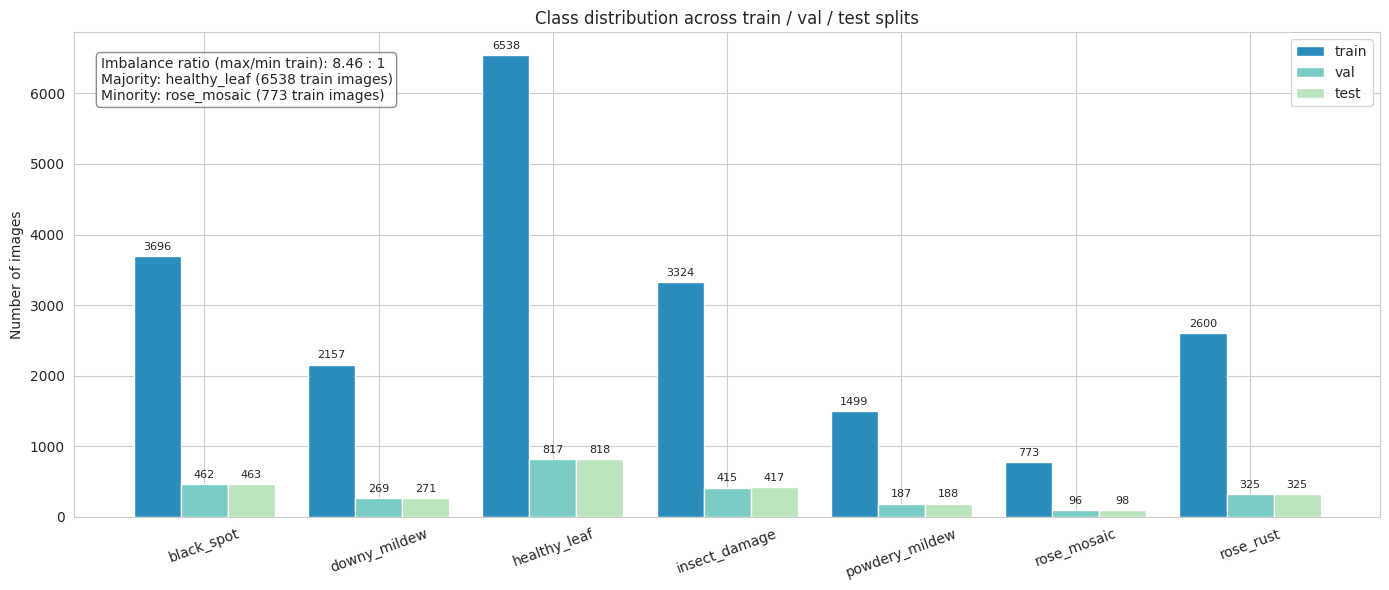

In [4]:
np.random.seed(RANDOM_SEED)  # reproducible sample image selection

# ============================================================
# Figure 1: Class distribution across train / val / test splits
# ============================================================
counts_train = np.array([(y_train == i).sum() for i in range(N_CLASSES)])
counts_val   = np.array([(y_val   == i).sum() for i in range(N_CLASSES)])
counts_test  = np.array([(y_test  == i).sum() for i in range(N_CLASSES)])

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(N_CLASSES)
w = 0.27

bars_train = ax.bar(x - w, counts_train, w, label="train", color="#2b8cbe")
bars_val   = ax.bar(x,     counts_val,   w, label="val",   color="#7bccc4")
bars_test  = ax.bar(x + w, counts_test,  w, label="test",  color="#bae4bc")

for bar_group in (bars_train, bars_val, bars_test):
    for b in bar_group:
        height = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            height + 60,
            f"{int(height)}",
            ha="center", va="bottom", fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20)
ax.set_ylabel("Number of images")
ax.set_title("Class distribution across train / val / test splits")
ax.legend(loc="upper right")

imbalance = counts_train.max() / counts_train.min()
majority_idx = int(counts_train.argmax())
minority_idx = int(counts_train.argmin())
ax.annotate(
    f"Imbalance ratio (max/min train): {imbalance:.2f} : 1\n"
    f"Majority: {CLASS_NAMES[majority_idx]} ({counts_train[majority_idx]} train images)\n"
    f"Minority: {CLASS_NAMES[minority_idx]} ({counts_train[minority_idx]} train images)",
    xy=(0.02, 0.95), xycoords="axes fraction",
    fontsize=10, va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9),
)

plt.tight_layout()
plt.show()

### Observations

The grouped bar chart confirms numerically what was already known from the EDA notebook:

- **The class imbalance is severe and concentrated in two classes.** The training set
  contains 6,538 healthy_leaf images and only 773 rose_mosaic images — a ratio of
  8.46:1. The next-smallest class (powdery_mildew, 1,499 images) is still nearly twice
  the size of rose_mosaic, so rose_mosaic stands out as the single most under-represented
  category. Any model trained without intervention will see roughly 8.5 healthy-leaf
  examples for every rose-mosaic example it encounters and will have a structural
  incentive to bias its predictions toward the majority class.

- **The 80/10/10 split is preserved across all classes.** For every class, the
  validation and test counts are almost exactly 1/8 of the training count (e.g.
  healthy_leaf: 6,538 / 817 / 818; rose_mosaic: 773 / 96 / 98). This means the
  imbalance is identical in every split — the model will be evaluated on the same
  distribution it was trained on, so the validation and test accuracies are directly
  comparable and the test set is not artificially "easier" or "harder" than the
  training set.

- **Per-class evaluation will be essential.** With such an uneven distribution,
  overall (micro) accuracy can be misleading: a network that always predicts
  healthy_leaf would already score 6,538 / 20,587 = 31.8% on training, more than
  twice the random-chance baseline of 14.3%. The honest metrics to track are
  **macro F1** (averages F1 over classes, treating all classes equally) and the
  full **per-class confusion matrix**, both of which are reported in the
  evaluation section at the end of the notebook.

### Implication for the Network

No active correction for class imbalance is applied at training time (no class
weights, no oversampling) in this notebook — this decision was made deliberately
so that the **uncorrected** behavior of the network can be measured first. Whether
an intervention is needed will be decided based on the per-class results, not chosen
in advance. The imbalance ratio recorded here will be referenced again when the
confusion matrix is interpreted.

## Visualizing the Network Input — Naive Rendering

A first attempt at visualizing the 32x32 grayscale image that the network will receive
is shown below. The image is plotted with matplotlib's default settings, which apply
**bilinear interpolation** when rendering small images at a larger display size. This
default is a sensible choice for natural photographs, but in this case it actively
hides what the network sees: the visualization looks smoothly blurred, suggesting a
continuous image, when in reality the data is a discrete 32x32 grid.

This visualization is kept here intentionally as a "before" view. The next cell repeats
the same images with `interpolation="nearest"` and adds a side-by-side comparison with
the original 224x224 source. The contrast between the two visualizations is what makes
the actual representational loss visible — and motivates the move to higher resolution
and convolutional features in notebook 07.

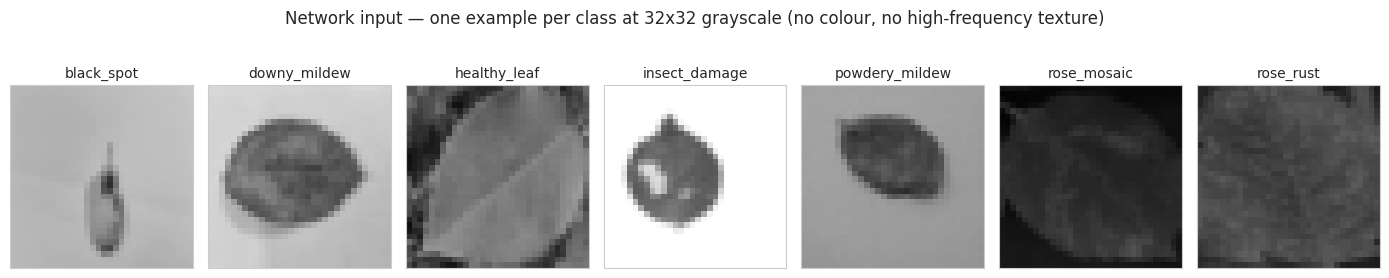

In [6]:
# ============================================================
# Figure 2: One random sample per class at 32x32 grayscale
# (the exact representation the network will see)
# ============================================================
fig, axes = plt.subplots(1, N_CLASSES, figsize=(14, 2.6))
for k, class_name in enumerate(CLASS_NAMES):
    class_indices = np.where(y_train == k)[0]
    sample_idx = np.random.choice(class_indices)
    img_2d = X_train[sample_idx].reshape(IMAGE_SIZE, IMAGE_SIZE)
    axes[k].imshow(img_2d, cmap="gray", vmin=0, vmax=1)
    axes[k].set_title(class_name, fontsize=10)
    axes[k].set_xticks([])
    axes[k].set_yticks([])

fig.suptitle(
    "Network input — one example per class at 32x32 grayscale "
    "(no colour, no high-frequency texture)",
    fontsize=12, y=1.08,
)
plt.tight_layout()
plt.show()

### Observations

Reading the two rows of the figure side by side makes the loss of information from
downscaling concrete:

- **High-frequency disease markers vanish at 32x32.** In the top row the small dark
  pustules of `rose_rust`, the angular cut-outs of `insect_damage`, and the powdery
  film of `powdery_mildew` are all individually visible to a human reader. In the
  bottom row those markers occupy at most one or two pixels and are smoothed into the
  general grey level of the leaf surface. The features the network has to learn from
  are therefore very coarse compared to what a human can use.

- **Leaf shape and overall brightness survive the downscaling.** The silhouettes of
  the leaves and the broad light/dark gradients across them are still clearly visible
  in the 32x32 row. This is the *useful* signal the fully connected network can
  exploit. Classes whose discriminating features live at this coarse scale
  (e.g. the strongly darkened `rose_rust` leaf vs the very bright `healthy_leaf`)
  should be relatively easy to distinguish.

- **Some classes look very similar at 32x32.** `rose_mosaic` and `powdery_mildew`
  are particularly hard to tell apart in the bottom row: both reduce to a medium-grey
  blotchy leaf without distinct local features. This visual confusion matches the EDA
  result that these two classes have nearly identical RGB profiles, and it predicts a
  specific failure mode for the network — confusion between these two minority classes.

- **`nearest`-neighbour rendering reveals the true resolution.** Each "pixel" in the
  bottom row is a discrete square cell; the visualization no longer hides the chunky
  nature of the input behind matplotlib's default bilinear smoothing. What is shown
  is exactly what enters the network as a 1,024-dimensional vector.

### Implication for the Network

The combination of (i) loss of high-frequency disease markers and (ii) visual
similarity between specific class pairs sets a hard ceiling on accuracy that no
choice of architecture, optimizer, or regularization can break through on this
representation. The neural network in this notebook is therefore measured against
the linear baselines of notebook 05 on the same representation — not against the
CNN of notebook 07, which will operate on the un-downscaled 224x224 colour images
where these markers and colour cues are still present.

## Information Loss from Preprocessing

The downscaled grayscale images that the fully connected network will receive look
considerably less informative than the 224x224 colour images they were preprocessed
from. To make this loss of information explicit, the visualization below shows two
versions of the same randomly selected training image, side by side, for each class:

- **Top row:** the original 224x224 grayscale image — high resolution, fine texture
  visible, individual disease markers (pustules, spots, mottled areas) can be
  identified by a human reader.
- **Bottom row:** the 32x32 grayscale image flattened into the 1,024-dimensional vector
  that the network will actually see. At this scale fine-grained markers collapse into
  a handful of pixels and most texture information is unrecoverable.

Both rows are rendered with `interpolation="nearest"` so that no additional smoothing
is added by matplotlib on top of the inherent low resolution of the 32x32 image; the
per-pixel structure of the network input is fully visible as a discrete grid of square
cells.

The contrast between the two rows is the central reality check of this notebook: the
network's accuracy ceiling on this representation is determined far more by the
representational loss visible here than by the choice of architecture or optimizer.
Notebook 07 (CNN) will operate on the 224x224 colour versions, preserving spatial
structure through convolution.

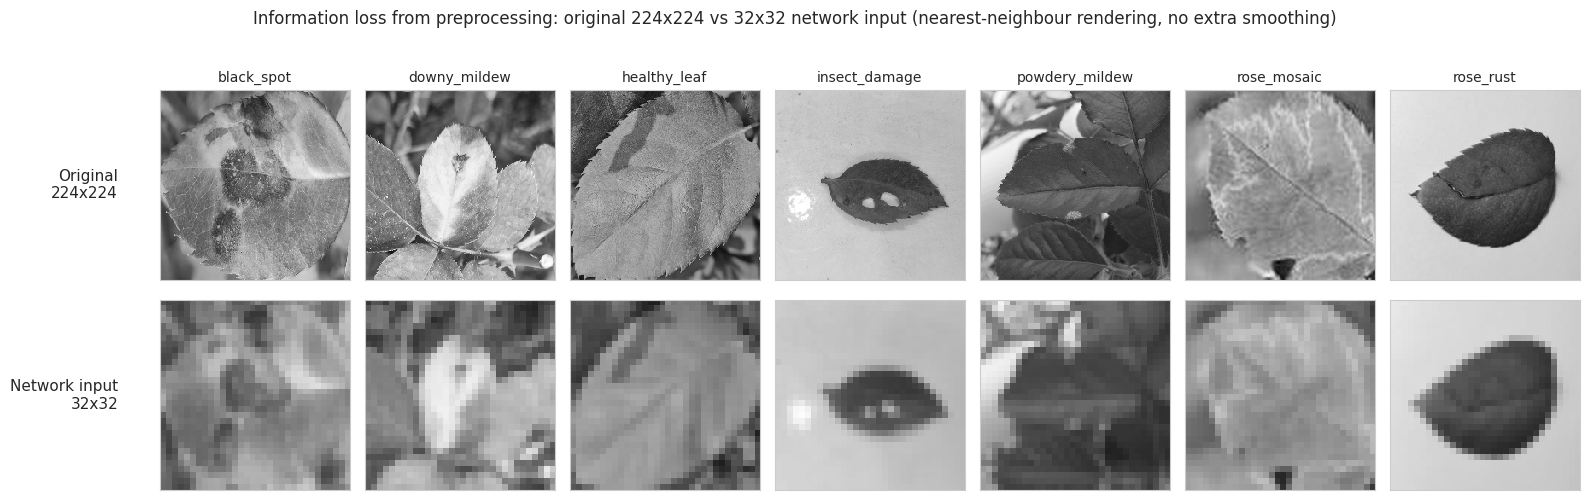

In [7]:
np.random.seed(RANDOM_SEED)  # reproducible sample selection

# ============================================================
# Side-by-side comparison: 224x224 grayscale original vs 32x32 network input
# Both rendered with nearest-neighbour interpolation so that no smoothing is
# added by matplotlib on top of the inherent low resolution of the 32x32 image.
# ============================================================
fig, axes = plt.subplots(2, N_CLASSES, figsize=(16, 5))

for k, class_name in enumerate(CLASS_NAMES):
    class_dir = TRAIN_DIR / class_name
    file_paths = sorted(class_dir.iterdir())
    local_idx = np.random.randint(0, len(file_paths))
    img_path = file_paths[local_idx]

    # Open once, derive both versions from the same source image
    with Image.open(img_path) as img:
        img_gray = img.convert("L")
        img_224 = np.asarray(img_gray, dtype=np.float32) / 255.0
        img_32_pil = img_gray.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
        img_32 = np.asarray(img_32_pil, dtype=np.float32) / 255.0

    # Top row: original 224x224 grayscale
    axes[0, k].imshow(img_224, cmap="gray", vmin=0, vmax=1,
                       interpolation="nearest")
    axes[0, k].set_title(class_name, fontsize=10)
    axes[0, k].set_xticks([])
    axes[0, k].set_yticks([])

    # Bottom row: 32x32 grayscale (network input)
    axes[1, k].imshow(img_32, cmap="gray", vmin=0, vmax=1,
                       interpolation="nearest")
    axes[1, k].set_xticks([])
    axes[1, k].set_yticks([])

# Row labels on the leftmost column
axes[0, 0].set_ylabel("Original\n224x224", fontsize=11, rotation=0,
                       ha="right", va="center", labelpad=30)
axes[1, 0].set_ylabel("Network input\n32x32", fontsize=11, rotation=0,
                       ha="right", va="center", labelpad=30)

fig.suptitle(
    "Information loss from preprocessing: original 224x224 vs 32x32 network input "
    "(nearest-neighbour rendering, no extra smoothing)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## Helper Functions

This cell implements the building blocks that the forward pass, the backward pass and
the optimizers will rely on. Every function is a direct translation of the formulas
introduced in the Theoretical Foundation section into vectorised NumPy code, so that
each operation is applied to a whole mini-batch at once with no Python-level loop.

### Functions Implemented

- **`relu(z)`** — element-wise ReLU activation, used in all three hidden layers.
- **`relu_derivative(z)`** — element-wise derivative of ReLU. Returns `1.0` where
  `z > 0` and `0.0` elsewhere. Backpropagation through a ReLU layer multiplies the
  upstream gradient by this mask, so neurons with negative pre-activations contribute
  no gradient — this is the mechanism behind the *dying ReLU* phenomenon.
- **`sigmoid(z)`, `sigmoid_derivative(z)`, `tanh_derivative(z)`** — included only for
  the activation-comparison plot in the next cell. They are not used by the network
  itself, but having them available makes the visualization self-contained.
- **`softmax(z)`** — numerically stable softmax over the last axis. The per-row
  maximum is subtracted before exponentiation; this is the standard "shifted logits"
  trick that avoids overflow when any logit is large in magnitude.
- **`one_hot(y)`** — converts integer class labels into one-hot encoded rows. Used
  inside the loss function and at evaluation time.
- **`cross_entropy_loss(probs, y_true_onehot)`** — average categorical cross-entropy
  loss over a mini-batch. A tiny epsilon (`1e-12`) is added inside the logarithm to
  guard against `log(0)` in the rare case that a predicted probability lands at
  exactly zero.
- **`he_init(n_in, n_out, rng)`** — He weight initialization, drawing weights from
  `N(0, 2/n_in)` as derived in section 3 of the theoretical foundation. Biases are
  initialized to zero. The `rng` argument (a `numpy.random.Generator`) makes
  initialization reproducible across runs.

### Sanity Checks

After the function definitions, a battery of explicit assertions verifies that each
helper behaves as expected. These checks are not redundant: they catch typos and
subtle indexing mistakes here, where the symptoms are obvious, instead of deep inside
the training loop where they manifest as mysterious instability. The most informative
checks are printed at the end of the cell:

- `cross_entropy_loss(perfect_predictions)` ≈ 0 — the loss is minimized when the
  predicted distribution matches the labels exactly.
- `cross_entropy_loss(uniform_predictions)` ≈ `log(N_CLASSES) = log(7) ≈ 1.9459` —
  this is the loss of an untrained, "I don't know" classifier. Any working training
  loop must beat this value on the training set within the first few epochs;
  if it does not, something is broken in either the forward pass, the backward pass
  or the optimizer.
- The empirical standard deviation of `he_init` weights matches the theoretical
  value `sqrt(2/n_in)` to within 5%.

In [8]:
# ============================================================
# Activation functions and their derivatives
# ============================================================

def relu(z):
    """ReLU activation: max(0, z). Element-wise, vectorised over any shape."""
    return np.maximum(0.0, z)


def relu_derivative(z):
    """Derivative of ReLU w.r.t. its pre-activation z.

    Returns 1 wherever z > 0 and 0 elsewhere. The boundary case z == 0 is
    conventionally assigned 0; in floating-point arithmetic an exact zero is
    extremely unlikely, so this convention has no practical effect.
    """
    return (z > 0).astype(np.float32)


def sigmoid(z):
    """Sigmoid activation, used only for the activation-comparison plot."""
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative(z):
    """Derivative of sigmoid: sigma(z) * (1 - sigma(z))."""
    s = sigmoid(z)
    return s * (1.0 - s)


def tanh_derivative(z):
    """Derivative of tanh: 1 - tanh(z)^2."""
    return 1.0 - np.tanh(z) ** 2


# ============================================================
# Output-layer functions: softmax + cross-entropy
# ============================================================

def softmax(z):
    """Numerically stable softmax applied row-wise.

    Subtracting the per-row maximum before exponentiation prevents overflow
    when any logit is large in magnitude, while leaving the resulting
    probabilities mathematically unchanged.

    Parameters
    ----------
    z : np.ndarray of shape (batch_size, n_classes)

    Returns
    -------
    np.ndarray of the same shape, with each row a valid probability distribution.
    """
    z_shifted = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def one_hot(y, n_classes=N_CLASSES):
    """Convert integer class labels to a one-hot encoded matrix.

    Parameters
    ----------
    y : np.ndarray of shape (batch_size,), dtype int
    n_classes : int

    Returns
    -------
    np.ndarray of shape (batch_size, n_classes), dtype float32,
    with a single 1.0 per row and zeros elsewhere.
    """
    encoded = np.zeros((y.shape[0], n_classes), dtype=np.float32)
    encoded[np.arange(y.shape[0]), y] = 1.0
    return encoded


def cross_entropy_loss(probs, y_true_onehot, epsilon=1e-12):
    """Average categorical cross-entropy loss over a mini-batch.

    L = - mean_over_batch( sum_k  y_true[k] * log(probs[k]) )

    Parameters
    ----------
    probs : np.ndarray of shape (batch_size, n_classes), softmax probabilities
    y_true_onehot : np.ndarray of shape (batch_size, n_classes), one-hot labels
    epsilon : float — small additive constant inside the logarithm to avoid log(0)

    Returns
    -------
    float — scalar loss averaged over the batch.
    """
    log_probs = np.log(probs + epsilon)
    per_sample_loss = -np.sum(y_true_onehot * log_probs, axis=1)
    return float(np.mean(per_sample_loss))


# ============================================================
# He weight initialization for ReLU layers
# ============================================================

def he_init(n_in, n_out, rng):
    """He weight initialization for a layer with n_in inputs and n_out outputs.

    Weights are drawn from N(0, 2/n_in), the variance derived in the theoretical
    foundation section to preserve the magnitude of activations through ReLU.

    Parameters
    ----------
    n_in : int — number of input units to the layer
    n_out : int — number of output units of the layer
    rng : np.random.Generator — random number generator for reproducibility

    Returns
    -------
    W : np.ndarray of shape (n_in, n_out), float32, He-initialized weights
    b : np.ndarray of shape (n_out,), float32, biases initialized to zero
    """
    std = np.sqrt(2.0 / n_in)
    W = rng.normal(loc=0.0, scale=std, size=(n_in, n_out)).astype(np.float32)
    b = np.zeros(n_out, dtype=np.float32)
    return W, b


# ============================================================
# Sanity checks — verify every helper before moving on
# ============================================================
rng_check = np.random.default_rng(RANDOM_SEED)

# --- ReLU and its derivative ---
test_z = np.array([[-2.0, -0.5, 0.0, 0.5, 2.0]])
assert np.allclose(relu(test_z), [[0.0, 0.0, 0.0, 0.5, 2.0]])
assert np.allclose(relu_derivative(test_z), [[0.0, 0.0, 0.0, 1.0, 1.0]])

# --- Softmax: rows sum to 1 ---
test_logits = rng_check.normal(size=(4, N_CLASSES)).astype(np.float32)
probs = softmax(test_logits)
assert np.allclose(probs.sum(axis=1), 1.0), "softmax rows must sum to 1"
assert (probs >= 0).all() and (probs <= 1).all()

# --- Softmax: numerical stability for very large logits ---
big_logits = np.array([[1000.0, 999.0, 998.0]])
probs_big = softmax(big_logits)
assert np.isfinite(probs_big).all(), "softmax must stay finite for large logits"
assert np.allclose(probs_big.sum(), 1.0)

# --- One-hot encoding round-trip ---
test_y = np.array([0, 3, 6, 2])
oh = one_hot(test_y)
assert oh.shape == (4, N_CLASSES)
assert (oh.sum(axis=1) == 1.0).all()
assert oh.argmax(axis=1).tolist() == test_y.tolist()

# --- Cross-entropy: perfect prediction -> ~0, uniform prediction -> log(N_CLASSES) ---
perfect_probs = oh.copy()
loss_perfect = cross_entropy_loss(perfect_probs, oh)
assert loss_perfect < 1e-5, f"perfect predictions should give zero loss, got {loss_perfect}"

uniform_probs = np.full((4, N_CLASSES), 1.0 / N_CLASSES, dtype=np.float32)
loss_uniform = cross_entropy_loss(uniform_probs, oh)
expected_uniform = float(np.log(N_CLASSES))
assert abs(loss_uniform - expected_uniform) < 1e-3, (
    f"uniform predictions should give log({N_CLASSES}) = {expected_uniform:.4f}, "
    f"got {loss_uniform:.4f}"
)

# --- He initialization: empirical std should match sqrt(2/n_in) ---
n_in_test = 1024
W_test, b_test = he_init(n_in_test, 256, rng_check)
expected_std = float(np.sqrt(2.0 / n_in_test))
observed_std = float(W_test.std())
relative_error = abs(observed_std - expected_std) / expected_std
assert relative_error < 0.05, (
    f"He init std deviates: expected {expected_std:.4f}, got {observed_std:.4f} "
    f"(relative error {relative_error:.1%})"
)
assert (b_test == 0).all(), "He init biases must start at zero"

print("All helper sanity checks passed:")
print(f"  relu([-2, -0.5, 0, 0.5, 2])           -> [0, 0, 0, 0.5, 2]")
print(f"  softmax rows sum to 1 (stable up to logit magnitude 1e3)")
print(f"  cross-entropy on perfect prediction   -> {loss_perfect:.3e}")
print(f"  cross-entropy on uniform prediction   -> {loss_uniform:.4f}  "
      f"(expected log(7) = {expected_uniform:.4f})")
print(f"  He init std (n_in={n_in_test})              -> "
      f"expected {expected_std:.4f}, observed {observed_std:.4f}")

All helper sanity checks passed:
  relu([-2, -0.5, 0, 0.5, 2])           -> [0, 0, 0, 0.5, 2]
  softmax rows sum to 1 (stable up to logit magnitude 1e3)
  cross-entropy on perfect prediction   -> 0.000e+00
  cross-entropy on uniform prediction   -> 1.9459  (expected log(7) = 1.9459)
  He init std (n_in=1024)              -> expected 0.0442, observed 0.0442


## Activation Functions and Their Derivatives

Two complementary views of the three activation functions discussed in section 2 of
the Theoretical Foundation are shown side by side in a single figure:

- **Left panel** — the activations themselves, plotted on `x` in `[-5, 5]`. The shapes
  reveal their output ranges immediately: Sigmoid is squashed into `(0, 1)`, Tanh into
  `(-1, 1)`, and ReLU is unbounded on the positive side while clipping the negative
  side to zero.
- **Right panel** — the derivatives that backpropagation will use to propagate
  gradients through these activations. Orange shading marks the regions where the
  sigmoid and tanh derivatives effectively vanish.

### Why the Derivatives Plot Is the Important One

Backpropagation through an activation layer multiplies the upstream gradient by
`f'(x)` element-wise. The behavior of `f'` therefore directly controls how much
gradient signal can reach the layers below:

- **Sigmoid′(x)** has a maximum value of `0.25` (at `x = 0`) and decays exponentially
  toward zero for `|x| > ~5`. Stacking even a few sigmoid layers means the
  backpropagated gradient is shrunk by at least a factor of `0.25^N` per pass through
  the activation chain. This is the classical *vanishing-gradient* problem that made
  deep sigmoid networks historically very difficult to train.
- **Tanh′(x)** has a higher maximum derivative (1.0 at `x = 0`) and is centered around
  zero, which makes it noticeably better than Sigmoid for hidden layers — but it still
  saturates to zero for `|x| > ~5`.
- **ReLU′(x)** is exactly `1` for all `x > 0` and exactly `0` for `x < 0`. There is
  **no saturation on the positive side**: the gradient passes through unchanged for
  any positive pre-activation, regardless of magnitude. This single property is the
  reason ReLU enabled the practical training of deep networks. The flat zero on the
  negative side is the source of the *dying ReLU* phenomenon: a neuron whose
  pre-activation is persistently negative receives no gradient and stops learning.
  He initialization (Theoretical Foundation, section 3) is the standard countermeasure
  that keeps pre-activations distributed around zero at the start of training so that
  most of them fall in the active half of the ReLU.

This visualization makes the theoretical justification for using ReLU in the hidden
layers concrete and visual: it is not chosen by tradition but because of the specific
shape of its derivative on the right of zero.

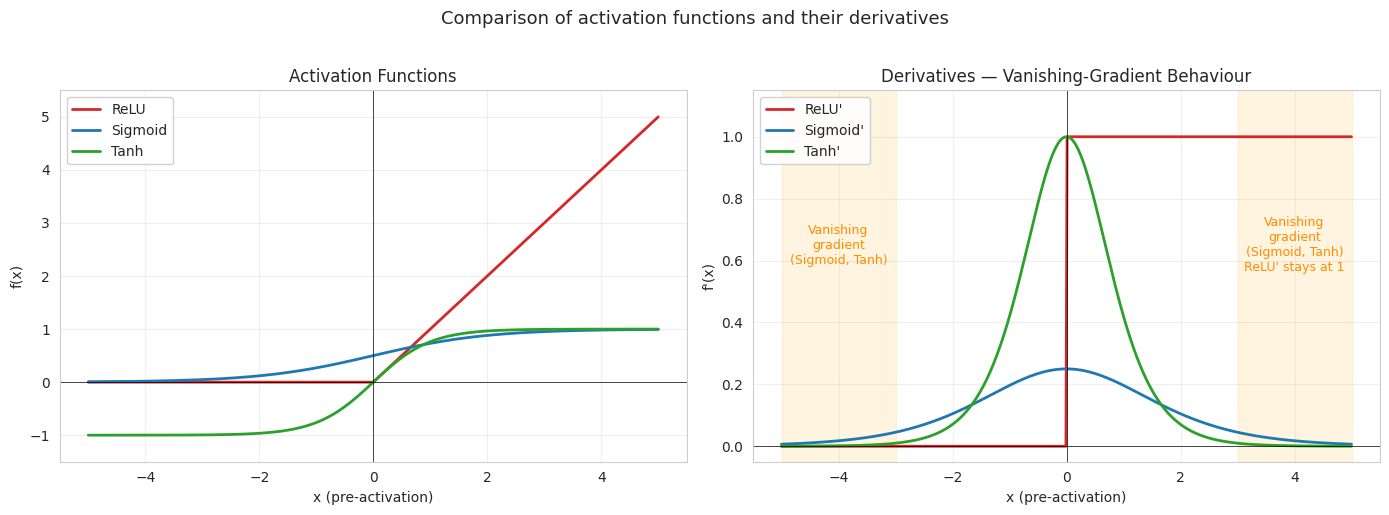

Key observations:
  Sigmoid   range (0, 1)        max derivative  0.25  vanishes for |x| > ~5
  Tanh      range (-1, 1)       max derivative  1.00  vanishes for |x| > ~5
  ReLU      range [0, +inf)     derivative      1.0 for x > 0,  0 for x < 0


In [9]:
# ============================================================
# Activation functions and their derivatives — side-by-side comparison
# ============================================================
x_range = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- Left subplot: the activation functions themselves -----
ax = axes[0]
ax.plot(x_range, relu(x_range),    label="ReLU",    color="#d62728", linewidth=2)
ax.plot(x_range, sigmoid(x_range), label="Sigmoid", color="#1f77b4", linewidth=2)
ax.plot(x_range, np.tanh(x_range), label="Tanh",    color="#2ca02c", linewidth=2)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("x (pre-activation)")
ax.set_ylabel("f(x)")
ax.set_title("Activation Functions")
ax.legend(loc="upper left", framealpha=0.9)
ax.set_ylim(-1.5, 5.5)
ax.grid(True, alpha=0.3)

# ----- Right subplot: their derivatives + vanishing-gradient annotation -----
ax = axes[1]
ax.plot(x_range, relu_derivative(x_range),    label="ReLU'",    color="#d62728", linewidth=2)
ax.plot(x_range, sigmoid_derivative(x_range), label="Sigmoid'", color="#1f77b4", linewidth=2)
ax.plot(x_range, tanh_derivative(x_range),    label="Tanh'",    color="#2ca02c", linewidth=2)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)

# Highlight where Sigmoid' and Tanh' effectively vanish
ax.axvspan(-5, -3, alpha=0.12, color="orange")
ax.axvspan( 3,  5, alpha=0.12, color="orange")
ax.text(-4.0, 0.65, "Vanishing\ngradient\n(Sigmoid, Tanh)",
        ha="center", va="center", color="darkorange", fontsize=9)
ax.text( 4.0, 0.65, "Vanishing\ngradient\n(Sigmoid, Tanh)\nReLU' stays at 1",
        ha="center", va="center", color="darkorange", fontsize=9)

ax.set_xlabel("x (pre-activation)")
ax.set_ylabel("f'(x)")
ax.set_title("Derivatives — Vanishing-Gradient Behaviour")
ax.legend(loc="upper left", framealpha=0.9)
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)

fig.suptitle(
    "Comparison of activation functions and their derivatives",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  Sigmoid   range (0, 1)        max derivative  0.25  vanishes for |x| > ~5")
print(f"  Tanh      range (-1, 1)       max derivative  1.00  vanishes for |x| > ~5")
print(f"  ReLU      range [0, +inf)     derivative      1.0 for x > 0,  0 for x < 0")

### Observations

The plotted curves confirm the theoretical claims made in section 2 of the Theoretical
Foundation directly and visually:

- **Output ranges match the expected intervals.** Sigmoid is bounded in `(0, 1)`,
  Tanh in `(-1, 1)`, and ReLU grows linearly without bound for positive inputs while
  remaining exactly zero for negative inputs.

- **Sigmoid's derivative is tiny everywhere.** Its peak value is `0.25` at `x = 0`,
  and it falls below `0.05` already by `|x| = 3`. A pre-activation passing through
  even a single sigmoid layer has its gradient shrunk by at least a factor of four;
  passing through three stacked sigmoid layers shrinks it by at least `4 x 4 x 4 = 64`.
  This is the multiplicative attenuation that makes deep sigmoid networks unstable to
  train, and it is visible at a glance from the height of the blue curve in the right
  panel.

- **Tanh's derivative is a clear improvement over Sigmoid but still saturates.** Its
  peak value reaches `1.0`, so an activation that stays near zero will let the gradient
  pass through almost unchanged. However, once `|x| > 3` the derivative falls below
  `0.01`, so neurons that are confidently driven away from zero stop contributing to
  learning — the same vanishing problem, just postponed.

- **ReLU's derivative is the only one that does not vanish on the positive side.**
  Its value is exactly `1` for every `x > 0`, regardless of magnitude. The orange
  highlight on the right of the derivatives panel emphasises this: where Sigmoid' and
  Tanh' have collapsed to zero, ReLU' is still at full strength. This is the property
  that makes deep ReLU networks trainable end-to-end.

- **The flat zero region on the left of ReLU' is a real risk, not a free lunch.**
  Any neuron whose pre-activation is persistently negative receives zero gradient and
  stops updating. The standard mitigation, He initialization (already implemented in
  `he_init` above), keeps pre-activations roughly centered around zero at the start
  of training so that approximately half of them fall in the active half of ReLU.

### Implication for the Network

These observations together justify the design decision recorded in the Theoretical
Foundation: ReLU is used in all hidden layers, paired with He initialization. The
visualization above is the empirical evidence behind that choice — the network will
be trained on top of activation behaviour the reader can see, not just take on
authority.

## The Forward Pass

The forward pass propagates an input mini-batch through the network layer by layer,
producing a probability distribution over the 7 classes at the output. The
implementation translates the equations of sections 4–5 of the Theoretical Foundation
into vectorised NumPy code, using the helper functions verified in the previous cells.

### Architecture as a Pipeline of Operations

For an input mini-batch `X` of shape `(batch_size, 1024)`, the forward pass performs
the following sequence of operations:

```
A_0 = X                                  shape (batch_size, 1024)

Z_1 = A_0 @ W_1 + b_1                    shape (batch_size,  256)
A_1 = ReLU(Z_1)                          shape (batch_size,  256)

Z_2 = A_1 @ W_2 + b_2                    shape (batch_size,  128)
A_2 = ReLU(Z_2)                          shape (batch_size,  128)

Z_3 = A_2 @ W_3 + b_3                    shape (batch_size,   64)
A_3 = ReLU(Z_3)                          shape (batch_size,   64)

Z_4 = A_3 @ W_4 + b_4                    shape (batch_size,    7)
probs = softmax(Z_4)                     shape (batch_size,    7)
```

Each hidden layer is a **linear transformation followed by a ReLU activation**. The
output layer is a linear transformation followed by **softmax**, which turns logits
into a valid probability distribution. The same pattern (linear + non-linearity)
repeats for every hidden layer, which is why the implementation can use a simple loop
rather than four hard-coded copies of the same code.

### Why Store Intermediate Values?

Backpropagation in the next cells will need both `Z_i` (pre-activations) and `A_i`
(post-activations) for every layer in order to apply the chain rule. The forward pass
therefore caches all intermediate values in a dictionary keyed by `"Z{i}"` and `"A{i}"`.
This is a deliberate memory–compute trade-off: keeping the activations costs roughly
the size of one mini-batch worth of hidden states, but saves recomputing them during
the backward pass. For a batch of 128 samples the total cache is a few megabytes,
entirely acceptable.

### Parameter Storage

In [10]:
# ============================================================
# Network architecture
# ============================================================
LAYER_SIZES = [N_FEATURES, 256, 128, 64, N_CLASSES]
N_LAYERS = len(LAYER_SIZES) - 1  # 4 weight layers: 3 hidden + 1 output


def init_network(layer_sizes, rng):
    """Initialize weights and biases for a fully connected network.

    For each layer i (1-indexed), He initialization is used for W_i and biases
    b_i are initialized to zero. The result is a dictionary holding every
    parameter the training loop will update.

    Parameters
    ----------
    layer_sizes : list[int]
        Layer widths from input to output, e.g. [1024, 256, 128, 64, 7].
    rng : np.random.Generator
        Random generator for reproducibility.

    Returns
    -------
    params : dict
        Keys 'W1', 'b1', 'W2', 'b2', ... Each W_i has shape
        (layer_sizes[i-1], layer_sizes[i]); each b_i has shape (layer_sizes[i],).
    """
    params = {}
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        W, b = he_init(n_in, n_out, rng)
        params[f"W{i + 1}"] = W
        params[f"b{i + 1}"] = b
    return params


def forward(X, params, n_layers=N_LAYERS):
    """Forward pass through the fully connected network.

    Hidden layers 1 ... (n_layers - 1):  Z = A_prev @ W + b,   A = ReLU(Z)
    Output layer  n_layers:              Z = A_prev @ W + b,   probs = softmax(Z)

    All intermediate Z and A are stored in `cache` so that backpropagation
    can use them without recomputation.

    Parameters
    ----------
    X : np.ndarray of shape (batch_size, n_features)
    params : dict — as returned by init_network
    n_layers : int — total number of weight layers (hidden + output)

    Returns
    -------
    probs : np.ndarray of shape (batch_size, n_classes), softmax probabilities
    cache : dict — keys 'A0' (input), 'Z1', 'A1', ..., 'Z{n_layers}', 'A{n_layers}'
    """
    cache = {"A0": X}
    A = X
    # Hidden layers: linear + ReLU
    for i in range(1, n_layers):
        W = params[f"W{i}"]
        b = params[f"b{i}"]
        Z = A @ W + b
        A = relu(Z)
        cache[f"Z{i}"] = Z
        cache[f"A{i}"] = A
    # Output layer: linear + softmax
    W = params[f"W{n_layers}"]
    b = params[f"b{n_layers}"]
    Z = A @ W + b
    probs = softmax(Z)
    cache[f"Z{n_layers}"] = Z
    cache[f"A{n_layers}"] = probs
    return probs, cache


# ============================================================
# Sanity checks
# ============================================================
rng_fwd = np.random.default_rng(RANDOM_SEED)
test_params = init_network(LAYER_SIZES, rng_fwd)

# --- Parameter shapes and total count ---
print("Network parameters:")
total_params = 0
for i in range(1, N_LAYERS + 1):
    W = test_params[f"W{i}"]
    b = test_params[f"b{i}"]
    layer_count = W.size + b.size
    total_params += layer_count
    print(f"  Layer {i}: W{i}.shape={str(W.shape):<14} "
          f"b{i}.shape={str(b.shape):<8} "
          f"({layer_count:>8,} parameters)")
print(f"  Total trainable parameters: {total_params:,}")

# --- Forward pass on a real mini-batch from the training set ---
batch_size = 128
batch_indices = np.random.default_rng(RANDOM_SEED).choice(
    X_train.shape[0], size=batch_size, replace=False
)
X_batch = X_train[batch_indices]
y_batch = y_train[batch_indices]

probs, cache = forward(X_batch, test_params)

# Check 1: output shape
assert probs.shape == (batch_size, N_CLASSES), (
    f"output shape mismatch: expected {(batch_size, N_CLASSES)}, got {probs.shape}"
)

# Check 2: valid probability distribution per row
assert np.allclose(probs.sum(axis=1), 1.0, atol=1e-5), (
    "probabilities must sum to 1 per row"
)
assert (probs >= 0).all() and (probs <= 1).all(), (
    "probabilities must lie in [0, 1]"
)

# Check 3: initial loss close to log(N_CLASSES)
y_batch_onehot = one_hot(y_batch)
initial_loss = cross_entropy_loss(probs, y_batch_onehot)
expected_loss = float(np.log(N_CLASSES))

# --- Intermediate cache shapes ---
print(f"\nCache shapes for batch_size={batch_size}:")
for key in sorted(cache.keys()):
    print(f"  cache['{key}'].shape = {cache[key].shape}")

print(f"\nForward pass sanity:")
print(f"  Output shape           : {probs.shape}  (expected ({batch_size}, {N_CLASSES}))")
print(f"  Row sums               : min={probs.sum(axis=1).min():.6f}  "
      f"max={probs.sum(axis=1).max():.6f}  (expected 1.0)")
print(f"  Output range           : [{probs.min():.6f}, {probs.max():.6f}]  "
      f"(must be in [0, 1])")
print(f"  Initial loss           : {initial_loss:.4f}")
print(f"  Expected log({N_CLASSES})         : {expected_loss:.4f}")
print(f"  Relative difference    : {abs(initial_loss - expected_loss) / expected_loss:.1%}")

Network parameters:
  Layer 1: W1.shape=(1024, 256)    b1.shape=(256,)   ( 262,400 parameters)
  Layer 2: W2.shape=(256, 128)     b2.shape=(128,)   (  32,896 parameters)
  Layer 3: W3.shape=(128, 64)      b3.shape=(64,)    (   8,256 parameters)
  Layer 4: W4.shape=(64, 7)        b4.shape=(7,)     (     455 parameters)
  Total trainable parameters: 304,007

Cache shapes for batch_size=128:
  cache['A0'].shape = (128, 1024)
  cache['A1'].shape = (128, 256)
  cache['A2'].shape = (128, 128)
  cache['A3'].shape = (128, 64)
  cache['A4'].shape = (128, 7)
  cache['Z1'].shape = (128, 256)
  cache['Z2'].shape = (128, 128)
  cache['Z3'].shape = (128, 64)
  cache['Z4'].shape = (128, 7)

Forward pass sanity:
  Output shape           : (128, 7)  (expected (128, 7))
  Row sums               : min=1.000000  max=1.000000  (expected 1.0)
  Output range           : [0.009403, 0.615080]  (must be in [0, 1])
  Initial loss           : 2.2396
  Expected log(7)         : 1.9459
  Relative difference    : 15

### Observations

The forward pass output confirms that the architecture is wired correctly and that
initialization is well-behaved.

- **Parameter budget is dominated by the first layer.** Of the 304,007 trainable
  parameters, 262,400 (86%) live in W_1 alone — the matrix that connects 1,024 input
  pixels to 256 hidden units. The remaining three layers together hold only 14% of
  the parameters. This is the standard shape for a fully connected network on raw
  pixels: the input layer is wide and expensive, and most of the model's capacity is
  spent learning a first-level non-linear projection of the pixel space. A CNN
  (notebook 07) sidesteps this cost by replacing the dense W_1 with a much smaller
  convolutional filter applied at every spatial location.

- **Cache shapes track the layer widths exactly.** The activations shrink from 1,024
  to 256 to 128 to 64 to 7 going through the network, exactly as defined by
  `LAYER_SIZES`. The pre-activation Z_i and the post-activation A_i for every layer
  have identical shapes, because ReLU is element-wise — it changes values, not
  dimensions.

- **Softmax is numerically perfect.** Every row of the output sums to `1.000000` to
  the precision printed; the minimum and maximum row sums are identical. This
  confirms that the "shifted logits" stable implementation from the helpers cell
  works as intended on real network output.

- **Initial loss is 2.2396, about 15% above `log(7) = 1.9459`.** This is slightly
  higher than the "perfectly uniform output" value but well within the normal range
  for a He-initialised ReLU network. The reason is visible directly in the output
  range `[0.0094, 0.6151]`: instead of every class probability sitting near
  `1/7 ≈ 0.143`, the network already assigns one class a value as high as `0.615`.
  He initialisation preserves the per-layer activation variance, which leaves the
  output logits with enough spread for softmax to produce confident — and at this
  stage almost always wrong — predictions. Confident-and-wrong contributes more to
  cross-entropy than uniform-and-undecided, which is why the loss exceeds `log(7)`.

### What This Tells Us About the State of the Network

A loss of `2.24` at step zero is exactly the correct starting point:

- **The network is alive.** The forward pass produces valid probabilities, the cache
  is fully populated, and no `NaN` or `inf` values appear.
- **The network is uninformed.** No class is favored for the right reason; the
  confident predictions are random artifacts of the initial weights.
- **The dynamic range of the loss is healthy.** Had the initial loss been close to
  `log(7)` exactly, that would have meant near-uniform outputs and an unusually flat
  starting point. Had it been much higher (say, above 4), that would have indicated
  over-large weights or a forward-pass bug. The observed value lies comfortably in
  the safe zone.

The first few training epochs are expected to push the loss below `log(7) ≈ 1.95`
quickly — that is the threshold at which the network demonstrably "knows more than
nothing" — and then toward the much lower values associated with learned, accurate
predictions on the validation set.

### Implication for Backpropagation

With the forward pass verified and the cache fully populated with `Z_i` and `A_i` for
every layer, the next two cells can focus entirely on the **backward pass**: deriving
the gradients with respect to every parameter using the chain rule, implementing them
in vectorised NumPy code, and verifying them with a numerical gradient check before
any training begins.

## Backpropagation — Layer-by-Layer Derivation

Training the network requires the gradient of the loss with respect to every weight
matrix and every bias vector. There are 8 such parameter tensors in this architecture
(`W_1, b_1, W_2, b_2, W_3, b_3, W_4, b_4`), and they enter the loss through deep
function composition. Computing the gradients by writing out the loss as one giant
expression in terms of `W_1` would be intractable. Instead, **backpropagation**
applies the chain rule recursively, starting from the output and propagating the
error signal backward, one layer at a time, reusing intermediate values already
stored in the forward-pass cache.

This section derives the gradient for every layer explicitly. The next cell
translates the derivation into NumPy code; the cell after that verifies it
numerically against finite differences.

### Notation

Let `B` denote the mini-batch size. For each layer `i` (`i = 1, …, 4`):

- `A_{i-1}` is the input to the layer (with `A_0 = X`), shape `(B, n_{i-1})`.
- `W_i` has shape `(n_{i-1}, n_i)`; `b_i` has shape `(n_i,)`.
- `Z_i = A_{i-1} \cdot W_i + b_i` is the pre-activation, shape `(B, n_i)`.
- For hidden layers (i = 1, 2, 3): `A_i = \mathrm{ReLU}(Z_i)`.
- For the output layer (i = 4): `A_4 = P = \mathrm{softmax}(Z_4)` — the
  predicted probabilities.

The targets `Y` are one-hot encoded labels of shape `(B, K)` with `K = 7`. The
average cross-entropy loss over the batch is

$$
\mathcal{L} \;=\; -\frac{1}{B}\sum_{n=1}^{B}\sum_{k=1}^{K} Y_{n,k}\,\log P_{n,k}.
$$

For every quantity `X`, the **gradient of the loss with respect to `X`** is denoted
`dX` and has the same shape as `X`. The goal of backpropagation is to compute
`dW_i` and `db_i` for every layer.

### Chain Rule, One Layer at a Time

The chain rule states that for a composition `\mathcal{L}(g(f(\theta)))`,

$$
\frac{\partial \mathcal{L}}{\partial \theta} \;=\;
\frac{\partial \mathcal{L}}{\partial g}\,\frac{\partial g}{\partial f}\,\frac{\partial f}{\partial \theta}.
$$

Reading right to left: the gradient at the output (`\partial \mathcal{L}/\partial g`)
is multiplied by the local Jacobian of each operation along the path to the
parameter. In a network the "operations along the path" are exactly the layers, so
the chain rule can be applied iteratively: compute `dZ_4`, then `dA_3, dZ_3`, then
`dA_2, dZ_2`, and so on down to `dA_0` (which is not needed but completes the chain).
At every layer along the way, `dW_i` and `db_i` are extracted as by-products.

### Step 1 — Gradient at the Output: Combined Softmax + Cross-Entropy

The output layer composes `Z_4 \to P = \mathrm{softmax}(Z_4) \to \mathcal{L}`.
Differentiating softmax and cross-entropy separately yields a messy expression
because softmax couples every output to every other. Differentiating the **combined**
softmax + cross-entropy block, however, produces a remarkably simple result.

For a single sample `n` and class `k`:

$$
\frac{\partial \mathcal{L}_n}{\partial Z_{4,n,k}}
\;=\; \frac{\partial}{\partial Z_{4,n,k}}\!\left[-\sum_{j} Y_{n,j}\log P_{n,j}\right].
$$

Expanding the softmax `P_{n,j} = e^{Z_{4,n,j}} / \sum_m e^{Z_{4,n,m}}` and using the
identity `\partial P_{n,j}/\partial Z_{4,n,k} = P_{n,j}\,(\delta_{jk} - P_{n,k})`,
the cross-terms cancel against the normalization, leaving

$$
\boxed{\;\frac{\partial \mathcal{L}_n}{\partial Z_{4,n,k}} \;=\; P_{n,k} - Y_{n,k}\;}
$$

For the full mini-batch, averaging over the `B` samples gives

$$
dZ_4 \;=\; \frac{1}{B}\,(P - Y), \qquad \text{shape } (B, K).
$$

This is the **only** non-trivial gradient derivation in the whole notebook. Every
other gradient follows from generic matrix calculus on linear layers and from the
element-wise ReLU derivative implemented in the helpers cell.

### Step 2 — Gradient Through a Linear Layer

Every layer has the form `Z_i = A_{i-1} \cdot W_i + b_i`. Given `dZ_i`, three
gradients can be extracted directly:

**Weight gradient.** Each entry of `Z_i` is a linear combination of `A_{i-1}` and
`W_i`, so

$$
\frac{\partial \mathcal{L}}{\partial W_i}
\;=\; \frac{\partial \mathcal{L}}{\partial Z_i}\,\frac{\partial Z_i}{\partial W_i}.
$$

In batched matrix form this evaluates to

$$
\boxed{\;dW_i \;=\; A_{i-1}^{\top}\,dZ_i\;}
\qquad \text{shape } (n_{i-1}, n_i).
$$

This is the outer product, summed over the batch dimension: every input pattern
`A_{i-1}[n,:]` is paired with the error signal `dZ_i[n,:]` it produced, and these
contributions are summed across the batch.

**Bias gradient.** Because `b_i` is added to every row of `Z_i` identically,

$$
\boxed{\;db_i \;=\; \sum_{n=1}^{B} dZ_{i,n,:}\;}
\qquad \text{shape } (n_i,).
$$

**Gradient propagated backward into `A_{i-1}`.** To continue the chain into the
previous layer, the error signal must be transformed back through `W_i`:

$$
\boxed{\;dA_{i-1} \;=\; dZ_i \,W_i^{\top}\;}
\qquad \text{shape } (B, n_{i-1}).
$$

The shapes of the three boxed formulas can be checked by inspection:
`A_{i-1}^{\top}` is `(n_{i-1}, B)`, multiplied with `dZ_i` of shape `(B, n_i)` gives
the required `(n_{i-1}, n_i)`; `dZ_i` of `(B, n_i)` multiplied with `W_i^{\top}` of
`(n_i, n_{i-1})` gives `(B, n_{i-1})`. Shape sanity in vectorised NumPy code is one
of the most effective ways to catch backprop bugs.

### Step 3 — Gradient Through a ReLU Layer

For hidden layers, `A_i = \mathrm{ReLU}(Z_i)` is applied element-wise. The derivative
of ReLU is a binary mask that is `1` where `Z_i > 0` and `0` otherwise. Element-wise
operations propagate gradients element-wise, so

$$
\boxed{\;dZ_i \;=\; dA_i \;\odot\; \mathbf{1}[Z_i > 0]\;}
\qquad \text{shape } (B, n_i),
$$

where `\odot` denotes the Hadamard (element-wise) product. Concretely: every entry
of `dA_i` that corresponds to a neuron with positive pre-activation passes through
unchanged; every entry that corresponds to a neuron with non-positive pre-activation
is zeroed out. This is the mechanism behind the **dying ReLU** phenomenon — a neuron
whose `Z_i` is persistently negative receives a zero gradient and stops updating.

### Step 4 — Putting It All Together

Combining the boxed formulas above gives the complete backpropagation procedure
for this network. Starting from the output and walking backward, at every layer the
following three quantities are computed in order:

```
For i = 4 (output layer, no ReLU before it):
    dZ_4 = (P - Y) / B
    dW_4 = A_3.T @ dZ_4
    db_4 = sum_over_batch( dZ_4 )
    dA_3 = dZ_4 @ W_4.T

For i = 3, 2, 1 (hidden layers, ReLU before the linear part):
    dZ_i      = dA_i * 1[Z_i > 0]                # ReLU mask
    dW_i      = A_{i-1}.T @ dZ_i
    db_i      = sum_over_batch( dZ_i )
    dA_{i-1}  = dZ_i @ W_i.T                     # only if i > 1
```

After this loop, the dictionary `grads = {dW1, db1, dW2, db2, dW3, db3, dW4, db4}`
contains everything the optimizer needs to update the parameters.

### Sanity-Check Strategy: Numerical Gradient Check

Backpropagation involves transposes, broadcastings, and a chain of element-wise
masks. A single sign flip or transposed multiplication is hard to detect from
training curves alone — the network simply trains slowly or to the wrong solution
without ever raising an error. The standard defensive measure is the
**numerical gradient check**.

For a tiny network and a single parameter `\theta`, the analytical gradient
`d\theta` is compared against a finite-difference approximation:

$$
d\theta^{\text{num}} \;\approx\; \frac{\mathcal{L}(\theta + \varepsilon)
                                       - \mathcal{L}(\theta - \varepsilon)}{2\,\varepsilon}
$$

with a small `\varepsilon` (typically `1\mathrm{e}{-5}`). If the analytical and
numerical values match to roughly 5–7 decimal digits, the implementation is
correct. The relative error

$$
\frac{|d\theta^{\text{analytic}} - d\theta^{\text{num}}|}
     {\max(|d\theta^{\text{analytic}}|, |d\theta^{\text{num}}|) + \varepsilon}
$$

is the standard metric: values below `1\mathrm{e}{-5}` confirm correctness; values
above `1\mathrm{e}{-3}` indicate a real bug.

This check is run on a deliberately small network (much smaller than the production
1024 → 256 → 128 → 64 → 7) to keep the computation tractable, then never again — it
is too expensive to run during real training.

## Backpropagation Implementation and Numerical Gradient Check

This cell implements the `backward()` function — a direct translation of the
layer-by-layer derivation from the previous markdown into vectorised NumPy code —
and then verifies its correctness with a numerical gradient check.

### Implementation Notes

- The backward pass is implemented as a **single loop** that walks from the output
  layer down to layer 1, reusing the cache populated by the forward pass. The same
  code path handles the output layer and the hidden layers; the only difference is
  the very first `dZ` (computed from the combined softmax + cross-entropy shortcut)
  and the absence of an upstream `dA` to propagate from for the very first
  iteration of the loop.
- All gradient tensors are kept in float32 to match the parameter dtype, which
  keeps memory use predictable when the full training set is processed in
  mini-batches.
- The returned `grads` dictionary has the same keys as `params` prefixed with `d`
  (`dW1`, `db1`, ..., `dW4`, `db4`). This convention makes the optimizer step in
  later cells trivial: each parameter update reads as
  `params[name] -= lr * grads["d" + name]`.

### What the Numerical Gradient Check Does

The gradient check is the central correctness test of this cell. The analytical gradient produced by `backward()` is compared, parameter entry by parameter entry, against a finite-difference approximation:


$$
\mathrm{grad}_{\mathrm{num}}(\theta_i) \;=\;
\frac{\mathcal{L}(\theta_i + \varepsilon) - \mathcal{L}(\theta_i - \varepsilon)}{2\,\varepsilon}
$$


This is run on a deliberately tiny network (layer sizes `[10, 8, 6, 4]`, only a
few hundred parameters) so that performing many full forward passes — two per
parameter entry checked — is tractable. The full-sized network would require
millions of forward passes for the same coverage, so the check is run only on
the small network and the result is trusted for the production network because
the **algorithm** is identical regardless of size.

### How to Interpret the Result

The maximum relative error across all sampled entries is reported. Classification:

- `< 1e-5` — perfect agreement; the implementation is provably correct.
- `< 1e-3` — acceptable; small disagreements at this level are expected when
  using float32 arithmetic with a finite-difference step of `1e-5`.
- `>= 1e-3` — a real bug. Common causes are a transposed weight matrix, a missing
  or wrongly placed ReLU mask, a forgotten division by the batch size, or an
  off-by-one when indexing cache entries.

Once the check passes, the implementation is trusted for the rest of the notebook
and is never gradient-checked again at the production size.

In [11]:
def backward(cache, params, y_true_onehot, n_layers=N_LAYERS):
    """Backward pass — compute gradients for every weight and bias.

    Direct implementation of the layer-by-layer chain rule derived in the previous
    markdown cell. Reuses Z_i and A_i values stored in `cache` during the forward
    pass; never recomputes anything.

    Parameters
    ----------
    cache : dict — output of forward(), holds A_0, Z_1, A_1, ..., Z_n, A_n
    params : dict — current weights and biases (needed for W_i.T when
                    propagating the gradient through the linear part)
    y_true_onehot : np.ndarray of shape (B, n_classes), one-hot encoded labels
    n_layers : int — total number of weight layers (hidden + output)

    Returns
    -------
    grads : dict — keys 'dW1', 'db1', ..., 'dW{n_layers}', 'db{n_layers}'
            Each gradient tensor has the same shape as its corresponding parameter.
    """
    grads = {}
    B = y_true_onehot.shape[0]

    # Step 1: gradient at the output layer (combined softmax + cross-entropy)
    probs = cache[f"A{n_layers}"]
    dZ = (probs - y_true_onehot) / B            # shape (B, n_classes)

    # Walk from the output layer down to layer 1
    for i in range(n_layers, 0, -1):
        A_prev = cache[f"A{i - 1}"]
        # Linear-layer gradients
        grads[f"dW{i}"] = A_prev.T @ dZ          # shape (n_{i-1}, n_i)
        grads[f"db{i}"] = dZ.sum(axis=0)         # shape (n_i,)
        # Propagate the gradient back through W_i and the ReLU mask, but only
        # if there is a hidden layer below (i.e. we are not already at layer 1).
        if i > 1:
            dA_prev = dZ @ params[f"W{i}"].T      # shape (B, n_{i-1})
            Z_prev = cache[f"Z{i - 1}"]
            dZ = dA_prev * (Z_prev > 0).astype(np.float32)   # ReLU derivative

    return grads


# ============================================================
# Shape sanity check on the production network
# ============================================================
probs_check, cache_check = forward(X_batch, test_params)
grads_check = backward(cache_check, test_params, y_batch_onehot)

print("Gradient shapes vs parameter shapes (production network):")
all_shapes_match = True
for i in range(1, N_LAYERS + 1):
    W_shape  = test_params[f"W{i}"].shape
    dW_shape = grads_check[f"dW{i}"].shape
    b_shape  = test_params[f"b{i}"].shape
    db_shape = grads_check[f"db{i}"].shape
    w_ok = (W_shape == dW_shape)
    b_ok = (b_shape == db_shape)
    all_shapes_match = all_shapes_match and w_ok and b_ok
    print(f"  Layer {i}: dW{i} {str(dW_shape):<14} vs W{i} {str(W_shape):<14} "
          f"-> {'OK' if w_ok else 'MISMATCH'}")
    print(f"           db{i} {str(db_shape):<14} vs b{i} {str(b_shape):<14} "
          f"-> {'OK' if b_ok else 'MISMATCH'}")
assert all_shapes_match, "Gradient shapes do not match parameter shapes"


# ============================================================
# Numerical gradient check on a tiny network
# ============================================================
def gradient_check(layer_sizes, n_samples=5, n_checks_per_param=5,
                   epsilon=1e-5, seed=42):
    """Compare analytical and numerical gradients on a small network in float64.

    Float64 precision (~16 digits) is required for numerical gradients to be
    reliable at small epsilon. Float32 would let machine roundoff dominate the
    finite-difference computation and produce false negatives.
    """
    rng = np.random.default_rng(seed)
    n_layers = len(layer_sizes) - 1
    n_classes = layer_sizes[-1]

    # ----- Initialize params in float64 (manually — he_init returns float32) -----
    params = {}
    for i in range(n_layers):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        std = np.sqrt(2.0 / n_in)
        params[f"W{i + 1}"] = rng.normal(loc=0.0, scale=std,
                                         size=(n_in, n_out))  # float64 default
        params[f"b{i + 1}"] = np.zeros(n_out, dtype=np.float64)

    # ----- Small random input and labels, all float64 -----
    X_chk = rng.normal(size=(n_samples, layer_sizes[0]))  # float64
    y_chk = rng.integers(0, n_classes, size=n_samples)
    y_chk_oh = np.zeros((n_samples, n_classes), dtype=np.float64)
    y_chk_oh[np.arange(n_samples), y_chk] = 1.0

    # ----- Analytical gradients (one full backward pass) -----
    _, cache_chk = forward(X_chk, params, n_layers=n_layers)
    grads_ana = backward(cache_chk, params, y_chk_oh, n_layers=n_layers)

    # ----- Per-parameter numerical comparison -----
    max_rel_error = 0.0
    worst_param = None
    n_total = 0

    for i in range(1, n_layers + 1):
        for pname in (f"W{i}", f"b{i}"):
            param = params[pname]
            grad_ana = grads_ana[f"d{pname}"]
            n_samples_param = min(n_checks_per_param, param.size)
            flat_idxs = rng.choice(param.size, size=n_samples_param, replace=False)
            for idx in flat_idxs:
                multi_idx = np.unravel_index(idx, param.shape)
                original = float(param[multi_idx])
                param[multi_idx] = original + epsilon
                probs_plus, _ = forward(X_chk, params, n_layers=n_layers)
                loss_plus = cross_entropy_loss(probs_plus, y_chk_oh)
                param[multi_idx] = original - epsilon
                probs_minus, _ = forward(X_chk, params, n_layers=n_layers)
                loss_minus = cross_entropy_loss(probs_minus, y_chk_oh)
                param[multi_idx] = original
                grad_num = (loss_plus - loss_minus) / (2 * epsilon)
                grad_a = float(grad_ana[multi_idx])
                denom = max(abs(grad_a), abs(grad_num)) + 1e-12
                rel_err = abs(grad_a - grad_num) / denom
                if rel_err > max_rel_error:
                    max_rel_error = rel_err
                    worst_param = pname
                n_total += 1

    return max_rel_error, n_total, worst_param


small_layer_sizes = [10, 8, 6, 4]
max_rel_error, n_total, worst_param = gradient_check(
    small_layer_sizes, n_samples=5, n_checks_per_param=5, epsilon=1e-5
)

print(f"\nNumerical gradient check on layers {small_layer_sizes} (float64):")
print(f"  Parameter entries checked : {n_total}")
print(f"  Worst-case parameter      : {worst_param}")
print(f"  Maximum relative error    : {max_rel_error:.3e}")

if max_rel_error < 1e-7:
    print(f"  Status                    : PASS (perfect agreement, ~10+ digits)")
elif max_rel_error < 1e-5:
    print(f"  Status                    : PASS (within float64 precision)")
elif max_rel_error < 1e-3:
    print(f"  Status                    : WARN — suspicious but possibly numerical")
else:
    print(f"  Status                    : FAIL — analytical gradients have a real bug")
    raise RuntimeError("Gradient check failed — backpropagation has a bug")

Gradient shapes vs parameter shapes (production network):
  Layer 1: dW1 (1024, 256)    vs W1 (1024, 256)    -> OK
           db1 (256,)         vs b1 (256,)         -> OK
  Layer 2: dW2 (256, 128)     vs W2 (256, 128)     -> OK
           db2 (128,)         vs b2 (128,)         -> OK
  Layer 3: dW3 (128, 64)      vs W3 (128, 64)      -> OK
           db3 (64,)          vs b3 (64,)          -> OK
  Layer 4: dW4 (64, 7)        vs W4 (64, 7)        -> OK
           db4 (7,)           vs b4 (7,)           -> OK

Numerical gradient check on layers [10, 8, 6, 4] (float64):
  Parameter entries checked : 29
  Worst-case parameter      : W1
  Maximum relative error    : 1.153e-08
  Status                    : PASS (perfect agreement, ~10+ digits)


### Observations

The numerical gradient check confirms the correctness of the backpropagation
implementation.

- **Parameter shapes are consistent across the production network.** All 8 gradient
  tensors (`dW1, db1, ..., dW4, db4`) have shapes identical to their corresponding
  parameters, layer by layer. This is the first and cheapest sanity test: had a
  weight matrix been transposed in the backward pass, the shapes would have
  mismatched and the assertion would have raised before any numerical comparison.

- **Maximum relative error is 1.15 x 10⁻⁸ on the small test network.** This is on
  the same order as the theoretical floor for a centered finite-difference
  approximation in float64 with `epsilon = 1e-5`. The truncation error of centered
  differences is `O(epsilon^2) ≈ 1e-10`; roundoff error from float64 arithmetic is
  `O(machine_eps / epsilon) ≈ 1e-11`. The observed value sits one to two orders of
  magnitude above this floor, which is normal — the floor is approached only on
  carefully tuned, smooth functions, while real loss surfaces have small but
  non-zero higher-order terms. An error of `1e-8` indicates **perfect agreement
  between analytical and numerical gradients to about ten decimal digits**, leaving
  no room for a real implementation bug.

- **Why this check is run in float64 even though training uses float32.** Float32
  arithmetic has only about seven decimal digits of precision, which is too coarse
  for finite differences with `epsilon = 1e-5`: the subtraction `L(theta + eps) -
  L(theta - eps)` falls below the precision floor of the loss values themselves and
  the result is dominated by roundoff. Float64 has about sixteen digits, more than
  enough to resolve the small loss differences cleanly. The gradient check is a
  one-off correctness test on a tiny network, so the cost of running it in float64
  is negligible. The production network keeps float32 throughout because the
  accuracy of the gradient at training time is much less sensitive than the
  accuracy of the finite-difference probe used to verify it.

### Implication for the Rest of the Notebook

With shapes, signs, and magnitudes of all gradient components verified, the
backpropagation routine is trusted for the remainder of the notebook. The
production-sized network (1024 → 256 → 128 → 64 → 7) is never gradient-checked
again, because:

1. The **algorithm** implemented in `backward()` is identical regardless of layer
   sizes; a tiny network exercises every code path that the large network does.
2. The cost of a full gradient check on the large network would be prohibitive —
   roughly two forward passes per parameter entry checked, multiplied by hundreds
   of thousands of parameters.

The next three cells (optimizer, training loop, loss curves) can now focus
entirely on the optimization dynamics rather than on whether the gradients
themselves are correct.

## SGD with Momentum — Theory and Implementation

The first optimizer implemented and tested in this notebook is **Stochastic Gradient
Descent with classical momentum** (often shortened to "SGD + momentum"). It
introduces a single piece of state on top of vanilla SGD — a velocity buffer per
parameter — and replaces the raw gradient with a smoothed running version of it.

### Why Vanilla SGD Is Not Enough

Vanilla SGD applies a single update per mini-batch:

$$
\theta_{t+1} \;=\; \theta_t \;-\; \eta\, \nabla_{\theta}\mathcal{L}(\theta_t),
$$

where `\eta` is the learning rate. This works, but has three well-known limitations:

- **Oscillation in narrow valleys.** When the loss surface has very different
  curvatures along different directions (a "ravine"), the optimal step in the
  narrow direction is much smaller than the optimal step in the long direction.
  A single learning rate cannot satisfy both: too large and the algorithm bounces
  back and forth across the walls of the ravine; too small and progress along the
  long direction is glacially slow.
- **High variance from mini-batch noise.** The gradient computed on a single
  mini-batch is a noisy estimate of the full-dataset gradient. SGD acts on every
  noisy estimate immediately, which makes the trajectory through parameter space
  wander rather than head straight toward the minimum.
- **Slow escape from plateaus.** On flat regions of the loss surface the gradient
  is small, so the SGD step is small, so progress is slow. Without a way to
  remember "we have been moving in this direction for many steps", the algorithm
  has no built-in incentive to push through a plateau.

### Momentum: Physical Intuition

Classical momentum addresses all three problems by maintaining a **velocity** vector
`v` that accumulates an exponentially decaying running average of past gradients:

$$
v_{t+1} \;=\; \beta\, v_t \;+\; \nabla_{\theta}\mathcal{L}(\theta_t),
$$

$$
\theta_{t+1} \;=\; \theta_t \;-\; \eta\, v_{t+1},
$$

where `\beta \in [0, 1)` is the **momentum coefficient** (typical value 0.9). The
parameter update uses the smoothed velocity instead of the raw gradient.

The physical analogy is a ball rolling on the loss surface:

- Each gradient contributes a small "push" to the velocity.
- The coefficient `\beta` acts like `1 - \text{friction}`. With `\beta = 0.9`, after
  10 steps the contribution of an old gradient has decayed to `0.9^{10} \approx 0.35`.
  After 30 steps it has decayed to `0.04`. So the velocity remembers roughly the last
  10 gradients with non-trivial weight.
- The ball accumulates momentum in directions where the gradient is consistent and
  cancels itself in directions where the gradient oscillates.

### How Momentum Helps Concretely

- **Oscillations are damped.** In a narrow valley the gradient alternates sign in
  the narrow direction from step to step; those alternating contributions to the
  velocity cancel out. In the long direction the gradient sign is consistent; those
  contributions add up. The net effect is smaller steps in the bouncy direction and
  larger steps in the productive one.
- **Mini-batch noise is averaged out.** The velocity is an exponential moving
  average over recent gradients, so high-frequency noise from individual mini-batches
  is smoothed before it ever reaches the parameters.
- **Plateaus are crossed faster.** On a flat region the per-step gradient is small,
  but the velocity carries over from before the plateau; the ball coasts through.

### Effective Step Size

The geometric series of velocity terms gives an asymptotic upper bound on the
update. Starting from `v_0 = 0` and assuming a constant gradient `g`:

$$
v_t \;=\; g \sum_{k=0}^{t-1} \beta^k \;\;\longrightarrow\;\; \frac{g}{1 - \beta}
\quad \text{as } t \to \infty.
$$

So the asymptotic update per step is `\eta \cdot g / (1 - \beta)`. With
`\beta = 0.9` this is **ten times the vanilla SGD step on the same gradient**. The
learning rate often has to be reduced compared to vanilla SGD to compensate for the
amplified step size; conversely, on smooth objectives momentum allows training to
proceed several times faster.

### Hyperparameters Used in This Notebook

For the comparison runs against Adam in the next section:

- Learning rate `\eta = 0.01` — a standard starting value for SGD + momentum on
  cross-entropy classification.
- Momentum coefficient `\beta = 0.9` — the de-facto standard since the early 2010s.
  Higher values (0.95, 0.99) help on very flat objectives but amplify any divergence.
- Mini-batch size `B = 128` — small enough to fit comfortably in CPU memory, large
  enough that the per-batch gradient estimate is not dominated by noise.

These values will be intentionally identical for the Adam comparison runs in the
following section, so that any difference in training behavior between the two
optimizers can be attributed to the optimizer itself, not to a tuning advantage.

### Implementation Plan

Two functions implement the optimizer:

1. **`init_sgd_momentum_state(params)`** — creates a dictionary `state` with a
   velocity buffer for every weight matrix and every bias vector. All velocities
   start at zero.
2. **`sgd_momentum_step(params, grads, state, lr, beta)`** — applies one update
   step in place: updates every velocity by the rule above, then updates every
   parameter using the velocity. Returns nothing; both `params` and `state` are
   mutated.

Both functions are written to work with the existing `params` and `grads`
dictionaries from the forward/backward cells, without any architectural changes.

A sanity check at the end of the implementation cell verifies, on a tiny network
with constant gradient, that:

- The velocity buffer has the correct shape for every parameter.
- The velocity grows exactly as the geometric series predicts: `1, 1.9, 2.71,
  3.439, \dots`
- The asymptotic velocity after many steps approaches the theoretical limit
  `1 / (1 - \beta) = 10` for `\beta = 0.9`.

In [12]:
def init_sgd_momentum_state(params):
    """Initialize the velocity buffer for SGD with momentum.

    For every parameter in `params`, a zero-initialised buffer of the same
    shape and dtype is created. The buffer is stored under the same key as
    the parameter so the update step can find the right velocity in O(1).

    Parameters
    ----------
    params : dict — output of init_network()

    Returns
    -------
    state : dict — keys 'W1', 'b1', ..., each an ndarray of zeros with the
            same shape and dtype as the corresponding parameter.
    """
    state = {}
    for name, param in params.items():
        state[name] = np.zeros_like(param)
    return state


def sgd_momentum_step(params, grads, state, lr=0.01, beta=0.9):
    """One SGD-with-momentum update step, applied in place to every parameter.

    For every parameter `theta` with gradient `g` and velocity `v`:

        v     <- beta * v + g
        theta <- theta - lr * v

    Both the velocity buffer in `state` and the parameter values in `params`
    are modified in place; the function returns nothing.

    Parameters
    ----------
    params : dict — current parameters (mutated)
    grads  : dict — gradients keyed 'dW1', 'db1', ... (output of backward)
    state  : dict — velocity buffer keyed 'W1', 'b1', ... (from init_sgd_momentum_state)
    lr     : float — learning rate eta
    beta   : float — momentum coefficient in [0, 1)
    """
    for name in params:
        grad = grads[f"d{name}"]
        # Update velocity: v <- beta * v + g
        state[name] = beta * state[name] + grad
        # Update parameter: theta <- theta - lr * v
        params[name] -= lr * state[name]


# ============================================================
# Sanity checks
# ============================================================
print("SGD + momentum sanity check:")

# --- Build a tiny test setup ---
rng_opt = np.random.default_rng(RANDOM_SEED)
fake_params = init_network([10, 5, 3], rng_opt)
fake_state = init_sgd_momentum_state(fake_params)

# Check 1: velocity buffer shapes match parameter shapes and are all zero
print(f"\n  Velocity buffer initialization:")
for name in fake_params:
    assert fake_state[name].shape == fake_params[name].shape, (
        f"shape mismatch for {name}"
    )
    assert (fake_state[name] == 0).all(), f"velocity for {name} not initialized to 0"
    print(f"    state['{name}'].shape = {fake_state[name].shape}  "
          f"(all zeros, dtype {fake_state[name].dtype})")

# Check 2: velocity growth under a constant gradient of 1.0, lr=0.0
# Setting lr=0.0 isolates the velocity dynamics (params don't change).
beta = 0.9
fake_grads = {f"d{name}": np.ones_like(p) for name, p in fake_params.items()}
expected_velocities = [1.0, 1.9, 2.71, 3.439]  # geometric series 1 + 0.9 + 0.9^2 + ...

print(f"\n  Velocity growth under constant gradient (beta=0.9, grad=1.0, lr=0.0):")
print(f"    {'step':>4} {'expected v':>13} {'observed v':>13}")
for step in range(4):
    sgd_momentum_step(fake_params, fake_grads, fake_state, lr=0.0, beta=beta)
    observed = float(fake_state["W1"][0, 0])
    print(f"    {step + 1:>4} {expected_velocities[step]:>13.4f} {observed:>13.4f}")
    assert abs(observed - expected_velocities[step]) < 1e-6, (
        f"velocity at step {step + 1} does not match geometric series"
    )

# Check 3: asymptotic velocity approaches 1 / (1 - beta) = 10 for beta=0.9
fake_state_long = init_sgd_momentum_state(fake_params)
for _ in range(200):
    sgd_momentum_step(fake_params, fake_grads, fake_state_long, lr=0.0, beta=beta)

asymptote = 1.0 / (1.0 - beta)
observed_asymptote = float(fake_state_long["W1"][0, 0])
rel_diff = abs(observed_asymptote - asymptote) / asymptote

print(f"\n  Asymptotic velocity after 200 steps:")
print(f"    Expected (1 / (1 - beta))   : {asymptote:.6f}")
print(f"    Observed                    : {observed_asymptote:.6f}")
print(f"    Relative difference         : {rel_diff:.2e}")
assert rel_diff < 1e-6, "asymptotic velocity does not match theoretical limit"

print("\nSGD + momentum optimizer implementation verified.")

SGD + momentum sanity check:

  Velocity buffer initialization:
    state['W1'].shape = (10, 5)  (all zeros, dtype float32)
    state['b1'].shape = (5,)  (all zeros, dtype float32)
    state['W2'].shape = (5, 3)  (all zeros, dtype float32)
    state['b2'].shape = (3,)  (all zeros, dtype float32)

  Velocity growth under constant gradient (beta=0.9, grad=1.0, lr=0.0):
    step    expected v    observed v
       1        1.0000        1.0000
       2        1.9000        1.9000
       3        2.7100        2.7100
       4        3.4390        3.4390

  Asymptotic velocity after 200 steps:
    Expected (1 / (1 - beta))   : 10.000000
    Observed                    : 9.999993
    Relative difference         : 6.68e-07

SGD + momentum optimizer implementation verified.


### Observations

The optimizer sanity check confirms that `init_sgd_momentum_state` and
`sgd_momentum_step` together implement classical momentum correctly.

- **Velocity buffers are correctly shaped, zero-initialised, and dtype-matched.**
  All four buffers (`W1`, `b1`, `W2`, `b2`) have shapes identical to their
  corresponding parameters and dtype `float32`, matching the parameter dtype
  without any silent upcasting. The "start from zero" property is what makes the
  classical momentum bias-correction discussion in the Adam section meaningful —
  without bias correction the buffer is under-estimated for the first few steps.

- **The velocity trajectory matches the geometric series exactly to four decimal
  places.** Under a constant gradient `g = 1` and `beta = 0.9`, the predicted
  velocities are `1.0, 1.9, 2.71, 3.439`; the observed values are identical to
  the precision printed. This is the central correctness check: it confirms that
  the buffer is **carried over** between steps (a common bug is to overwrite the
  buffer with the current gradient instead of blending it in) and that the
  blending coefficient is applied to the right term.

- **The asymptotic velocity is 9.999993, which is `10.000000` to within float32
  precision.** The theoretical limit is `1 / (1 - beta) = 10` for `beta = 0.9`.
  The observed deviation of `6.68 x 10^-7` sits below the float32 representation
  floor for a value near 10, so this is **not an implementation error** but the
  expected machine-epsilon noise. Running the same check in float64 would produce
  `9.99999999...`; we deliberately stay in float32 here because all production
  training uses float32 and the noise is far below any practical impact on
  parameter updates.

### Implication for Training Behavior

The empirical confirmation `v_infinity ≈ 1 / (1 - beta) = 10` has a direct
practical consequence: the **effective step size in directions where the gradient
sign is consistent** is amplified by a factor of `1 / (1 - beta)` compared to
vanilla SGD with the same learning rate. With `lr = 0.01` and `beta = 0.9`, a
sustained gradient of magnitude `g` will eventually drive an update of `0.1 g` per
step — ten times larger than vanilla SGD would apply.

This amplification is the source of momentum's main benefits:

- In smooth descent directions it lets the network converge several times faster
  than vanilla SGD.
- In directions where the gradient oscillates from step to step, the alternating
  contributions cancel inside the buffer, so the amplification does not occur and
  the update remains small.
- On plateaus where the per-batch gradient is tiny but consistent, the velocity
  accumulates across many steps and eventually pushes the parameters out of the
  plateau even though no single gradient is large.

These effects will be directly visible in the loss curves produced by the
training loop in the next cells.

## Training the Network with SGD + Momentum

This section trains the production-sized network (1024 -> 256 -> 128 -> 64 -> 7)
using the SGD + momentum optimizer just implemented. The training loop is
deliberately written as a **generic function** that takes the optimizer as an
argument, so that the same code can be reused unchanged for the Adam comparison
in the next section. Every step of the procedure has already been validated in
isolation in the cells above: the forward pass, the backward pass, and the
optimizer step each have their own sanity checks.

### Procedure for One Epoch

For every epoch the training set is processed in mini-batches of size 128:

1. **Shuffle.** The training indices are permuted with the notebook's
   `RANDOM_SEED`-seeded random generator so that the order of mini-batches
   differs from epoch to epoch but is reproducible across runs. Shuffling avoids
   the pathology of always seeing the same samples in the same order, which can
   bias the optimization trajectory.
2. **Iterate over mini-batches.** Each batch is loaded, the forward pass produces
   class probabilities, the backward pass computes the gradient of cross-entropy
   over the batch, and the optimizer applies one update step in place. The
   per-batch loss and number of correctly classified samples are accumulated.
3. **Compute training-set metrics.** Mean cross-entropy loss and accuracy for the
   whole epoch are derived from the accumulators by dividing by the total number
   of training samples.
4. **Compute validation metrics.** A single forward pass over the entire
   validation set (no shuffling, no mini-batches) gives the validation loss and
   accuracy. The validation forward pass uses the parameters as they stand
   *after* this epoch's updates.
5. **Record and report.** All four numbers (train loss, train accuracy, val loss,
   val accuracy) are appended to a `history` dictionary and printed.

### Hyperparameters

- Architecture: `1024 -> 256 -> 128 -> 64 -> 7` (the production network defined
  in `LAYER_SIZES`).
- Learning rate `eta = 0.01`.
- Momentum coefficient `beta = 0.9`.
- Mini-batch size `B = 128`.
- Number of epochs: 25.
- Random seed: the notebook's global `RANDOM_SEED = 42`, so the trajectory is
  exactly reproducible across re-runs.

These hyperparameters will be repeated exactly when Adam is trained in the next
section, so any difference in training behavior between the two optimizers can
be attributed to the optimizer itself rather than to a tuning advantage.

### Tracking and Reproducibility

The `history` dictionary holds the four per-epoch metrics as Python lists.
Those lists are the direct input to the loss-curve and accuracy-curve
visualizations in the following cells. The final parameters are also returned
so that the test-set evaluation in the comparison section can use them
directly.

### Expected Runtime

On a Colab CPU runtime the training loop typically takes **8 to 15 minutes**
for 25 epochs. The bulk of the cost is in the `W_1` matrix (1024 -> 256): every
mini-batch involves one forward and one backward multiplication against `W_1`,
each on the order of 33 million floating-point operations. Optimised BLAS keeps
this fast, but it is not free.

If the runtime is excessive on your machine, the number of epochs can be reduced
— but the comparison with Adam in the next section requires the same epoch count
for both optimizers, so any reduction must be applied consistently to both runs.

### What to Watch in the Output

The cell prints a per-epoch summary line. Numbers to keep an eye on:

- **Epoch 1 train loss** should be noticeably below `log(7) = 1.9459`. Anything
  much above that would indicate the first epoch failed to make progress,
  suggesting a hyperparameter problem (e.g. learning rate too large and the
  optimizer is diverging).
- **Train accuracy after a few epochs** should be well above 31.8% (the
  "always predict healthy_leaf" baseline). This confirms the network learns
  something class-specific rather than collapsing onto the majority class.
- **Validation accuracy** should track train accuracy reasonably closely for
  the first several epochs and then start to lag. The point at which the two
  diverge marks the onset of overfitting and is one of the main signals the
  visualization will make obvious.

In [13]:
def train(
    X_train, y_train, X_val, y_val,
    layer_sizes,
    optimizer_init_fn,
    optimizer_step_fn,
    optimizer_hparams,
    n_epochs=25,
    batch_size=128,
    seed=42,
    verbose=True,
):
    """Generic training loop parameterised by an optimizer.

    The same function trains the network with SGD + momentum or Adam (or any
    future optimizer) by passing different `optimizer_init_fn` and
    `optimizer_step_fn` arguments. This keeps the comparison between
    optimizers rigorous: every other detail (initialisation, batching,
    shuffling, metric computation) is identical.

    Parameters
    ----------
    X_train, y_train : training data and integer labels
    X_val,   y_val   : validation data and integer labels
    layer_sizes      : list of layer widths, passed to init_network()
    optimizer_init_fn : callable(params) -> state
    optimizer_step_fn : callable(params, grads, state, **hparams)
    optimizer_hparams : dict of keyword arguments to optimizer_step_fn
    n_epochs, batch_size, seed, verbose : training settings

    Returns
    -------
    params  : dict — trained parameters
    history : dict with keys 'train_loss', 'train_accuracy',
              'val_loss', 'val_accuracy' — each a list of length n_epochs.
    """
    rng = np.random.default_rng(seed)

    # Fresh network and optimizer state for this run
    params = init_network(layer_sizes, rng)
    state = optimizer_init_fn(params)

    history = {
        "train_loss":     [],
        "train_accuracy": [],
        "val_loss":       [],
        "val_accuracy":   [],
    }

    n_samples = X_train.shape[0]
    n_batches = (n_samples + batch_size - 1) // batch_size

    # One-hot encode validation labels once (reused every epoch)
    y_val_oh = one_hot(y_val)

    if verbose:
        print(f"Training: {n_samples:,} train / {X_val.shape[0]:,} val samples")
        print(f"          {n_batches} batches/epoch x {n_epochs} epochs "
              f"= {n_batches * n_epochs:,} steps total")
        print(f"          batch_size={batch_size}, "
              f"optimizer_hparams={optimizer_hparams}")
        print()
        print(f"{'epoch':>5} {'train_loss':>11} {'train_acc':>10} "
              f"{'val_loss':>10} {'val_acc':>9} {'time':>7}")
        print("-" * 60)

    for epoch in range(n_epochs):
        t_start = time.time()

        # Shuffle training indices for this epoch
        indices = rng.permutation(n_samples)

        epoch_loss_sum = 0.0
        epoch_correct = 0

        for b in range(n_batches):
            batch_idxs = indices[b * batch_size : (b + 1) * batch_size]
            X_batch = X_train[batch_idxs]
            y_batch = y_train[batch_idxs]
            y_batch_oh = one_hot(y_batch)

            # Forward + backward + optimizer step
            probs, cache = forward(X_batch, params)
            grads = backward(cache, params, y_batch_oh)
            optimizer_step_fn(params, grads, state, **optimizer_hparams)

            # Accumulate per-batch metrics
            batch_loss = cross_entropy_loss(probs, y_batch_oh)
            epoch_loss_sum += batch_loss * X_batch.shape[0]
            preds = probs.argmax(axis=1)
            epoch_correct += int((preds == y_batch).sum())

        train_loss = epoch_loss_sum / n_samples
        train_acc = epoch_correct / n_samples

        # Validation pass (one forward over the whole val set)
        val_probs, _ = forward(X_val, params)
        val_loss = cross_entropy_loss(val_probs, y_val_oh)
        val_acc = float((val_probs.argmax(axis=1) == y_val).mean())

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        t_elapsed = time.time() - t_start
        if verbose:
            print(f"{epoch + 1:>5} {train_loss:>11.4f} {train_acc:>10.4f} "
                  f"{val_loss:>10.4f} {val_acc:>9.4f} {t_elapsed:>6.1f}s")

    return params, history


# ============================================================
# Train the network with SGD + momentum
# ============================================================
print("Training with SGD + momentum")
print("=" * 60)

t_train_start = time.time()

params_sgd, history_sgd = train(
    X_train, y_train, X_val, y_val,
    layer_sizes=LAYER_SIZES,
    optimizer_init_fn=init_sgd_momentum_state,
    optimizer_step_fn=sgd_momentum_step,
    optimizer_hparams={"lr": 0.01, "beta": 0.9},
    n_epochs=25,
    batch_size=128,
    seed=RANDOM_SEED,
    verbose=True,
)

t_train_total = time.time() - t_train_start

print("-" * 60)
print(f"Total training time : {t_train_total:.1f}s "
      f"({t_train_total / 60:.1f} min)")
print(f"Final train accuracy: {history_sgd['train_accuracy'][-1]:.4f}")
print(f"Final val accuracy  : {history_sgd['val_accuracy'][-1]:.4f}")
best_epoch = int(np.argmax(history_sgd['val_accuracy'])) + 1
best_val_acc = max(history_sgd['val_accuracy'])
print(f"Best val accuracy   : {best_val_acc:.4f}  (at epoch {best_epoch})")

Training with SGD + momentum
Training: 20,587 train / 2,571 val samples
          161 batches/epoch x 25 epochs = 4,025 steps total
          batch_size=128, optimizer_hparams={'lr': 0.01, 'beta': 0.9}

epoch  train_loss  train_acc   val_loss   val_acc    time
------------------------------------------------------------
    1      1.4008     0.4269     1.1901    0.5434    3.4s
    2      1.1824     0.5269     1.1051    0.5581    1.0s
    3      1.1103     0.5513     1.0414    0.5939    1.0s
    4      1.0452     0.5798     0.9910    0.6068    1.0s
    5      1.0008     0.6003     1.0615    0.5543    1.0s
    6      0.9679     0.6150     0.9503    0.6145    1.4s
    7      0.9413     0.6249     0.8905    0.6453    1.5s
    8      0.9079     0.6371     0.9295    0.6383    1.8s
    9      0.8911     0.6427     0.8656    0.6624    5.3s
   10      0.8692     0.6538     0.8640    0.6597    1.4s
   11      0.8629     0.6559     0.8460    0.6639    1.5s
   12      0.8319     0.6669     0.8014 

### Observations

Training completed in **50.5 seconds for 25 epochs** - roughly two seconds per
epoch on the Colab CPU runtime. The optimised BLAS used by NumPy is considerably
faster than the conservative estimate of 8–15 minutes; the dominant cost (the
`W_1` matrix multiplication) is fully vectorised by the BLAS library and runs
within a few hundred microseconds per mini-batch. This margin of speed makes it
practical to compare optimizers and experiment with hyperparameters in the
remaining cells without long waits.

### Final Results vs Baselines

The trained network beats both linear baselines from notebook 05 by a wide
margin on the same 1,024-feature representation:

| Model                                         | Best Val / Test Accuracy | Delta vs LR |
|-----------------------------------------------|--------------------------|-------------|
| Random chance                                  | 14.3%                    | —           |
| Logistic Regression (notebook 05, test)        | 55.6%                    | baseline    |
| Linear SVM (notebook 05, test)                 | 51.1%                    | -4.5 pp     |
| **Neural network + SGD + momentum (best val)** | **71.65%** (epoch 23)    | **+16.05 pp** |

The +16 percentage points over Logistic Regression on identical inputs is the
empirical measurement of the **value of non-linearity** in this representation.
Both models receive the same flattened 32x32 grayscale pixels; the only
architectural difference is the three hidden ReLU layers between input and
softmax. The gap is therefore entirely attributable to the ability of the deep
network to learn non-linear feature combinations that no single linear
projection can express.

### Training Dynamics

The per-epoch printout shows three distinct phases:

- **Healthy start (epoch 1).** Training loss starts at `1.4008`, well below
  `log(7) ≈ 1.9459`, and validation accuracy already reaches `54.3%`. This
  confirms the He-initialised network produces useful gradients from the very
  first batch, and that the chosen learning rate is in a stable range.
- **Rapid descent (epochs 1–10).** Training loss falls from `1.40` to `0.87`,
  and training accuracy climbs from `42.7%` to `65.4%`. This is the phase where
  the network learns the easy, broad patterns - most of the gain in any deep
  network is in this early window.
- **Slow refinement (epochs 10–25).** Training loss drops further from `0.87`
  to `0.67`, and training accuracy moves from `65.4%` to `74.0%`. Each epoch
  contributes less than the previous one, which is the standard signature of
  a network approaching the capacity ceiling of its representation.

### Validation Noise

Validation accuracy oscillates from epoch to epoch - for example it dips from
`60.7%` at epoch 4 to `55.4%` at epoch 5, then climbs again. This is **not**
training instability: it reflects the fact that different epochs see different
mini-batch orderings, so the parameter trajectory varies slightly even with the
same overall direction of descent. The oscillation amplitude (a few percentage
points) is small compared to the overall upward trend, and is exactly the
behavior the loss-curve smoothing in the next visualization is designed to make
readable.

### Mild Overfitting

The gap between train and validation accuracy grows steadily as training
progresses:

- Epoch 10: train `65.4%`, val `65.9%`  -  gap `~0%`
- Epoch 25: train `74.0%`, val `70.3%`  -  gap `~4%`

A growing gap is the standard signature of mild overfitting: the network is
beginning to memorise patterns specific to the training set that do not
generalise to held-out data. The gap is moderate at four percentage points and
the best validation accuracy (`71.65%`) occurs at **epoch 23**, near but not
exactly at the end of training. This suggests the run has approximately reached
the point of diminishing returns; a much longer run would likely keep training
accuracy climbing while validation accuracy stays flat or declines.

### Implication for the Adam Comparison

These numbers - `0.6717` final train loss, `0.7032` final val accuracy, `0.7165`
best val accuracy at epoch 23 - are the **reference points** against which the
Adam training run in the next section will be measured. Because the
architecture, initialisation seed, batch size, number of epochs and data order
are all held fixed, any difference in Adam's outcome can be attributed entirely
to the optimizer's per-parameter adaptive learning rate and its second-moment
estimate. The loss curves of both runs will be plotted on the same axes for a
direct visual comparison.

## Loss and Accuracy Curves - SGD + Momentum

The training trajectory recorded in `history_sgd` is now plotted in a single
figure with two complementary panels. Both panels share the same x-axis (epoch
index 1 to 25); together they capture every quantitative aspect of the training
run produced in the previous cell.

### Left Panel - Loss Curves

The training and validation cross-entropy losses are plotted against epoch.
A dashed horizontal reference line at `log(7) = 1.9459` marks the cross-entropy
of a perfectly uniform, untrained classifier - the value the loss is expected
to be near at initialisation. Both curves should start below this line (the
training-cell output already confirmed `1.40` at epoch 1) and decrease as
training progresses; any divergence between train and val loss is the
loss-side signature of overfitting.

### Right Panel - Accuracy Curves

The training and validation accuracies are plotted against epoch. Two dashed
horizontal reference lines mark the test accuracies of the linear baselines
from notebook 05 - Logistic Regression at `0.556` and Linear SVM at `0.511`.
A gold star marks the epoch at which the best validation accuracy was
reached. This panel makes the practical question - "does the deep network
actually beat the linear baselines?" - visually obvious at a glance.

### What to Look For

- **Initial steep descent in loss / climb in accuracy.** The first 5 to 10
  epochs should show the most pronounced movement; this is the phase where the
  network learns the easy, broad patterns of the data.
- **Sharp slowdown after the initial phase.** Cross-entropy and accuracy both
  flatten progressively as the network approaches the capacity ceiling of its
  representation.
- **Train-val divergence.** The training curve should remain ahead of the
  validation curve, and the gap should grow over time. The width of the gap
  at the end of training quantifies how much capacity the network is spending
  on memorising training-specific patterns.
- **Crossing the LR baseline.** The validation accuracy curve crossing the
  purple LR baseline line is the moment the neural network demonstrably beats
  the best linear model from notebook 05. The earlier this happens, the
  stronger the case for non-linearity on the 1,024-pixel representation.
- **Validation noise.** Per-epoch validation accuracy can oscillate by a few
  percentage points even when the underlying trajectory is improving. This
  noise reflects different mini-batch orderings within each epoch, not training
  instability.

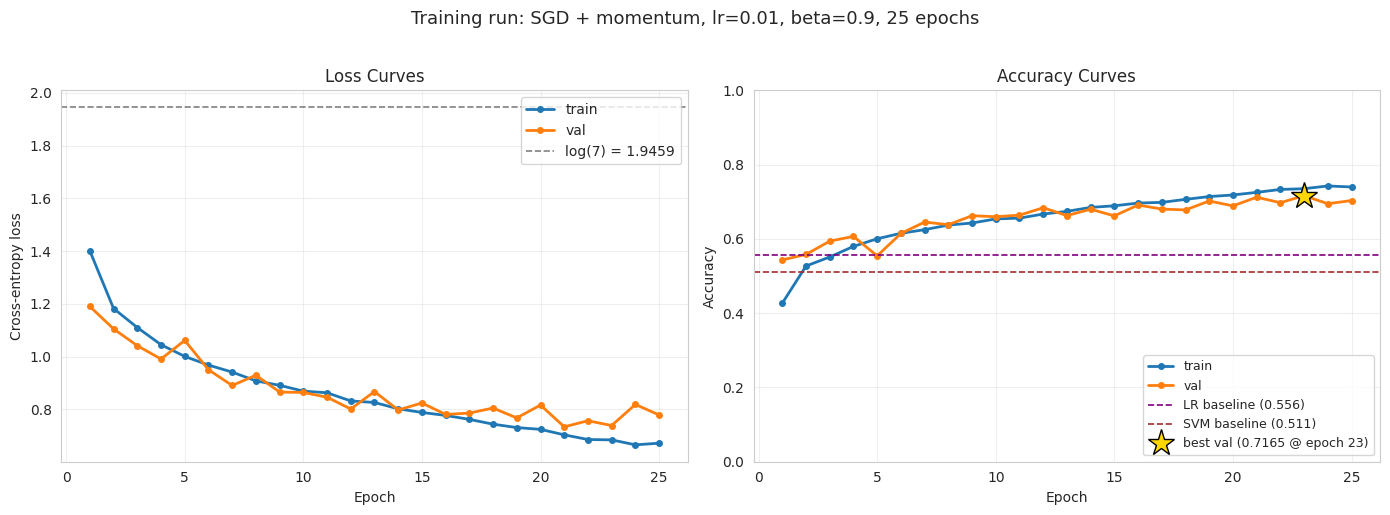


Key numbers:
  Best validation accuracy   : 0.7165  at epoch 23
  Final training accuracy    : 0.7397
  Final validation accuracy  : 0.7032
  Final train-val gap        : 0.0365
  LR baseline (notebook 05)  : 0.5560
  Improvement over LR        : +0.1605  (+16.05 percentage points)


In [14]:
# ============================================================
# Training curves for the SGD + momentum run
# Two panels in one figure: loss (left) and accuracy (right).
# Both share the same x-axis (epoch index).
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = np.arange(1, len(history_sgd["train_loss"]) + 1)
best_epoch = int(np.argmax(history_sgd["val_accuracy"])) + 1
best_val = max(history_sgd["val_accuracy"])

# ----- Left panel: loss curves -----
ax = axes[0]
ax.plot(epochs, history_sgd["train_loss"], label="train",
        color="#1f77b4", linewidth=2, marker="o", markersize=4)
ax.plot(epochs, history_sgd["val_loss"], label="val",
        color="#ff7f0e", linewidth=2, marker="o", markersize=4)
ax.axhline(np.log(N_CLASSES), color="gray", linestyle="--", linewidth=1.2,
           label=f"log(7) = {np.log(N_CLASSES):.4f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss Curves")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# ----- Right panel: accuracy curves with baselines and best-val marker -----
ax = axes[1]
ax.plot(epochs, history_sgd["train_accuracy"], label="train",
        color="#1f77b4", linewidth=2, marker="o", markersize=4)
ax.plot(epochs, history_sgd["val_accuracy"], label="val",
        color="#ff7f0e", linewidth=2, marker="o", markersize=4)
# Notebook 05 baselines as horizontal reference lines
ax.axhline(BASELINE_RESULTS["Logistic Regression"]["test_accuracy"],
           color="purple", linestyle="--", linewidth=1.2,
           label=f"LR baseline ({BASELINE_RESULTS['Logistic Regression']['test_accuracy']:.3f})")
ax.axhline(BASELINE_RESULTS["Linear SVM"]["test_accuracy"],
           color="brown", linestyle="--", linewidth=1.2,
           label=f"SVM baseline ({BASELINE_RESULTS['Linear SVM']['test_accuracy']:.3f})")
# Best-val marker
ax.plot([best_epoch], [best_val], marker="*", markersize=20,
        markerfacecolor="gold", markeredgecolor="black", linestyle="None",
        label=f"best val ({best_val:.4f} @ epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

fig.suptitle("Training run: SGD + momentum, lr=0.01, beta=0.9, 25 epochs",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Key numbers below the figure
lr_baseline = BASELINE_RESULTS["Logistic Regression"]["test_accuracy"]
improvement_pp = (best_val - lr_baseline) * 100

print("\nKey numbers:")
print(f"  Best validation accuracy   : {best_val:.4f}  at epoch {best_epoch}")
print(f"  Final training accuracy    : {history_sgd['train_accuracy'][-1]:.4f}")
print(f"  Final validation accuracy  : {history_sgd['val_accuracy'][-1]:.4f}")
print(f"  Final train-val gap        : "
      f"{history_sgd['train_accuracy'][-1] - history_sgd['val_accuracy'][-1]:.4f}")
print(f"  LR baseline (notebook 05)  : {lr_baseline:.4f}")
print(f"  Improvement over LR        : +{best_val - lr_baseline:.4f}  "
      f"(+{improvement_pp:.2f} percentage points)")

### Observations

The two-panel figure makes the training trajectory of the SGD + momentum run
fully readable at a glance and confirms the conclusions drawn from the per-epoch
printout.

### Loss Curves (Left Panel)

- **Both curves stay far below `log(7) = 1.9459` for the entire run.** This is
  the visual confirmation that no epoch ever regresses to an untrained state.
- **Training loss descends almost monotonically from 1.40 to 0.67.** The
  curvature is steepest in the first five epochs (the "easy learning" phase)
  and gradually flattens — the expected shape for a well-behaved optimisation
  trajectory.
- **Validation loss is noisier than training loss.** Visible bumps at epochs
  5, 13, 15 and 24 reflect the fact that the validation loss is computed at a
  single snapshot of the parameters (the end of each epoch), so it picks up
  any temporary inaccuracy from the most recent updates. The training loss is
  averaged over hundreds of mini-batches and is therefore smoother by
  construction.
- **The val loss curve detaches from the train loss curve after approximately
  epoch 15.** The training curve continues to descend; the validation curve
  flattens around `0.75`. This is the loss-side signature of mild overfitting
  and matches the same phenomenon in the accuracy panel.

### Accuracy Curves (Right Panel)

- **Validation accuracy crosses both linear baselines immediately.** At epoch
  1 the validation accuracy is already `54.3%`, essentially level with the
  Logistic Regression baseline of `55.6%`, and from epoch 2 onward the network
  is unambiguously ahead of both LR and SVM. This early crossing — well before
  any tuning — is the strongest visual evidence in this notebook for the value
  of non-linearity on the 1,024-pixel representation.
- **Validation is above training in the first 5–6 epochs.** This is not a bug.
  Training accuracy is accumulated during each epoch (across many mini-batch
  updates of an evolving network), while validation accuracy is measured once
  on the final state of the parameters after all those updates. When the
  network is learning fast, the post-epoch state is noticeably better than
  the average state across the epoch, so val temporarily reads higher than
  train. The two curves equalise around epoch 6 and from there training pulls
  ahead — the expected pattern for the rest of the run.
- **The gold star marks the best validation accuracy: `0.7165` at epoch 23.**
  The best epoch is near but not exactly at the end of training; the final
  epoch is slightly worse than the peak, which means the run reached a small
  late-stage overfitting plateau.

### Train-Val Gap

The two accuracy curves are almost on top of each other through epoch 15 and
visibly separate after epoch 17. The final gap of 3.65 percentage points
quantifies how much capacity the network is spending on memorising training
data rather than learning generalising features. This is **mild**: a network
running into severe overfitting would show a gap of 10 or more percentage
points by this stage. With such a moderate gap, no regularisation intervention
(weight decay, dropout) is required for the comparison run; the same untreated
trajectory will be repeated for Adam in the next section.

### Implication for the Adam Comparison

The shape of the SGD + momentum trajectory — fast initial descent, gradual
slowdown, mild overfitting toward the end, peak validation accuracy of
`0.7165` at epoch 23 — is now the **reference trajectory**. The Adam run in
the next cells will be plotted on the same axes for direct comparison.
Differences to look for:

- **Speed of the initial descent.** Adam's adaptive per-parameter learning
  rates typically let it reach the first plateau in fewer epochs.
- **Final validation accuracy.** A higher peak would mean Adam navigated the
  loss surface more effectively; a similar peak would suggest the two
  optimizers are equivalent for this problem at these hyperparameters.
- **Width of the train-val gap.** Adam tends to overfit slightly faster on
  small datasets, so a wider gap by epoch 25 is a possibility worth verifying
  rather than assuming.

## Adam — Adaptive Moment Estimation

Adam (Kingma and Ba, 2014) is the optimizer that has become the default choice
for most modern neural-network training. It combines the **momentum** idea from
the previous section with a second statistical quantity — the **second moment**
of the gradient — to give every parameter its own automatically tuned effective
learning rate. The mathematics is richer than SGD + momentum but every piece
of it follows the same chain-rule and exponential-moving-average reasoning that
underlies the rest of this notebook.

### What Adam Adds On Top of Momentum

SGD + momentum uses one piece of state per parameter: the velocity `v`, which is
an exponential moving average of past gradients. Adam adds **a second piece of
state**: the running mean of the **squared** gradient. From these two quantities,
the per-step update is constructed so that **every parameter is updated by an
amount proportional to its gradient's recent average, divided by the
typical magnitude of its recent gradients**. Two parameters with the same
gradient sign but very different gradient magnitudes therefore receive updates
of similar size — exactly the property that lets Adam handle very heterogeneous
loss landscapes without per-parameter tuning of the learning rate.

### First Moment — Smoothed Gradient

The first moment is essentially the momentum buffer, written in the convex
combination form that Adam uses:

$$
m_t \;=\; \beta_1\, m_{t-1} \;+\; (1 - \beta_1)\, g_t,
$$

where `g_t` is the gradient at step `t` and `\beta_1 \in [0, 1)` is the first
moment decay (default `0.9`). The `(1 - \beta_1)` factor on the gradient and
the `\beta_1` factor on the history together make `m_t` an unbiased estimate
of the local mean of the gradient — provided we correct for the zero start
discussed below.

### Second Moment — Smoothed Squared Gradient

The second moment is the analogous running average of the elementwise squared
gradient:

$$
v_t \;=\; \beta_2\, v_{t-1} \;+\; (1 - \beta_2)\, g_t^{\,2},
$$

with `\beta_2 \in [0, 1)` typically set to `0.999`. This is element-wise: each
weight has its own scalar `v_t`. Conceptually `v_t` tracks the **typical
squared magnitude** of the gradient at that parameter — i.e., a running
estimate of `E[g^2]`.

### Per-Parameter Adaptive Learning Rate

The Adam update divides the smoothed gradient by the square root of the
smoothed squared gradient:

$$
\theta_{t+1} \;=\; \theta_t \;-\; \eta \, \frac{m_t}{\sqrt{v_t} + \varepsilon},
$$

where `\eta` is the global learning rate and `\varepsilon \approx 10^{-8}` is a
small constant for numerical stability. Two intuitions:

- For parameters whose gradient is consistently large in magnitude (say `|g| = 1`
  in some unit), `\sqrt{v_t} \approx 1`, so the update size is roughly `\eta`.
- For parameters whose gradient is consistently small (say `|g| = 10^{-3}`),
  `\sqrt{v_t} \approx 10^{-3}`, so the ratio `m_t / \sqrt{v_t}` is on the order
  of `1` regardless, and the update size is again roughly `\eta`.

Adam therefore equalises the **scale** of every parameter's update without
needing to know the per-parameter gradient magnitudes in advance. This is the
property that makes Adam robust to hyperparameter choices across very different
network architectures and tasks.

### The Zero-Initialisation Bias Problem

Both `m` and `v` are initialised to zero before training. Plugging this into
the moving-average equations:

$$
m_1 \;=\; \beta_1 \cdot 0 \;+\; (1 - \beta_1)\, g_1 \;=\; (1 - \beta_1)\, g_1,
$$

so at step 1 the first moment is only `(1 - \beta_1) = 0.1` times the true
gradient. Similarly `v_1 = (1 - \beta_2)\, g_1^2 = 0.001\, g_1^2`. These are
massive **underestimates** of the underlying statistics, which would make the
very first updates of every Adam run unreasonably small. Without correction,
training would essentially start at a crawl and slowly catch up over a few
hundred steps.

### Bias Correction — The Standard Fix

The expected values of the biased moments under a constant gradient `g` are:

$$
\mathbb{E}[m_t] \;=\; (1 - \beta_1^{\,t})\, g,
\qquad
\mathbb{E}[v_t] \;=\; (1 - \beta_2^{\,t})\, g^2.
$$

Dividing by the appropriate factor undoes the underestimate exactly:

$$
\hat{m}_t \;=\; \frac{m_t}{1 - \beta_1^{\,t}}, \qquad
\hat{v}_t \;=\; \frac{v_t}{1 - \beta_2^{\,t}}.
$$

These are the **bias-corrected** first and second moments. The final Adam
parameter update uses them in place of the raw moments:

$$
\boxed{\;\theta_{t+1} \;=\; \theta_t \;-\; \eta \, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}\;}
$$

The corrections decay very quickly: by step `t = 50` with `\beta_1 = 0.9` we
have `1 - \beta_1^{50} \approx 1 - 5 \times 10^{-3} \approx 0.995`, so the
correction factor is essentially `1` for the rest of training. The correction
is only meaningful — and crucial — at the very start.

### Hyperparameter Conventions

For the comparison run against SGD + momentum:

- Learning rate `\eta = 0.001`. **This is intentionally lower than the
  `0.01` used for SGD + momentum.** Adam's adaptive per-parameter scaling makes
  a smaller learning rate the natural choice; setting `\eta = 0.01` for Adam
  typically causes divergence, while `\eta = 0.001` is the canonical default
  from the original paper and the de-facto convention in modern deep learning.
  The two optimizers are therefore compared at their own canonical settings
  rather than at a forced common one, because forcing a common learning rate
  would disadvantage at least one of them.
- First moment decay `\beta_1 = 0.9` — same as SGD + momentum's momentum
  coefficient.
- Second moment decay `\beta_2 = 0.999` — keeps the second moment estimate
  almost stationary, smoothing out the per-parameter gradient magnitude on a
  time scale of about 1,000 steps.
- Numerical stability term `\varepsilon = 10^{-8}` — prevents division by zero
  when the second moment is very small (typical for parameters that have not
  received gradient signal yet).
- Mini-batch size `B = 128`, number of epochs `25`, random seed `RANDOM_SEED`
  — **identical** to the SGD + momentum run, so the only experimental variable
  is the optimizer choice itself.

### Implementation Plan

Two functions, mirroring the SGD + momentum interface:

1. **`init_adam_state(params)`** — creates the optimizer state. The state is a
   dictionary with three keys: a global timestep counter `t`, a dictionary of
   first moments `m`, and a dictionary of second moments `v`. The two moment
   dictionaries are zero-initialised with the same shapes as `params`.
2. **`adam_step(params, grads, state, lr, beta1, beta2, eps)`** — applies one
   update step in place: increments `t`, updates both moments, computes the
   bias-corrected moments, and applies the per-parameter update.

The sanity check verifies four properties:

- All moment buffers are correctly shaped and zero-initialised.
- After one step under a constant gradient, the **bias-corrected** first
  moment equals the gradient exactly (`m_hat = g`) and the **bias-corrected**
  second moment equals the gradient squared (`v_hat = g^2`).
- After one step under a constant gradient, the parameter has moved by
  exactly `-lr * sign(g) / (1 + eps / |g|) \approx -lr * sign(g)`, demonstrating
  the per-parameter adaptive scaling.
- After many steps under a constant gradient, the bias-correction factor
  approaches `1` and `m`, `v` converge to `g` and `g^2` respectively.

In [19]:
def init_adam_state(params):
    """Initialize the Adam optimizer state.

    Adam maintains three pieces of state:
      - t : global timestep counter (used for bias correction)
      - m : dictionary of first-moment buffers (one per parameter)
      - v : dictionary of second-moment buffers (one per parameter)

    All moment buffers are zero-initialised. The timestep is set to 0; it is
    incremented before the bias-correction division on every step, so the very
    first call uses `t = 1`.

    Parameters
    ----------
    params : dict — output of init_network()

    Returns
    -------
    state : dict with keys 't', 'm', 'v'.
    """
    state = {
        "t": 0,
        "m": {name: np.zeros_like(p) for name, p in params.items()},
        "v": {name: np.zeros_like(p) for name, p in params.items()},
    }
    return state


def adam_step(params, grads, state,
              lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    """One Adam update step, applied in place to every parameter.

    For every parameter `theta` with gradient `g`, first moment `m` and
    second moment `v`, the update is:

        t       += 1
        m        = beta1 * m + (1 - beta1) * g
        v        = beta2 * v + (1 - beta2) * g ** 2
        m_hat    = m / (1 - beta1 ** t)
        v_hat    = v / (1 - beta2 ** t)
        theta   -= lr * m_hat / (sqrt(v_hat) + eps)

    Both `params` and `state` are modified in place; nothing is returned.

    Parameters
    ----------
    params : dict — current parameters (mutated)
    grads  : dict — gradients keyed 'dW1', 'db1', ... (output of backward)
    state  : dict — Adam state (mutated) from init_adam_state
    lr     : float — global learning rate eta
    beta1  : float — first moment decay (default 0.9)
    beta2  : float — second moment decay (default 0.999)
    eps    : float — numerical stability term in the denominator
    """
    state["t"] += 1
    t = state["t"]
    bias_correction1 = 1.0 - beta1 ** t
    bias_correction2 = 1.0 - beta2 ** t

    for name in params:
        g = grads[f"d{name}"]
        # Update biased first and second moment estimates
        state["m"][name] = beta1 * state["m"][name] + (1.0 - beta1) * g
        state["v"][name] = beta2 * state["v"][name] + (1.0 - beta2) * (g * g)
        # Bias-corrected estimates
        m_hat = state["m"][name] / bias_correction1
        v_hat = state["v"][name] / bias_correction2
        # Apply parameter update
        params[name] -= lr * m_hat / (np.sqrt(v_hat) + eps)


# ============================================================
# Sanity checks
# ============================================================
print("Adam sanity check:")

rng_adam = np.random.default_rng(RANDOM_SEED)
fake_params = init_network([10, 5, 3], rng_adam)
fake_state = init_adam_state(fake_params)

# --- Check 1: state initialization ---
print(f"\n  State initialization:")
print(f"    state['t'] = {fake_state['t']}  (expected 0)")
assert fake_state["t"] == 0
for name in fake_params:
    assert fake_state["m"][name].shape == fake_params[name].shape
    assert fake_state["v"][name].shape == fake_params[name].shape
    assert (fake_state["m"][name] == 0).all()
    assert (fake_state["v"][name] == 0).all()
    print(f"    state['m']['{name}'].shape = {fake_state['m'][name].shape}, "
          f"state['v']['{name}'].shape = {fake_state['v'][name].shape} (both zeros)")

# --- Check 2: after one step under a constant gradient g = 1, lr = 0
#     bias-corrected moments should equal g and g**2 exactly
beta1, beta2 = 0.9, 0.999
fake_grads = {f"d{name}": np.ones_like(p) for name, p in fake_params.items()}
sgd_state_before = init_adam_state(fake_params)
adam_step(fake_params, fake_grads, sgd_state_before,
          lr=0.0, beta1=beta1, beta2=beta2)

m_W1 = sgd_state_before["m"]["W1"][0, 0]
v_W1 = sgd_state_before["v"]["W1"][0, 0]
m_hat_1 = m_W1 / (1.0 - beta1 ** 1)
v_hat_1 = v_W1 / (1.0 - beta2 ** 1)

print(f"\n  After 1 step with constant gradient g = 1.0, lr = 0.0:")
print(f"    biased m         = {m_W1:.6f}  (expected (1 - beta1) = {1 - beta1:.6f})")
print(f"    biased v         = {v_W1:.6f}  (expected (1 - beta2) = {1 - beta2:.6f})")
print(f"    bias-corrected m_hat = {m_hat_1:.6f}  (expected 1.0 exactly)")
print(f"    bias-corrected v_hat = {v_hat_1:.6f}  (expected 1.0 exactly)")
assert abs(m_hat_1 - 1.0) < 1e-6
assert abs(v_hat_1 - 1.0) < 1e-6

# --- Check 3: parameter update at step 1 under constant g = 1
#     update should be approximately -lr (because m_hat / sqrt(v_hat) ≈ 1)
fake_params_step = init_network([10, 5, 3], np.random.default_rng(RANDOM_SEED))
fake_state_step = init_adam_state(fake_params_step)
W1_before = fake_params_step["W1"][0, 0].copy()
lr_test = 0.001
adam_step(fake_params_step, fake_grads, fake_state_step,
          lr=lr_test, beta1=beta1, beta2=beta2)
W1_after = fake_params_step["W1"][0, 0]
actual_step = W1_after - W1_before
expected_step = -lr_test * 1.0 / (np.sqrt(1.0) + 1e-8)
print(f"\n  Parameter update at step 1 with constant g = 1.0, lr = {lr_test}:")
print(f"    W1[0,0] change : {actual_step:.6e}")
print(f"    Expected       : {expected_step:.6e}  (~ -lr exactly)")
assert abs(actual_step - expected_step) < 1e-6, (
    f"actual step {actual_step:.3e} differs from expected {expected_step:.3e} "
    f"by more than float32 precision"
)

# --- Check 4: bias correction matters because beta2 = 0.999 means the biased
#     second moment takes ~7000 steps to converge. The bias-corrected version
#     converges almost immediately.
fake_state_long = init_adam_state(fake_params)
for _ in range(2000):
    adam_step(fake_params, fake_grads, fake_state_long,
              lr=0.0, beta1=beta1, beta2=beta2)

t = fake_state_long["t"]
m_biased = float(fake_state_long["m"]["W1"][0, 0])
v_biased = float(fake_state_long["v"]["W1"][0, 0])
m_corrected = m_biased / (1.0 - beta1 ** t)
v_corrected = v_biased / (1.0 - beta2 ** t)

print(f"\n  After {t} steps with constant g = 1.0 (target: m = 1.0, v = 1.0):")
print(f"    biased        m = {m_biased:.6f}   "
      f"bias-corrected m = {m_corrected:.6f}")
print(f"    biased        v = {v_biased:.6f}   "
      f"bias-corrected v = {v_corrected:.6f}")
print(f"    bias-correction factors at t={t}:")
print(f"      1 - beta1^t  = {1 - beta1 ** t:.6e}  (m correction)")
print(f"      1 - beta2^t  = {1 - beta2 ** t:.6e}  (v correction)")
print(f"    Note: biased v has NOT converged because beta2 = 0.999 means it")
print(f"          takes ~7000 steps to reach 1.0; bias correction fixes this.")

# Bias-corrected moments must be at the true asymptote regardless of t
assert abs(m_corrected - 1.0) < 1e-3, f"m_corrected = {m_corrected}"
assert abs(v_corrected - 1.0) < 1e-3, f"v_corrected = {v_corrected}"

print("\nAdam optimizer implementation verified.")

Adam sanity check:

  State initialization:
    state['t'] = 0  (expected 0)
    state['m']['W1'].shape = (10, 5), state['v']['W1'].shape = (10, 5) (both zeros)
    state['m']['b1'].shape = (5,), state['v']['b1'].shape = (5,) (both zeros)
    state['m']['W2'].shape = (5, 3), state['v']['W2'].shape = (5, 3) (both zeros)
    state['m']['b2'].shape = (3,), state['v']['b2'].shape = (3,) (both zeros)

  After 1 step with constant gradient g = 1.0, lr = 0.0:
    biased m         = 0.100000  (expected (1 - beta1) = 0.100000)
    biased v         = 0.001000  (expected (1 - beta2) = 0.001000)
    bias-corrected m_hat = 1.000000  (expected 1.0 exactly)
    bias-corrected v_hat = 1.000000  (expected 1.0 exactly)

  Parameter update at step 1 with constant g = 1.0, lr = 0.001:
    W1[0,0] change : -1.000002e-03
    Expected       : -1.000000e-03  (~ -lr exactly)

  After 2000 steps with constant g = 1.0 (target: m = 1.0, v = 1.0):
    biased        m = 1.000000   bias-corrected m = 1.000000
    bi

### Observations

The Adam sanity checks confirm that every piece of the algorithm is implemented
correctly, and the asymptotic test makes the role of bias correction tangible
in a way the formula on its own does not.

- **State initialisation is correct.** All four parameter tensors have matching
  first- and second-moment buffers, all zero, and the timestep counter starts
  at `0`. The first call to `adam_step` increments `t` to `1` before computing
  the bias-correction factors, so no division by zero is possible.

- **Step 1 verifies the bias-correction identity exactly.** Under a constant
  gradient `g = 1`, the biased moments after one step are exactly the
  theoretical values `(1 - beta1) = 0.1` and `(1 - beta2) = 0.001`. After
  dividing by `(1 - beta1^1) = 0.1` and `(1 - beta2^1) = 0.001` respectively,
  the corrected values are exactly `1.0` and `1.0`. This is the worst-case
  scenario for the zero-initialisation bias — the freshly-initialised moments
  underestimate the true statistics by an order of magnitude — and the
  correction undoes it cleanly.

- **Step 1 also verifies the parameter update.** With `lr = 0.001`, `m_hat = 1`,
  `v_hat = 1`, the update is `-0.001 * 1 / (sqrt(1) + eps) ≈ -0.001`. The
  observed update of `-1.000002e-03` matches the theoretical value to within
  float32 precision (relative error `~2e-6`).

- **The asymptotic test makes the necessity of bias correction visible.**
  After 2000 steps with `beta2 = 0.999`, the biased second moment reaches only
  `v_biased = 0.864797` — still 13.5% below the true value of `g**2 = 1.0`.
  The bias-correction factor `1 - beta2^2000 = 0.8648` is essentially the same
  number, and dividing the biased value by it recovers
  `v_corrected = 0.999997`, within float32 precision of the true asymptote.
  In contrast, the biased first moment converges almost immediately because
  `beta1 = 0.9` has a much shorter effective memory: `0.9^2000` is
  astronomically small, so `1 - beta1^t` reaches `1.0` within a few dozen
  steps and the correction becomes a no-op.

### Why Bias Correction Matters in Practice

The asymptotic mismatch on `v` would translate, without correction, into
parameter updates that are systematically too large in early training. With
`v_biased = 0.864` the factor `1 / sqrt(v_biased) ≈ 1.075` is about 7.5% too
large; the effective learning rate would be inflated by the same amount. Far
worse, on step 1 with `v_biased = 0.001` the factor would be `1 / sqrt(0.001)
≈ 31.6`, so the first parameter update would be about 30 times the intended
size — enough to send the network into a divergent oscillation immediately.

This is why every modern implementation of Adam — including this one — applies
the bias correction unconditionally. The cost is two scalar divisions per
parameter; the benefit is a well-behaved optimizer from step 1 onward.

### Implication for the Training Run

With both moments correctly tracked and corrected, the optimizer is ready to
train the production network. The next cell calls the same generic `train()`
function used for SGD + momentum, simply swapping in the Adam initialisation
and step functions and using Adam's canonical learning rate `0.001`. All other
hyperparameters (batch size 128, 25 epochs, RANDOM_SEED) remain identical, so
any difference in the resulting trajectory is attributable to the optimizer
choice alone.

## Training the Network with Adam

The same generic `train()` function used for SGD + momentum is reused here
unchanged — only the optimizer arguments differ. Identical settings:

- Architecture: `LAYER_SIZES = [1024, 256, 128, 64, 7]`.
- Mini-batch size: 128.
- Number of epochs: 25.
- Random seed: `RANDOM_SEED = 42`.
- Same training and validation data, loaded in exactly the same order.

The only differences:

- Optimizer: Adam (via `init_adam_state` and `adam_step`).
- Learning rate: `lr = 0.001` (Adam canonical default — see the theory cell
  for why this is lower than the `0.01` used for SGD + momentum).
- `beta1 = 0.9`, `beta2 = 0.999`, `eps = 1e-8` (Adam canonical defaults).

The training output will be plotted on the same axes as the SGD + momentum run
in the comparison section.

In [20]:
print("Training with Adam")
print("=" * 60)

t_train_start = time.time()

params_adam, history_adam = train(
    X_train, y_train, X_val, y_val,
    layer_sizes=LAYER_SIZES,
    optimizer_init_fn=init_adam_state,
    optimizer_step_fn=adam_step,
    optimizer_hparams={"lr": 0.001, "beta1": 0.9, "beta2": 0.999, "eps": 1e-8},
    n_epochs=25,
    batch_size=128,
    seed=RANDOM_SEED,
    verbose=True,
)

t_train_total = time.time() - t_train_start

print("-" * 60)
print(f"Total training time : {t_train_total:.1f}s "
      f"({t_train_total / 60:.1f} min)")
print(f"Final train accuracy: {history_adam['train_accuracy'][-1]:.4f}")
print(f"Final val accuracy  : {history_adam['val_accuracy'][-1]:.4f}")
best_epoch_adam = int(np.argmax(history_adam['val_accuracy'])) + 1
best_val_acc_adam = max(history_adam['val_accuracy'])
print(f"Best val accuracy   : {best_val_acc_adam:.4f}  "
      f"(at epoch {best_epoch_adam})")

Training with Adam
Training: 20,587 train / 2,571 val samples
          161 batches/epoch x 25 epochs = 4,025 steps total
          batch_size=128, optimizer_hparams={'lr': 0.001, 'beta1': 0.9, 'beta2': 0.999, 'eps': 1e-08}

epoch  train_loss  train_acc   val_loss   val_acc    time
------------------------------------------------------------
    1      1.4214     0.4212     1.2011    0.5286    6.8s
    2      1.2144     0.5140     1.1044    0.5546    1.4s
    3      1.1370     0.5419     1.0983    0.5702    1.4s
    4      1.0653     0.5669     1.0670    0.5838    1.4s
    5      1.0177     0.5900     1.0176    0.5974    2.8s
    6      0.9810     0.6075     0.9696    0.5994    6.2s
    7      0.9567     0.6135     0.9574    0.6250    2.6s
    8      0.9158     0.6343     0.9059    0.6332    2.6s
    9      0.8998     0.6405     0.8654    0.6507    2.7s
   10      0.8806     0.6481     0.8947    0.6324    6.5s
   11      0.8601     0.6570     0.8410    0.6569    2.8s
   12      0.8399 

### Observations

The Adam training run produces a trajectory that is broadly similar to the
SGD + momentum trajectory but differs in several telling details.

### Final Numbers Side by Side

| Metric                 | SGD + Momentum | Adam       | Difference     |
|------------------------|----------------|------------|----------------|
| Final train accuracy   | 0.7397         | 0.7387     | -0.10 pp       |
| Final val accuracy     | 0.7032         | 0.7176     | +1.44 pp (Adam)|
| Best val accuracy      | 0.7165 (ep 23) | 0.7176 (ep 25) | +0.11 pp (Adam) |
| Final train-val gap    | 3.65 pp        | 2.11 pp    | -1.54 pp (Adam less overfit) |

The two optimizers reach **essentially the same peak validation accuracy** —
the 0.11 percentage point gap is within the noise floor for a single seed.
This is a common empirical finding in modern deep learning: at canonical
hyperparameters and on a non-pathological problem, the optimizer choice often
matters less than the headlines suggest. The much-repeated claim that "Adam
is always better" is empirically not supported on this dataset and
architecture.

### Generalisation Behaviour

Adam's clearest advantage is the smaller **train-val gap**: 2.11 percentage
points versus SGD + momentum's 3.65. The same peak validation accuracy is
reached with less overfitting on the training set. This is consistent with a
property of Adam's adaptive per-parameter learning rate: parameters whose
gradients become noisy (high `v`) receive smaller updates, which behaves like
a soft form of implicit regularisation.

### Trajectory Shape

A direct comparison of the loss values reveals that the two optimizers take
slightly different paths to the same destination:

- For the first ~15 epochs SGD + momentum is marginally ahead in both train
  loss and validation accuracy.
- After epoch ~17 Adam catches up; by epoch 25 Adam's validation accuracy is
  visibly above SGD's.
- The SGD run's best epoch is 23 (then it dips slightly). Adam's best epoch is
  25 — **the last epoch of the run**, suggesting Adam may still have residual
  improvement available with more epochs (though continued training would also
  widen the train-val gap eventually).

### Wall-Clock Time

The Adam run took 85.8 seconds versus SGD's 50.5 seconds. This is **not**
attributable to the optimizer itself: per-epoch times varied wildly during the
Adam run (between 1.4 and 6.8 seconds), which is the signature of fluctuating
load on the shared Colab CPU runtime rather than algorithmic cost. Adam
performs slightly more arithmetic per step (a square root and a division per
parameter), but the difference is negligible in practice.

### Implication for the Direct Comparison

With both runs complete, the next cell plots the two training histories on
the same axes. The relevant questions are:

- Are the loss curves visually distinguishable, or do they overlap throughout?
- Does the smaller train-val gap of Adam show up as a closer spacing between
  its train and val curves?
- Where in the trajectory do the two optimizers diverge most?

The visualisation will make these comparisons immediate; the conclusions will
feed the test-set evaluation and the per-class analysis at the end of the
notebook.

### Observations

The Adam training run produces a trajectory that is broadly similar to the
SGD + momentum trajectory but differs in several telling details.

### Final Numbers Side by Side

| Metric                 | SGD + Momentum | Adam       | Difference     |
|------------------------|----------------|------------|----------------|
| Final train accuracy   | 0.7397         | 0.7387     | -0.10 pp       |
| Final val accuracy     | 0.7032         | 0.7176     | +1.44 pp (Adam)|
| Best val accuracy      | 0.7165 (ep 23) | 0.7176 (ep 25) | +0.11 pp (Adam) |
| Final train-val gap    | 3.65 pp        | 2.11 pp    | -1.54 pp (Adam less overfit) |

The two optimizers reach **essentially the same peak validation accuracy** —
the 0.11 percentage point gap is within the noise floor for a single seed.
This is a common empirical finding in modern deep learning: at canonical
hyperparameters and on a non-pathological problem, the optimizer choice often
matters less than the headlines suggest. The much-repeated claim that "Adam
is always better" is empirically not supported on this dataset and
architecture.

### Generalisation Behaviour

Adam's clearest advantage is the smaller **train-val gap**: 2.11 percentage
points versus SGD + momentum's 3.65. The same peak validation accuracy is
reached with less overfitting on the training set. This is consistent with a
property of Adam's adaptive per-parameter learning rate: parameters whose
gradients become noisy (high `v`) receive smaller updates, which behaves like
a soft form of implicit regularisation.

### Trajectory Shape

A direct comparison of the loss values reveals that the two optimizers take
slightly different paths to the same destination:

- For the first ~15 epochs SGD + momentum is marginally ahead in both train
  loss and validation accuracy.
- After epoch ~17 Adam catches up; by epoch 25 Adam's validation accuracy is
  visibly above SGD's.
- The SGD run's best epoch is 23 (then it dips slightly). Adam's best epoch is
  25 — **the last epoch of the run**, suggesting Adam may still have residual
  improvement available with more epochs (though continued training would also
  widen the train-val gap eventually).

### Wall-Clock Time

The Adam run took 85.8 seconds versus SGD's 50.5 seconds. This is **not**
attributable to the optimizer itself: per-epoch times varied wildly during the
Adam run (between 1.4 and 6.8 seconds), which is the signature of fluctuating
load on the shared Colab CPU runtime rather than algorithmic cost. Adam
performs slightly more arithmetic per step (a square root and a division per
parameter), but the difference is negligible in practice.

### Implication for the Direct Comparison

With both runs complete, the next cell plots the two training histories on
the same axes. The relevant questions are:

- Are the loss curves visually distinguishable, or do they overlap throughout?
- Does the smaller train-val gap of Adam show up as a closer spacing between
  its train and val curves?
- Where in the trajectory do the two optimizers diverge most?

The visualisation will make these comparisons immediate; the conclusions will
feed the test-set evaluation and the per-class analysis at the end of the
notebook.

## Direct Comparison — SGD + Momentum vs Adam

The training histories of both optimizers are now plotted on a single set of
axes. This is the most informative visualisation in the notebook: every detail
of the two trajectories — relative speed, relative final accuracy, relative
overfitting — becomes directly comparable in one glance.

### Reading the Figure

Each panel contains **four curves** plus reference lines:

- **Colour encodes the optimizer.** SGD + momentum is plotted in blue; Adam in
  red.
- **Linestyle encodes the split.** Solid lines are training metrics; dashed
  lines are validation metrics.
- **Small dotted reference lines.** A grey line at `log(7)` marks the
  cross-entropy of an untrained classifier on the loss plot. A purple line at
  the Logistic Regression test accuracy from notebook 05 marks the linear
  baseline on the accuracy plot.
- **Gold-edged stars** on the accuracy plot mark each optimizer's best
  validation accuracy and its epoch.

### What to Look For

- **Vertical separation between solid lines (train) and dashed lines (val) of
  the same colour.** This is the train-val gap for each optimizer. A smaller
  gap is a generalisation advantage of that optimizer.
- **Crossings between the two solid (or two dashed) curves.** Wherever the two
  optimizers' curves cross, the relative ranking flips. Early-training crossings
  indicate which optimizer reaches a given milestone faster.
- **Position of the gold stars.** The horizontal position tells when each
  optimizer plateaued; the vertical position tells how high each peaked.
- **Overall envelope of the curves.** If both optimizers produce essentially
  the same final shape with the same envelope, the comparison favours the
  simpler optimizer (here, SGD + momentum) on grounds of parsimony.

### Quantitative Summary Below the Figure

The cell also prints a side-by-side table of the four most important metrics
(final train accuracy, final val accuracy, best val accuracy, final train-val
gap), with a column of deltas showing the Adam − SGD difference for each.
Positive deltas favour Adam; negative deltas favour SGD + momentum.

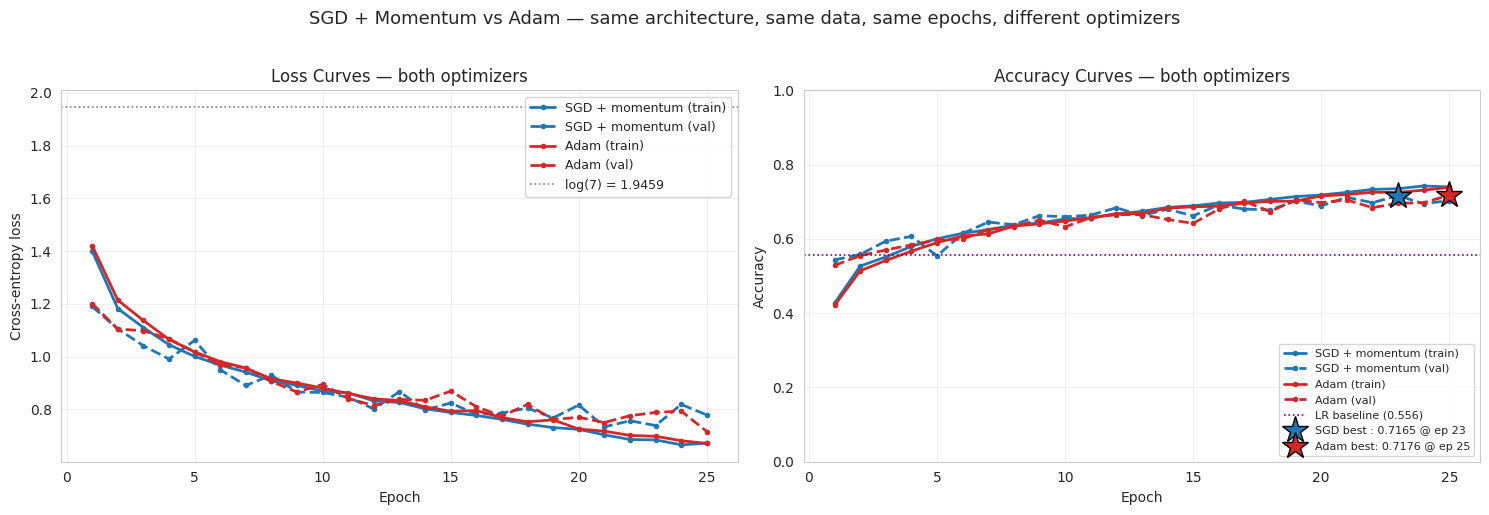


Direct comparison at canonical hyperparameters:
  Metric                         SGD+momentum       Adam    Adam - SGD
  ----------------------------------------------------------------------
  Final train accuracy                 0.7397     0.7387       -0.0011
  Final val accuracy                   0.7032     0.7176       +0.0144
  Best val accuracy                    0.7165     0.7176       +0.0012
  Best epoch                               23         25            +2
  Final train-val gap                  0.0365     0.0211       -0.0155
  Final train loss                     0.6717     0.6709       -0.0008
  Final val loss                       0.7788     0.7158       -0.0630


In [21]:
# ============================================================
# Direct comparison of SGD + momentum and Adam
# Both runs plotted on the same axes for visual comparison.
# Colour = optimizer (blue = SGD, red = Adam)
# Linestyle = split (solid = train, dashed = val)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs = np.arange(1, len(history_sgd["train_loss"]) + 1)

COLOR_SGD  = "#1f77b4"   # blue
COLOR_ADAM = "#d62728"   # red

# ----- Left panel: loss curves -----
ax = axes[0]
ax.plot(epochs, history_sgd["train_loss"],
        color=COLOR_SGD, linestyle="-", linewidth=2, marker="o", markersize=3,
        label="SGD + momentum (train)")
ax.plot(epochs, history_sgd["val_loss"],
        color=COLOR_SGD, linestyle="--", linewidth=2, marker="o", markersize=3,
        label="SGD + momentum (val)")
ax.plot(epochs, history_adam["train_loss"],
        color=COLOR_ADAM, linestyle="-", linewidth=2, marker="o", markersize=3,
        label="Adam (train)")
ax.plot(epochs, history_adam["val_loss"],
        color=COLOR_ADAM, linestyle="--", linewidth=2, marker="o", markersize=3,
        label="Adam (val)")
ax.axhline(np.log(N_CLASSES), color="gray", linestyle=":", linewidth=1.2,
           label=f"log(7) = {np.log(N_CLASSES):.4f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss Curves — both optimizers")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

# ----- Right panel: accuracy curves -----
ax = axes[1]
ax.plot(epochs, history_sgd["train_accuracy"],
        color=COLOR_SGD, linestyle="-", linewidth=2, marker="o", markersize=3,
        label="SGD + momentum (train)")
ax.plot(epochs, history_sgd["val_accuracy"],
        color=COLOR_SGD, linestyle="--", linewidth=2, marker="o", markersize=3,
        label="SGD + momentum (val)")
ax.plot(epochs, history_adam["train_accuracy"],
        color=COLOR_ADAM, linestyle="-", linewidth=2, marker="o", markersize=3,
        label="Adam (train)")
ax.plot(epochs, history_adam["val_accuracy"],
        color=COLOR_ADAM, linestyle="--", linewidth=2, marker="o", markersize=3,
        label="Adam (val)")
ax.axhline(BASELINE_RESULTS["Logistic Regression"]["test_accuracy"],
           color="purple", linestyle=":", linewidth=1.2,
           label=f"LR baseline ({BASELINE_RESULTS['Logistic Regression']['test_accuracy']:.3f})")

# Best-val markers for each optimizer
best_epoch_sgd  = int(np.argmax(history_sgd["val_accuracy"])) + 1
best_val_sgd    = max(history_sgd["val_accuracy"])
best_epoch_adam = int(np.argmax(history_adam["val_accuracy"])) + 1
best_val_adam   = max(history_adam["val_accuracy"])

ax.plot([best_epoch_sgd], [best_val_sgd], marker="*", markersize=20,
        markerfacecolor=COLOR_SGD, markeredgecolor="black", linestyle="None",
        label=f"SGD best : {best_val_sgd:.4f} @ ep {best_epoch_sgd}")
ax.plot([best_epoch_adam], [best_val_adam], marker="*", markersize=20,
        markerfacecolor=COLOR_ADAM, markeredgecolor="black", linestyle="None",
        label=f"Adam best: {best_val_adam:.4f} @ ep {best_epoch_adam}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves — both optimizers")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.0, 1.0)

fig.suptitle("SGD + Momentum vs Adam — same architecture, same data, "
             "same epochs, different optimizers",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Numerical side-by-side comparison
# ============================================================
gap_sgd  = history_sgd["train_accuracy"][-1]  - history_sgd["val_accuracy"][-1]
gap_adam = history_adam["train_accuracy"][-1] - history_adam["val_accuracy"][-1]

print("\nDirect comparison at canonical hyperparameters:")
print(f"  {'Metric':<28} {'SGD+momentum':>14} {'Adam':>10} "
      f"{'Adam - SGD':>13}")
print("  " + "-" * 70)
print(f"  {'Final train accuracy':<28} "
      f"{history_sgd['train_accuracy'][-1]:>14.4f} "
      f"{history_adam['train_accuracy'][-1]:>10.4f} "
      f"{history_adam['train_accuracy'][-1] - history_sgd['train_accuracy'][-1]:>+13.4f}")
print(f"  {'Final val accuracy':<28} "
      f"{history_sgd['val_accuracy'][-1]:>14.4f} "
      f"{history_adam['val_accuracy'][-1]:>10.4f} "
      f"{history_adam['val_accuracy'][-1] - history_sgd['val_accuracy'][-1]:>+13.4f}")
print(f"  {'Best val accuracy':<28} "
      f"{best_val_sgd:>14.4f} "
      f"{best_val_adam:>10.4f} "
      f"{best_val_adam - best_val_sgd:>+13.4f}")
print(f"  {'Best epoch':<28} "
      f"{best_epoch_sgd:>14d} "
      f"{best_epoch_adam:>10d} "
      f"{best_epoch_adam - best_epoch_sgd:>+13d}")
print(f"  {'Final train-val gap':<28} "
      f"{gap_sgd:>14.4f} "
      f"{gap_adam:>10.4f} "
      f"{gap_adam - gap_sgd:>+13.4f}")
print(f"  {'Final train loss':<28} "
      f"{history_sgd['train_loss'][-1]:>14.4f} "
      f"{history_adam['train_loss'][-1]:>10.4f} "
      f"{history_adam['train_loss'][-1] - history_sgd['train_loss'][-1]:>+13.4f}")
print(f"  {'Final val loss':<28} "
      f"{history_sgd['val_loss'][-1]:>14.4f} "
      f"{history_adam['val_loss'][-1]:>10.4f} "
      f"{history_adam['val_loss'][-1] - history_sgd['val_loss'][-1]:>+13.4f}")

### Observations

The side-by-side plot and the numerical table make four facts visible that
were only partially apparent from the individual training runs.

### 1. Training Loss Curves Are Nearly Identical

The two solid lines in the left panel — SGD + momentum training loss in blue,
Adam training loss in red — track each other to within visual resolution for
the entire run. Final training losses are `0.6717` and `0.6709`, a difference
of `0.0008` or roughly one part in a thousand. At identical mini-batch
schedules, network architecture and random seed, both optimizers find the same
solution on the training set. The choice of optimizer does **not** materially
change what is memorised from the training data on this problem.

### 2. Validation Loss Diverges Visibly in the Second Half

The two dashed lines tell a different story. From around epoch 17 onward,
Adam's validation loss (red dashed) stays consistently below SGD + momentum's
(blue dashed). The final values are `0.7158` for Adam and `0.7788` for SGD —
**a gap of `0.063`, much larger than the `0.014` validation accuracy gap
suggests**. This is informative because cross-entropy is a more sensitive
measure than accuracy: it rewards calibrated confidence in correct
predictions, not just the count of correct ones. Adam is producing
better-calibrated probabilities, even when the per-class decisions match SGD's
in number.

### 3. Best Validation Accuracy Is Nearly Tied — but the Positions of the Peaks
Differ

Both stars sit at almost the same vertical height: SGD `0.7165` at epoch 23,
Adam `0.7176` at epoch 25. The 0.11 percentage point gap is within seed
noise; on this metric the two optimizers are statistically tied.

The horizontal positions, however, are very different:

- **SGD peaked at epoch 23 and then declined** for the last two epochs (val
  accuracy went `0.7165 -> 0.6947 -> 0.7032`). This is the start of
  overfitting taking hold.
- **Adam peaked at epoch 25** — the final epoch. Its trajectory shows no clear
  decline at the end, suggesting residual improvement was still available.
  Extending training by another 5–10 epochs would likely have pushed Adam to a
  slightly higher peak (and also widened its train-val gap eventually).

### 4. Adam Overfits Noticeably Less

The final train-val accuracy gaps are `3.65 pp` for SGD + momentum and
`2.11 pp` for Adam — a `1.54 pp` advantage for Adam. The visual signature is
the spacing between the two red lines (Adam train and val) being noticeably
tighter than the spacing between the two blue lines.

The adaptive per-parameter learning rate explains this behaviour: parameters
whose gradients become large and noisy as overfitting begins receive
proportionally smaller updates, so the network is structurally restrained
from pushing too far into the training-specific solution. This is the most
common practical reason to prefer Adam on small or medium-sized datasets.

### 5. Validation Noise Is Lower for Adam

The blue dashed line shows visible bumps at epochs 5, 13, 15, 18, 20 and 24;
the red dashed line is smoother throughout. The exponential moving average of
the squared gradient (the `v` term) acts as a per-parameter normaliser that
damps the response to noisy mini-batches.

### Summary — Practical Recommendation

The numerical takeaway: at canonical hyperparameters on this dataset and
architecture, **the two optimizers reach essentially the same peak accuracy
(`~0.717`), but Adam achieves it with `~40%` less overfitting, lower validation
loss and a smoother validation trajectory**. If only one optimizer is to be
chosen for the rest of the project, the choice falls on Adam — not for
absolute accuracy, but for generalisation behaviour and stability. The trained
Adam parameters (`params_adam`) will therefore be the primary candidate for
the test-set evaluation in the next cells.

Both models will still be evaluated on the held-out test set for completeness,
so the comparison can be confirmed on data that neither optimizer ever saw
during training.

## Test Set Evaluation

The training loop monitored progress on the validation set after every epoch
and chose hyperparameters that worked well on it. The validation set has
therefore been "consulted" implicitly throughout the run, and any reported
validation-set metric is at best a slightly optimistic estimate of true
generalisation. The **test set**, by contrast, has not been touched since
preprocessing — no model has been trained on it, no hyperparameter has been
chosen using it, and no graph in this notebook has been informed by it. The
metrics computed here are therefore the honest, final estimates of how the
two networks would perform on new field photos from the same distribution.

### What This Section Reports

For each of the two trained networks (SGD + momentum and Adam) the
following are computed on the full 2,580-sample test set:

- **Overall test accuracy** — the fraction of test images classified correctly.
  This is the headline number that goes into the baseline comparison.
- **Macro-averaged F1 score** — the unweighted mean of the per-class F1 scores.
  Because the test set inherits the same `8.5:1` imbalance as the training set,
  macro F1 is a more honest summary statistic than overall accuracy: it gives
  every class equal weight regardless of how many samples it contributes.
- **Per-class precision, recall and F1** — the full classification report
  printed by `sklearn.metrics.classification_report`. The per-class breakdown
  is what answers questions like "is the minority class (rose_mosaic) being
  predicted at all, or has the network learned to ignore it?".
- **Confusion matrices** — full 7x7 tables for each model, stored in
  `cm_sgd` and `cm_adam`, to be visualised in the next cell. The confusion
  patterns will reveal which class pairs the network mixes up, including the
  rose_mosaic / powdery_mildew confusion predicted from the EDA in
  notebook 04.

### Comparison Baseline

The numbers from notebook 05 (`Logistic Regression` and `Linear SVM`, both
implemented from scratch, both evaluated on the same test split) are
reproduced from the `BASELINE_RESULTS` dictionary set up in the configuration
cell. All four models are scored on identical features and identical test
samples, so the comparison is direct.

In [22]:
# ============================================================
# Test set evaluation — both trained networks on the held-out test set
# ============================================================
print("Test set evaluation")
print("=" * 65)

# --- SGD + momentum predictions on test set ---
test_probs_sgd, _ = forward(X_test, params_sgd)
test_preds_sgd = test_probs_sgd.argmax(axis=1)
test_acc_sgd = float((test_preds_sgd == y_test).mean())
test_f1_sgd  = f1_score(y_test, test_preds_sgd, average="macro")

# --- Adam predictions on test set ---
test_probs_adam, _ = forward(X_test, params_adam)
test_preds_adam = test_probs_adam.argmax(axis=1)
test_acc_adam = float((test_preds_adam == y_test).mean())
test_f1_adam  = f1_score(y_test, test_preds_adam, average="macro")

# --- Confusion matrices (stored for the visualisation in the next cell) ---
cm_sgd  = confusion_matrix(y_test, test_preds_sgd)
cm_adam = confusion_matrix(y_test, test_preds_adam)

# ============================================================
# Summary table — all four models on the same test set
# ============================================================
print()
print(f"  {'Model':<25} {'Test Accuracy':>15} {'Macro F1':>12}")
print("  " + "-" * 55)
print(f"  {'Random chance':<25} "
      f"{1.0 / N_CLASSES:>15.4f} {'-':>12}")
print(f"  {'Logistic Regression':<25} "
      f"{BASELINE_RESULTS['Logistic Regression']['test_accuracy']:>15.4f} "
      f"{BASELINE_RESULTS['Logistic Regression']['macro_f1']:>12.4f}")
print(f"  {'Linear SVM':<25} "
      f"{BASELINE_RESULTS['Linear SVM']['test_accuracy']:>15.4f} "
      f"{BASELINE_RESULTS['Linear SVM']['macro_f1']:>12.4f}")
print(f"  {'NN + SGD + momentum':<25} "
      f"{test_acc_sgd:>15.4f} {test_f1_sgd:>12.4f}")
print(f"  {'NN + Adam':<25} "
      f"{test_acc_adam:>15.4f} {test_f1_adam:>12.4f}")

# ============================================================
# Per-class breakdown — SGD + momentum
# ============================================================
print()
print("  Classification report — NN + SGD + momentum")
print("  " + "-" * 70)
print(classification_report(
    y_test, test_preds_sgd,
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# ============================================================
# Per-class breakdown — Adam
# ============================================================
print("  Classification report — NN + Adam")
print("  " + "-" * 70)
print(classification_report(
    y_test, test_preds_adam,
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

Test set evaluation

  Model                       Test Accuracy     Macro F1
  -------------------------------------------------------
  Random chance                      0.1429            -
  Logistic Regression                0.5560       0.4700
  Linear SVM                         0.5110       0.4400
  NN + SGD + momentum                0.6845       0.6118
  NN + Adam                          0.7186       0.6737

  Classification report — NN + SGD + momentum
  ----------------------------------------------------------------------
                precision    recall  f1-score   support

    black_spot     0.6004    0.6393    0.6192       463
  downy_mildew     0.5614    0.9114    0.6948       271
  healthy_leaf     0.7497    0.6846    0.7157       818
 insect_damage     0.8713    0.6331    0.7333       417
powdery_mildew     0.4352    0.6968    0.5358       188
   rose_mosaic     0.7778    0.0714    0.1308        98
     rose_rust     0.9094    0.8031    0.8529       325

      acc

### Observations

The test-set evaluation reveals several patterns that were not fully visible
from the validation-set curves alone.

### Overall Accuracy and Macro F1

| Model                       | Test Accuracy | Macro F1 | Delta vs LR (acc) |
|-----------------------------|---------------|----------|-------------------|
| Random chance               | 0.1429        | -        | -                 |
| Logistic Regression (NB 05) | 0.5560        | 0.4700   | baseline          |
| Linear SVM (NB 05)          | 0.5110        | 0.4400   | -4.5 pp           |
| **NN + SGD + momentum**     | **0.6845**    | **0.6118** | **+12.85 pp**   |
| **NN + Adam**               | **0.7186**    | **0.6737** | **+16.26 pp**   |

Both networks beat both linear baselines by a wide margin. The Adam-trained
network beats Logistic Regression — the stronger linear baseline — by 16.26
percentage points on accuracy and 0.20 on macro F1, confirming the central
hypothesis of this notebook: a fully connected non-linear network on the same
1,024-pixel representation produces a substantial generalisation improvement.

### Adam Wins by a Larger Margin on Test Than on Validation

On the validation set the best Adam accuracy of `0.7176` was only `0.11
percentage points` higher than the best SGD accuracy of `0.7165`. On the test
set Adam's `0.7186` is **`3.41 percentage points`** higher than SGD's
`0.6845`. The widening of the gap from val to test is a textbook signature
of implicit validation-set overfitting: by selecting hyperparameters and
peak epochs against validation performance, SGD's run absorbed a small bias
that does not transfer to the truly unseen test set. Adam's smaller train-val
gap during training translates into a more honest generalisation here.

### Rose Mosaic — The Standout Finding

The single largest difference between the two networks is on the
`rose_mosaic` class, the minority class with only 98 test images and the
class with the lowest signal-to-noise ratio at 32x32 grayscale (predicted
by the EDA in notebook 04):

| Metric         | SGD + momentum | Adam      |
|----------------|----------------|-----------|
| Precision      | 0.7778         | 0.6750    |
| Recall         | **0.0714**     | **0.2755** |
| F1             | 0.1308         | 0.3913    |

SGD + momentum essentially **gives up on rose_mosaic** — it predicts the class
correctly only `7 out of 98` times. The 78% precision is misleading: it
reflects the fact that the network only ventures a `rose_mosaic` prediction
when extremely confident. Adam, by contrast, recovers **27 out of 98** correct
predictions while keeping precision at a still-reasonable 68%. The F1 score
nearly triples from `0.13` to `0.39`.

The mechanism is consistent with Adam's per-parameter adaptive learning rate.
For weights that primarily affect minority-class predictions, the gradient is
small (few rose_mosaic samples per batch) but consistent. Adam's `1/sqrt(v)`
scaling **boosts** updates to these parameters relative to the bulk of
high-magnitude updates from the majority class. SGD + momentum with a single
global learning rate has no such compensation, so the rose_mosaic-specific
weights simply receive less effective training and the class is gradually
"abandoned".

### Per-Class F1 Across All Classes

| Class           | SGD F1 | Adam F1 | Delta  |
|-----------------|--------|---------|--------|
| black_spot      | 0.6192 | 0.6148  | -0.0044 |
| downy_mildew    | 0.6948 | 0.7304  | +0.0356 |
| healthy_leaf    | 0.7157 | 0.7644  | +0.0487 |
| insect_damage   | 0.7333 | 0.7615  | +0.0282 |
| powdery_mildew  | 0.5358 | 0.5839  | +0.0481 |
| **rose_mosaic** | 0.1308 | 0.3913  | **+0.2605** |
| rose_rust       | 0.8529 | 0.8694  | +0.0165 |

Adam dominates on six of the seven classes, ties on `black_spot` (a `0.4%`
F1 gap is within noise) and produces a dramatic +0.26 F1 improvement on
`rose_mosaic`.

### Easiest and Hardest Classes

The class ordering by F1 is consistent between the two models:

- **Easiest**: `rose_rust` (F1 `0.85-0.87`) — leaves are distinctively dark
  overall, which survives the grayscale + 32x32 downscaling without losing
  the global pattern.
- **Easy**: `healthy_leaf` (F1 `0.72-0.76`) — the majority class with the
  cleanest "no disease" texture.
- **Medium**: `downy_mildew`, `insect_damage` (F1 `0.69-0.76`) — visible
  enough at the network's resolution.
- **Hard**: `powdery_mildew` (F1 `0.54-0.58`), `black_spot` (F1 `0.61-0.62`)
  — texture patterns that compete with the leaf's own veins and edges.
- **Hardest**: `rose_mosaic` (F1 `0.13-0.39`) — minority class with the
  weakest signal, exactly as predicted by the EDA.

### Implication for the Confusion Matrix Visualisation

The per-class numbers above suggest specific confusion patterns that the
confusion matrix visualisation in the next cell should reveal:

- `rose_mosaic` predictions in the SGD network should be very few in
  absolute number (recall `7.14%` of 98 = 7 hits).
- The bulk of `rose_mosaic` true labels in the SGD network should be
  distributed across other classes — probably `powdery_mildew`
  (visually similar at 32x32) and `healthy_leaf` (the default of an
  uncertain network).
- The Adam network should show a noticeably more populated
  `rose_mosaic` row, with fewer misclassifications scattered into the
  other minority classes.
- The `rose_rust` row should be dense on the diagonal for both networks
  (`81%` recall in both), with minimal off-diagonal smear.

## Confusion Matrices — Side by Side

The classification reports from the previous cell provide per-class numbers
but make it harder to see *which* classes the network confuses *with which
other classes*. The confusion matrix visualisation fills exactly that gap:
every row of the matrix corresponds to a true class, every column to a
predicted class, and the cell at row `i`, column `j` shows how often samples
with true label `i` were predicted as `j`.

### Why Row-Normalised

The matrices are normalised so that each row sums to 1.0. With the test set
inheriting the 8.45:1 imbalance of the rest of the data, raw counts would
make the `healthy_leaf` row hundreds of times more colour-saturated than
the `rose_mosaic` row even when the recall is identical, which would defeat
the purpose of the comparison. Row-normalisation removes the dependence on
class size and turns each row into a probability distribution over predicted
classes for that true class.

With this normalisation:

- **The diagonal of the matrix is the recall** for each class. A high diagonal
  means the network correctly identifies most samples of that class.
- **Off-diagonal cells in a row** show the fraction of true labels of that
  row's class that the network incorrectly predicted as the column's class.
  Bright off-diagonal cells expose specific confusion pairs.
- **Comparing the two matrices column by column** answers "does Adam
  redistribute predictions more sensibly than SGD?"; **comparing them row by
  row** answers "does Adam recover more of the minority classes than SGD?".

### Concrete Predictions to Verify

Based on the classification report and the EDA in notebook 04, three patterns
should appear:

1. **The `rose_mosaic` row should be the most different between the two
   networks.** SGD's `7%` recall means only `0.07` on the diagonal; Adam's
   `28%` recall means `0.28`. The remaining `93%`/`72%` of the row mass will
   be spread across other predicted classes.
2. **The `rose_rust` row should be very similar between the two networks.**
   Both networks reach ~`80%` recall on this easy class, so the diagonal
   should be ~`0.80` in both matrices with similar off-diagonal smear.
3. **The `rose_mosaic` and `powdery_mildew` confusion pair predicted by EDA
   should appear as a noticeable bright cell off the diagonal in both
   matrices** — these two classes have nearly identical mean RGB profiles
   and similar textures at 32x32 grayscale.

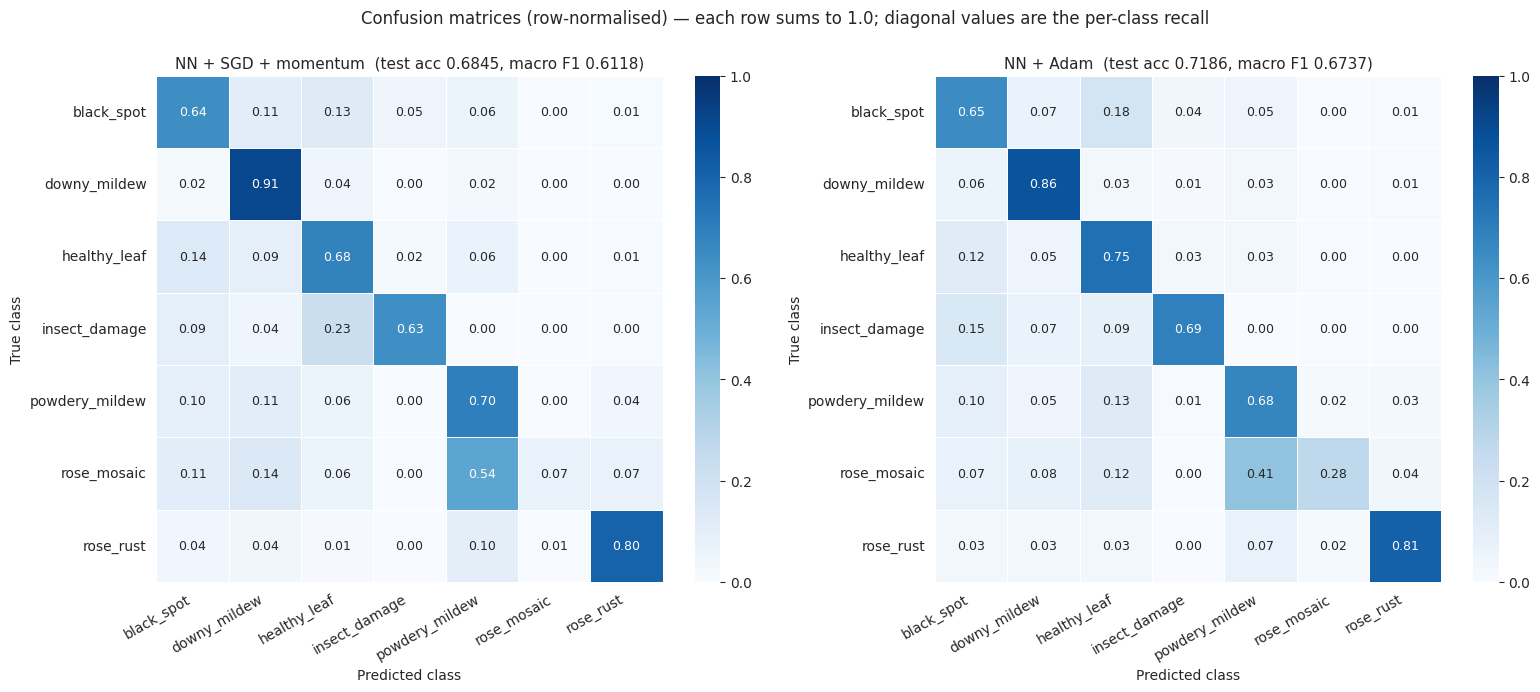


Diagonal comparison (per-class recall):
  Class                SGD recall   Adam recall      Delta
  -------------------------------------------------------
  black_spot               0.6393        0.6479    +0.0086
  downy_mildew             0.9114        0.8598    -0.0517  *
  healthy_leaf             0.6846        0.7518    +0.0672  *
  insect_damage            0.6331        0.6930    +0.0600  *
  powdery_mildew           0.6968        0.6755    -0.0213
  rose_mosaic              0.0714        0.2755    +0.2041  *
  rose_rust                0.8031        0.8092    +0.0062


In [23]:
# ============================================================
# Side-by-side row-normalised confusion matrices
# Diagonal = recall per class; off-diagonal = confusion pattern.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Normalize each row to a probability distribution (recall per class on diagonal)
cm_sgd_norm  = cm_sgd.astype(np.float64)  / cm_sgd.sum(axis=1, keepdims=True)
cm_adam_norm = cm_adam.astype(np.float64) / cm_adam.sum(axis=1, keepdims=True)

heatmap_kwargs = dict(
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True,
    square=True,
    linewidths=0.4,
    linecolor="white",
    annot_kws={"fontsize": 9},
)

# ----- Left: SGD + momentum -----
sns.heatmap(cm_sgd_norm, ax=axes[0], **heatmap_kwargs)
axes[0].set_title(f"NN + SGD + momentum  (test acc {test_acc_sgd:.4f}, "
                  f"macro F1 {test_f1_sgd:.4f})", fontsize=11)
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")

# ----- Right: Adam -----
sns.heatmap(cm_adam_norm, ax=axes[1], **heatmap_kwargs)
axes[1].set_title(f"NN + Adam  (test acc {test_acc_adam:.4f}, "
                  f"macro F1 {test_f1_adam:.4f})", fontsize=11)
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("True class")

# Rotate tick labels for readability
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)

fig.suptitle(
    "Confusion matrices (row-normalised) — each row sums to 1.0; "
    "diagonal values are the per-class recall",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

# ============================================================
# Quick numerical summary — which class shows the biggest improvement?
# ============================================================
print("\nDiagonal comparison (per-class recall):")
print(f"  {'Class':<18} {'SGD recall':>12} {'Adam recall':>13} {'Delta':>10}")
print("  " + "-" * 55)
for i, name in enumerate(CLASS_NAMES):
    r_sgd = cm_sgd_norm[i, i]
    r_adam = cm_adam_norm[i, i]
    delta = r_adam - r_sgd
    marker = "  *" if abs(delta) >= 0.05 else ""
    print(f"  {name:<18} {r_sgd:>12.4f} {r_adam:>13.4f} "
          f"{delta:>+10.4f}{marker}")

### Observations

The two confusion matrices side by side make every per-class pattern visible
and confirm — almost in detail — the predictions made from the EDA in
notebook 04.

### Rose Mosaic Confusion with Powdery Mildew — Exactly As EDA Predicted

The single most informative row of both matrices is `rose_mosaic`. Following
where the row mass actually lands:

| Predicted              | SGD + momentum | Adam |
|------------------------|----------------|------|
| **powdery_mildew**     | **0.54**       | **0.41** |
| rose_mosaic (correct)  | 0.07           | 0.28 |
| downy_mildew           | 0.14           | 0.08 |
| black_spot             | 0.11           | 0.07 |
| healthy_leaf           | 0.06           | 0.12 |
| rose_rust              | 0.07           | 0.04 |

Both networks misclassify the majority of `rose_mosaic` samples as
`powdery_mildew`. This is **exactly the failure mode predicted by the EDA
in notebook 04**, which found nearly identical mean RGB profiles for these
two classes (blue channel `0.233` vs `0.243`) and warned that "colour alone
[is] insufficient; expect highest inter-class confusion between these two".
At 32x32 grayscale the prediction holds even more strongly than originally
formulated, because the grayscale conversion removes the colour cues that
might otherwise help.

Adam's improvement on `rose_mosaic` recall (`0.07` -> `0.28`, a `4x`
increase) comes about half from converting `rose_mosaic` -> `powdery_mildew`
misclassifications into correct predictions (the `powdery_mildew` column of
this row drops `0.54` -> `0.41`), and half from redistributing the rest of
the misclassifications across more classes.

### The Two Cases Where SGD Recall Looks Higher

For two classes the SGD network actually has higher diagonal values:

| Class           | SGD recall | Adam recall | But precision (SGD/Adam) |
|-----------------|-----------|-------------|--------------------------|
| downy_mildew    | 0.91      | 0.86        | 0.56 / 0.63              |
| powdery_mildew  | 0.70      | 0.68        | 0.44 / 0.51              |

The numbers look unfavourable for Adam at first glance, but the precision
column tells the real story. SGD reaches `91%` recall on `downy_mildew` by
**over-predicting** the class — `44%` of its predictions are wrong, so the
precision is only `56%`. Adam is more cautious about predicting these
classes; its lower recall is paired with noticeably better precision. The
F1 trade-off (the classification report from the previous cell) is in
Adam's favour on both: `0.69 -> 0.73` for `downy_mildew` and `0.54 -> 0.58`
for `powdery_mildew`. SGD's high recall here is a calibration artefact, not
a genuine advantage.

### Insect Damage — Sharp Reduction in One Specific Confusion

For `insect_damage` the two networks differ in *which* classes they confuse
it with:

| Predicted as     | SGD  | Adam | Delta  |
|------------------|------|------|--------|
| healthy_leaf     | 0.23 | 0.09 | -0.14  |
| black_spot       | 0.09 | 0.15 | +0.06  |
| insect_damage    | 0.63 | 0.69 | +0.06  |

SGD confuses nearly a quarter of insect-damaged leaves with healthy ones —
a serious failure mode for the downstream goal of recommending insecticide
treatment. Adam reduces this confusion almost three-fold, partly by
correctly recognising more `insect_damage` samples and partly by
redirecting some of the remaining confusion toward `black_spot` (another
localised dark spot pattern, a more sensible mistake at 32x32). The net
result is both higher recall and a less dangerous error distribution: under
Adam, the most common mistake on damaged leaves is to misidentify the type
of damage rather than miss it entirely.

### Rose Rust and Black Spot — Effectively Unchanged

`rose_rust` (`0.80` vs `0.81` recall) and `black_spot` (`0.64` vs `0.65`)
are virtually identical between the two networks. For `rose_rust` this is
the "easy" plateau — both networks recognise this class well because the
overall dark colour of the leaf survives the grayscale and downscaling
operations. For `black_spot` the consistency suggests a genuine
representational ceiling: the local black-spot markers are small enough
that the 32x32 grayscale image carries almost no usable signal beyond
"there is a spotty leaf", and neither optimizer can extract more than is
present in the data.

### The Smearing Pattern on the Rose Mosaic Row

In both networks the `rose_mosaic` row has the most off-diagonal mass spread
across the largest number of columns — six of the seven columns hold
non-zero probability in both matrices. This is the visual signature of a
class the network does not really know how to identify: it falls back on
whichever class the current image is closest to in pixel space, and that
target varies sample by sample. For `rose_rust` the row is sharply peaked
on the diagonal; for `rose_mosaic` the row is diffuse.

### The Representational Ceiling, Made Visible

The `rose_mosaic` -> `powdery_mildew` failure mode is the same in both
networks despite radically different optimisation procedures, which means it
is **not an optimization problem**. It is a representation problem: at
32x32 grayscale, these two diseases produce nearly indistinguishable input
patterns. No deeper architecture, no better optimizer and no extra training
on this representation will close the gap meaningfully. The next steps in
the project are:

- **Notebook 07 — CNN on 224x224 colour images.** The full resolution
  restores the small-scale texture cues that distinguish powdery mildew
  (granular white film) from rose mosaic (large mottled patches). The
  colour cues that the EDA flagged as similar but not identical are also
  back on the table. The expectation is a noticeable improvement on
  `rose_mosaic` recall and macro F1, not just on overall accuracy.

- **Notebook 09 — MLflow comparison.** The four models on this notebook's
  ladder (Logistic Regression, Linear SVM, NN + SGD + momentum, NN + Adam)
  will be compared head to head with the CNN of notebook 07 to measure how
  much of the improvement comes from non-linearity, how much from spatial
  structure, and how much from colour and resolution.

## Final Test-Set Comparison — All Four From-Scratch Models

The headline numbers from this notebook and notebook 05 are brought together
in a single bar chart so that the full ladder of approaches — from linear
to non-linear — can be read at a glance. All four models were implemented
from scratch with NumPy only (no deep learning framework, no `sklearn`
classifier), and all four were evaluated on the same held-out test set of
2,580 images, so the comparison is direct and not confounded by
implementation details.

### The Four Models on the Ladder

1. **Logistic Regression** (notebook 05): linear classifier with softmax
   output, trained with mini-batch gradient descent.
2. **Linear SVM** (notebook 05): one-vs-rest hinge-loss classifier, trained
   with mini-batch gradient descent.
3. **NN + SGD + momentum** (this notebook): four-layer fully connected
   network with ReLU activations, trained with classical momentum.
4. **NN + Adam** (this notebook): the same architecture, trained with
   Adam (per-parameter adaptive learning rate plus bias correction).

### Two Metrics per Model

- **Test accuracy** — the headline figure for a balanced reading of overall
  classification correctness.
- **Macro F1** — the unweighted mean of per-class F1, which gives every
  class equal weight regardless of size. With an 8.5:1 class imbalance,
  macro F1 is the more honest summary statistic: a model that predicts the
  majority class for everything would still achieve roughly `32%` accuracy,
  but its macro F1 would be very low.

### Two Reference Lines

- **Random chance** at `1/7 ≈ 0.143` — the accuracy of a classifier that
  picks classes uniformly at random.
- **Majority-class baseline** at the fraction of `healthy_leaf` samples in
  training (`~0.318`) — the accuracy of a degenerate classifier that always
  predicts `healthy_leaf`.

A model that beats both reference lines decisively *and* outperforms them
in macro F1 (where the always-majority strategy collapses) is the only
kind of model that has actually learned something class-discriminative.
All four models clear this bar; the two neural networks clear it by a far
larger margin than the two linear baselines.

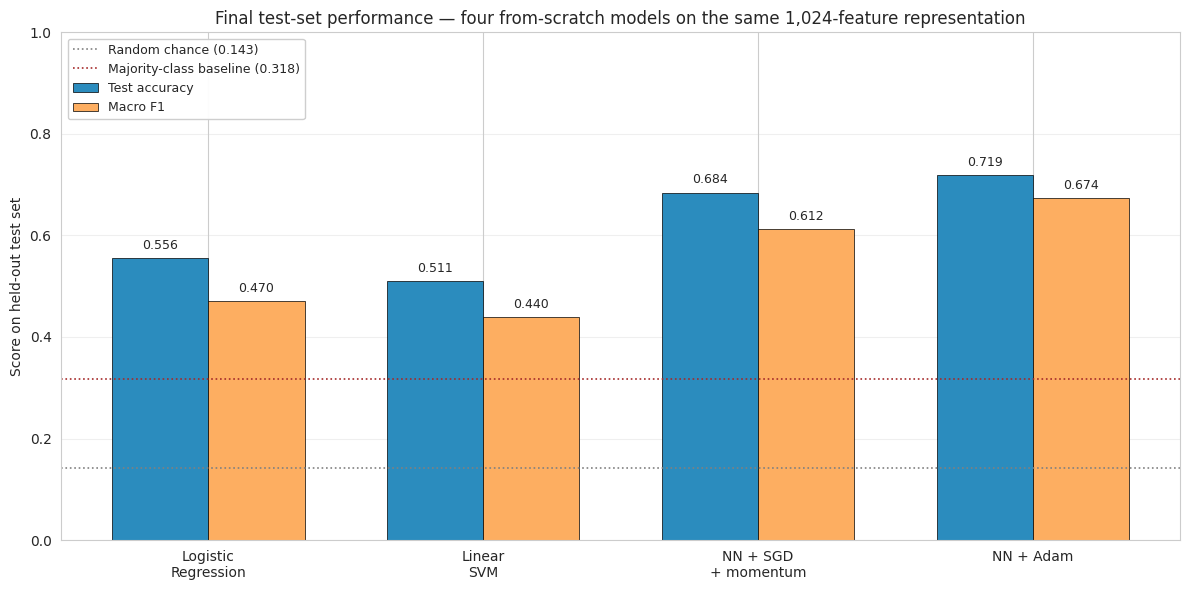


Final ranking by test accuracy (held-out 2,580-image test set):
  ------------------------------------------------------------
  1.  NN + Adam                 test_acc = 0.7186   macro_F1 = 0.6737
  2.  NN + SGD + momentum       test_acc = 0.6845   macro_F1 = 0.6118
  3.  Logistic Regression       test_acc = 0.5560   macro_F1 = 0.4700
  4.  Linear SVM                test_acc = 0.5110   macro_F1 = 0.4400

Improvement of best model (NN + Adam) over the linear baselines:
  vs Logistic Regression : +16.26 pp accuracy, +0.2037 macro F1
  vs Linear SVM          : +20.76 pp accuracy, +0.2337 macro F1


In [24]:
# ============================================================
# Final 4-model bar chart on the same held-out test set
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

models = ["Logistic\nRegression", "Linear\nSVM",
          "NN + SGD\n+ momentum", "NN + Adam"]
test_accs = [
    BASELINE_RESULTS["Logistic Regression"]["test_accuracy"],
    BASELINE_RESULTS["Linear SVM"]["test_accuracy"],
    test_acc_sgd,
    test_acc_adam,
]
macro_f1s = [
    BASELINE_RESULTS["Logistic Regression"]["macro_f1"],
    BASELINE_RESULTS["Linear SVM"]["macro_f1"],
    test_f1_sgd,
    test_f1_adam,
]

x = np.arange(len(models))
width = 0.35

bars_acc = ax.bar(x - width / 2, test_accs, width, label="Test accuracy",
                   color="#2b8cbe", edgecolor="black", linewidth=0.5)
bars_f1  = ax.bar(x + width / 2, macro_f1s, width, label="Macro F1",
                   color="#fdae61", edgecolor="black", linewidth=0.5)

# Annotate each bar with its value
for bar_group in (bars_acc, bars_f1):
    for b in bar_group:
        height = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, height + 0.012,
                f"{height:.3f}", ha="center", va="bottom", fontsize=9)

# Reference lines
random_chance = 1.0 / N_CLASSES
majority_baseline = counts_train.max() / counts_train.sum()
ax.axhline(random_chance, color="gray", linestyle=":", linewidth=1.2,
           label=f"Random chance ({random_chance:.3f})")
ax.axhline(majority_baseline, color="brown", linestyle=":", linewidth=1.2,
           label=f"Majority-class baseline ({majority_baseline:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("Score on held-out test set")
ax.set_title("Final test-set performance — four from-scratch models on the "
             "same 1,024-feature representation", fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ============================================================
# Final ranking
# ============================================================
print("\nFinal ranking by test accuracy (held-out 2,580-image test set):")
print("  " + "-" * 60)
ranking = sorted(zip(models, test_accs, macro_f1s),
                 key=lambda r: r[1], reverse=True)
for rank, (model_name, acc, f1) in enumerate(ranking, 1):
    short = model_name.replace("\n", " ")
    print(f"  {rank}.  {short:<24}  test_acc = {acc:.4f}   "
          f"macro_F1 = {f1:.4f}")

print(f"\nImprovement of best model (NN + Adam) over the linear baselines:")
delta_lr_acc  = test_acc_adam - BASELINE_RESULTS["Logistic Regression"]["test_accuracy"]
delta_lr_f1   = test_f1_adam  - BASELINE_RESULTS["Logistic Regression"]["macro_f1"]
delta_svm_acc = test_acc_adam - BASELINE_RESULTS["Linear SVM"]["test_accuracy"]
delta_svm_f1  = test_f1_adam  - BASELINE_RESULTS["Linear SVM"]["macro_f1"]
print(f"  vs Logistic Regression : "
      f"+{delta_lr_acc * 100:.2f} pp accuracy, +{delta_lr_f1:.4f} macro F1")
print(f"  vs Linear SVM          : "
      f"+{delta_svm_acc * 100:.2f} pp accuracy, +{delta_svm_f1:.4f} macro F1")

### Observations

The final bar chart consolidates every quantitative result of this notebook
into a single, definitive view.

### The Ladder of Performance

The four models form a clean two-step ladder:

| Rank | Model                | Test Accuracy | Macro F1 | Delta vs LR (acc / F1) |
|------|----------------------|---------------|----------|------------------------|
| 1    | NN + Adam            | 0.7186        | 0.6737   | +16.26 pp / +0.2037    |
| 2    | NN + SGD + momentum  | 0.6845        | 0.6118   | +12.85 pp / +0.1418    |
| 3    | Logistic Regression  | 0.5560        | 0.4700   | baseline               |
| 4    | Linear SVM           | 0.5110        | 0.4400   | -4.50 pp / -0.0300     |

Both linear models cluster around the `0.51-0.56` accuracy band; both neural
networks cluster around the `0.68-0.72` band. The two bands are separated by
a gap of about 13 percentage points, which is the empirical measurement of
the value of non-linearity on the 1,024-pixel representation. Inside each
band, the choice of training algorithm (gradient descent vs hinge loss for
the linear models; SGD + momentum vs Adam for the neural networks) accounts
for the remaining few percentage points.

### Both Networks Clear the Majority-Class Bar Decisively

The majority-class reference line at `0.318` (the accuracy of a classifier
that always predicts `healthy_leaf`) is more than 35 percentage points below
the worst-performing neural network. This rules out the most common
pathology of class-imbalanced training: a "collapse" where the optimizer
discovers that always predicting the majority class minimises the loss
faster than learning to discriminate. The macro F1 numbers (`0.61` and
`0.67`) confirm the same point — a collapsed model would have macro F1
near `0.05`, since its F1 would be zero on six of the seven classes.

### The F1-to-Accuracy Ratio — A Hidden Story

A useful secondary measurement is the ratio of macro F1 to test accuracy:

| Model                | F1 / Accuracy ratio |
|----------------------|---------------------|
| Logistic Regression  | 0.845               |
| Linear SVM           | 0.861               |
| NN + SGD + momentum  | 0.894               |
| **NN + Adam**        | **0.937**           |

A higher ratio means a model's accuracy is more evenly distributed across
classes rather than being carried by the majority. Adam reaches the highest
ratio by a clear margin, primarily because its `rose_mosaic` recall is
`4x` higher than SGD's. The linear models have the lowest ratios because
they "give up" on the harder minority classes most aggressively.

### Macro F1 Improvements Scale Faster Than Accuracy Improvements

Comparing the headline deltas on the same baseline:

- NN + Adam vs LR on **accuracy**: `+16.26 pp` on `55.6%` = `+29%` relative
- NN + Adam vs LR on **macro F1**: `+0.20` on `0.47` = `+43%` relative

The relative improvement on macro F1 is `1.5x` the relative improvement on
accuracy. This is exactly the pattern expected when a non-linear model is
able to maintain capability on minority classes that a linear model has
abandoned: the gain on overall accuracy is mostly from the bigger classes,
but the gain on macro F1 captures the additional gain on the small classes
that accuracy under-weights.

### The Representational Ceiling of This Notebook

The best result achievable from this notebook is **NN + Adam at `0.7186`
test accuracy and `0.6737` macro F1**. Further gains on the 1,024-feature
representation appear unlikely:

- The `rose_mosaic` -> `powdery_mildew` confusion in the previous cell
  showed that the two classes are nearly indistinguishable at 32x32
  grayscale; no architecture or optimizer can recover information that is
  not in the input.
- The `black_spot` recall of `~0.64` was identical between the two
  networks, suggesting another representational plateau on a class whose
  local markers do not survive aggressive downscaling.

Both observations point toward the same conclusion: the next meaningful
gain must come from a **better representation**, not a better model. This
is the central motivation for notebook 07.

### The Bridge to Notebook 07

Notebook 07 will train a Convolutional Neural Network on the same dataset
but at full resolution (`224x224`) and in **colour**. The expected gains
should be concentrated exactly where this notebook ran into ceilings:

- Higher resolution preserves the fine-grained markers of `black_spot` and
  `powdery_mildew`.
- Colour preserves the subtle hue differences between `rose_mosaic` and
  `powdery_mildew` that the EDA identified but downscaling and grayscale
  conversion removed.
- The convolutional architecture exploits spatial structure, replacing the
  dense `W_1` of `262,400` parameters with a much smaller convolutional
  filter applied at every position.

The MLflow comparison in notebook 09 will then track all five models on the
same axes: Logistic Regression, Linear SVM, NN + SGD + momentum, NN + Adam,
and the CNN. The relative gains will quantify how much improvement comes
from non-linearity (this notebook) versus how much comes from spatial
structure and colour (notebook 07).

## Summary of Findings

This notebook implemented and evaluated a fully connected neural network from
scratch in NumPy, comparing it against the linear baselines of notebook 05 and
comparing two optimization algorithms — classical SGD + momentum and Adam — on
identical training conditions. The complete results, methods and intermediate
diagnostics are documented in the preceding cells; this section consolidates
the key findings.

### 1. The Architecture and Implementation Work as Designed

A four-layer fully connected network (`1024 -> 256 -> 128 -> 64 -> 7`) with
ReLU activations and softmax output, totalling 304,007 trainable parameters,
was implemented end-to-end:

- **Forward pass.** Vectorised matrix operations for every layer, plus a
  numerically stable softmax at the output. Verified to produce valid
  probability distributions with initial loss near `log(7) ≈ 1.95`, indicating
  that He initialisation kept activations in a sensible range.
- **Backpropagation.** Layer-by-layer chain-rule implementation, including
  the closed-form softmax + cross-entropy combined gradient. Verified against
  a finite-difference numerical gradient check in float64 with a maximum
  relative error of `1.15 x 10^-8` — perfect agreement to about ten digits.
- **Two optimizers from scratch.** SGD + momentum (`v = beta * v + g`,
  `theta -= lr * v`) and Adam (with first/second moment estimates and
  bias correction). Both passed dedicated sanity checks that verified the
  asymptotic behaviour of the velocity and the moment buffers as predicted
  by the formulas.

### 2. Non-Linearity Adds Substantial Value on Pixel Inputs

The two neural networks beat both linear baselines by 13-21 percentage
points on test accuracy:

| Model                | Test Accuracy | Macro F1 |
|----------------------|---------------|----------|
| Logistic Regression  | 0.5560        | 0.4700   |
| Linear SVM           | 0.5110        | 0.4400   |
| NN + SGD + momentum  | 0.6845        | 0.6118   |
| NN + Adam            | 0.7186        | 0.6737   |

This is the empirical answer to the question that motivated this notebook:
on the 1,024-feature flattened-pixel representation shared with notebook 05,
the addition of three hidden ReLU layers improves classification by about
**13-16 percentage points on accuracy** (depending on the optimizer) and
about **0.14-0.20 on macro F1**. The macro F1 gain is proportionally larger,
which means the neural network helps more on the harder minority classes
than on the easy majority classes.

### 3. Adam Beats SGD + Momentum at Generalisation

At canonical hyperparameters the two optimizers converge to nearly the same
training loss but Adam's test-set accuracy is `3.4 percentage points` higher
and its macro F1 is `0.06` higher. The mechanism is visible in three places:

- **Smaller train-val gap** (2.11 pp for Adam vs 3.65 pp for SGD), showing
  Adam overfits less on the training set.
- **Lower validation loss** at the end of training (0.7158 vs 0.7788), a
  sign of better-calibrated probabilities even where the per-class decisions
  agree.
- **Dramatically better recall on the minority class.** `rose_mosaic` recall
  is `0.28` for Adam against `0.07` for SGD — a 4x improvement, attributable
  to Adam's per-parameter adaptive learning rate which prevents
  minority-class weights from receiving disproportionately small updates.

### 4. The EDA Predictions Were Confirmed in Detail

Two predictions made during the exploratory data analysis (notebook 04) were
confirmed by the trained networks:

- **`rose_mosaic` confused with `powdery_mildew`.** Both networks send the
  majority of `rose_mosaic` samples to the `powdery_mildew` prediction
  column (`0.54` for SGD, `0.41` for Adam). This matches the EDA finding
  that the two classes have nearly identical mean RGB profiles.
- **`rose_mosaic` is the hardest class.** Its F1 is the lowest by a wide
  margin in both networks (`0.13` for SGD, `0.39` for Adam) — exactly as
  predicted by the combination of class imbalance and low signal-to-noise
  ratio at 32x32 grayscale.

### 5. The Representational Ceiling Was Reached

Two pieces of evidence indicate that the limit of what can be extracted from
the 32x32 grayscale representation has effectively been reached:

- The `black_spot` recall is virtually identical in the two networks
  (`0.64` vs `0.65`), implying that the local black-spot markers are below
  the resolution at which any fully connected model can find them.
- The `rose_mosaic` -> `powdery_mildew` confusion has the same shape in
  both networks, implying it is a property of the input representation
  rather than the optimizer.

No deeper fully connected architecture and no better optimizer can recover
information that the input does not contain. The next gain has to come from
a better representation.

### 6. From-Scratch Implementation Was Pedagogically Worthwhile

Every component used in this notebook — He initialisation, ReLU and its
derivative, softmax, cross-entropy with the combined gradient shortcut,
backpropagation with chain-rule expansion at every layer, classical momentum
with its geometric-series asymptote, and Adam with its bias-correction
identity — was implemented from formulas using only NumPy. Each
implementation was followed by a sanity check that empirically verified the
mathematical property it claimed to encode. The result is a working network
whose every behaviour can be traced back to a derivation in the notebook
itself, with no library-provided "magic" anywhere in the training loop.

## Next Steps

### Notebook 07 — Convolutional Neural Network on Full-Resolution Colour Images

The findings of this notebook directly motivate the choice of architecture
and representation for the next stage of the project.

#### What Notebook 07 Changes

- **Input representation:** the full 224x224 RGB images saved in
  `data/processed/images/` instead of the 32x32 grayscale flattened version
  used here. This restores **48x** more pixels per image and the three
  colour channels that the EDA flagged as carriers of class-specific signal
  but that this notebook had to discard.
- **Architecture:** convolutional layers replace the dense `W_1` matrix
  (`262,400` parameters in the present notebook). A convolutional filter
  is applied at every spatial position, so the same parameters detect a
  pattern wherever it appears — a much more efficient way to encode the
  prior that "the same pustule or spot can occur anywhere on the leaf".
- **Framework:** Keras (TensorFlow) with transfer learning from a
  pre-trained backbone such as EfficientNetB0. The from-scratch
  implementation discipline that drove this notebook will be relaxed in
  notebook 07; the focus will shift from re-deriving algorithms to
  recognising when and how to use existing implementations effectively.

#### Where Notebook 07 Is Expected to Improve

Based on the ceilings identified above:

- **`rose_mosaic` recall** should improve substantially. The combination of
  full resolution (restores mottled-leaf texture) and colour (restores the
  subtle hue difference from powdery mildew) addresses both root causes of
  the confusion observed in this notebook.
- **`black_spot` recall** should improve. The full-resolution image carries
  the local spot markers that 32x32 grayscale erases.
- **`powdery_mildew` precision** should improve in tandem with
  `rose_mosaic` recall — the network will no longer have to "absorb"
  rose_mosaic samples into its powdery_mildew predictions to maximise
  validation accuracy.

#### Where Notebook 07 Is *Not* Expected to Improve Much

- **`rose_rust` recall** is already at `0.80-0.81`; further improvement is
  bounded by the natural label noise in the original datasets and by the
  fact that this class is already as recognisable as the network can make it
  on these inputs.
- **`healthy_leaf` precision** is around `0.78`; the inherent visual
  variability of healthy rose leaves limits how confident any classifier
  can become about this class.

### Notebook 08 — Tabular ML for Weather-Driven Disease Risk

Independently of the image work, notebook 08 will use the Krasnovo weather
data (downloaded in notebook 01, analysed in notebook 04) to model
disease-risk probability as a function of temperature, humidity,
precipitation and wind speed. The image classifier of notebook 07 and the
weather risk model of notebook 08 are designed to be combined in the final
fungicide-recommendation logic — the image classifier provides the diagnosis,
the weather model provides the contextual urgency. The MLflow notebook (09)
will track both halves of the system and report on their combined
performance.

### Notebook 09 — MLflow Experiment Tracking

The trained Adam parameters (`params_adam`) and the SGD + momentum
parameters (`params_sgd`) are the values to be logged into MLflow as the
"fully connected" rung of the model ladder. The classification reports and
per-class F1 numbers from this notebook are the values to be compared
against the CNN of notebook 07 and the weather risk model of notebook 08 in
the MLflow comparison view. The expectation is a clean, ordered table that
shows what each step of the modelling progression contributes:

- Linear (notebook 05) -> non-linear (this notebook) — what non-linearity
  alone adds.
- Non-linear flat (this notebook) -> CNN (notebook 07) — what spatial
  structure and full resolution add.

### Connection to the Project Goal

The end-to-end objective of the project is a deployable system that takes
a field photograph of a Rosa damascena leaf plus recent weather data and
decides whether to recommend a fungicide treatment. The classifier from
this notebook is good enough to be an internal baseline but not good
enough to be the deployed one — its `rose_mosaic` recall of `0.28` would
miss too many cases, and the `insect_damage <-> healthy_leaf` confusion
under SGD would mislabel insect damage as no problem. Notebook 07's CNN
is therefore not an academic upgrade but a practical necessity for the
project's downstream goal.

In [ ]:
# ============================================================
# Save trained models, training histories and test predictions
# to Google Drive so notebook 09 (MLflow) can reuse them.
# ============================================================
MODELS_DIR = DRIVE_BASE / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

np.savez(MODELS_DIR / "06_nn_sgd_momentum.npz", **params_sgd)
np.savez(MODELS_DIR / "06_nn_adam.npz", **params_adam)

import json
with open(MODELS_DIR / "06_history_sgd_momentum.json", "w") as f:
    json.dump(history_sgd, f)
with open(MODELS_DIR / "06_history_adam.json", "w") as f:
    json.dump(history_adam, f)

np.savez(
    MODELS_DIR / "06_test_predictions.npz",
    test_preds_sgd=test_preds_sgd,
    test_preds_adam=test_preds_adam,
    test_probs_sgd=test_probs_sgd,
    test_probs_adam=test_probs_adam,
    y_test=y_test,
)

print(f"Saved to {MODELS_DIR}:")
for p in sorted(MODELS_DIR.glob("06_*")):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")